In [1]:
%load_ext eradiate

In [2]:
import eradiate

In [3]:
import attrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [4]:
import eradiate

eradiate.set_mode("mono_polarized")
integrator = "eovolpath"

In [5]:
from eradiate.units import unit_registry as ureg

## I. Coordinates definition

 - The ZGrid class is removed in favor of two 3D coordinate grid classes handling plane parallel and spherical shell geometries
 - The `grid` module defines these class at the top level of the eradiate package (i.e. `eradiate.grid`). The ZGrid class used to be defined within the radprops module
 - Grids provide a mappring from geometric coordinates to the internal grid data storage facilities in Eradiate, always indexed on unsigned 3D array positions X, Y and Z. 
 - `eradiate.grid` centralizes the logic for coordinate mapping, a useful property for future developments.

In [6]:
from eradiate.grid import GridCoords, PlaneParallelGridCoords, SphericalShellGridCoords

In [7]:
z_grid = GridCoords.make_default()
z_grid


PlaneParallelGridCoords(
    levels=<Quantity([0.000e+00 1.000e+02 2.000e+02 ... 1.198e+05 1.199e+05 1.200e+05], 'meter')>,
    layers=<Quantity([5.0000e+01 1.5000e+02 2.5000e+02 ... 1.1975e+05 1.1985e+05 1.1995e+05], 'meter')>,
    layer_height=<Quantity(100.0, 'meter')>,
    total_height=<Quantity(120000.0, 'meter')>,
    edges_x=<Quantity([-500000.  500000.], 'kilometer')>,
    centers_x=<Quantity([0.], 'kilometer')>,
    cell_width=<Quantity(1000000.0, 'kilometer')>,
    total_width=<Quantity(1000000.0, 'kilometer')>,
    edges_y=<Quantity([-500000.  500000.], 'kilometer')>,
    centers_y=<Quantity([0.], 'kilometer')>,
    cell_length=<Quantity(1000000.0, 'kilometer')>,
    total_length=<Quantity(1000000.0, 'kilometer')>,
    shape=(1, 1, 1200)
)

In [8]:
grid_test = z_grid.resampled_to_cell_size(0.5 * ureg.hm, 0.5 * ureg.hm)
grid_test = grid_test.cropped(2 * ureg.hm, 3 * ureg.hm)
grid_test


PlaneParallelGridCoords(
    levels=<Quantity([0.000e+00 1.000e+02 2.000e+02 ... 1.198e+05 1.199e+05 1.200e+05], 'meter')>,
    layers=<Quantity([5.0000e+01 1.5000e+02 2.5000e+02 ... 1.1975e+05 1.1985e+05 1.1995e+05], 'meter')>,
    layer_height=<Quantity(100.0, 'meter')>,
    total_height=<Quantity(120000.0, 'meter')>,
    edges_x=<Quantity([-0.1  -0.05  0.    0.05  0.1 ], 'kilometer')>,
    centers_x=<Quantity([-0.075 -0.025  0.025  0.075], 'kilometer')>,
    cell_width=<Quantity(0.05, 'kilometer')>,
    total_width=<Quantity(0.2, 'kilometer')>,
    edges_y=<Quantity([-0.15 -0.1  -0.05  0.    0.05  0.1   0.15], 'kilometer')>,
    centers_y=<Quantity([-0.125 -0.075 -0.025  0.025  0.075  0.125], 'kilometer')>,
    cell_length=<Quantity(0.05, 'kilometer')>,
    total_length=<Quantity(0.3, 'kilometer')>,
    shape=(4, 6, 1200)
)

In [9]:
grid_3d = PlaneParallelGridCoords(
    levels=np.linspace(0, 100, 101) * ureg.m,
    edges_x=grid_test.edges_x,
    edges_y=grid_test.edges_y,
)

In [10]:
grid_3d


PlaneParallelGridCoords(
    levels=<Quantity([  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100.], 'meter')>,
    layers=<Quantity([ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5 30.5 31.5 32.5 33.5 34.5 35.5 36.5 37.5 38.5 39.5 40.5 41.5
 42.5 43.5 44.5 45.5 46.5 47.5 48.5 49.5 50.5 51.5 52.5 53.5 54.5 55.5
 56.5 57.5 58.5 59.5 60.5 61.5 62.5 63.5 64.5 65.5 66.5 67.5 68.5 69.5
 70.5 71.5 72.5 73.5 74.5 75.5 76.5 77.5 78.5 79.5 

The PlaneParallelGridCoords defines a mapping from cartesian coordinates space of the scene to 3D memory array cells according to its discretization.

In [11]:
SphericalShellGridCoords(
    levels=np.linspace(0, 100, 101) * ureg.meter,
    azimuths=np.linspace(175, 185, 11) * ureg.degree,
    colatitudes=np.linspace(85, 95, 11) * ureg.degree,
)


SphericalShellGridCoords(
    levels=<Quantity([  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100.], 'meter')>,
    layers=<Quantity([ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5 30.5 31.5 32.5 33.5 34.5 35.5 36.5 37.5 38.5 39.5 40.5 41.5
 42.5 43.5 44.5 45.5 46.5 47.5 48.5 49.5 50.5 51.5 52.5 53.5 54.5 55.5
 56.5 57.5 58.5 59.5 60.5 61.5 62.5 63.5 64.5 65.5 66.5 67.5 68.5 69.5
 70.5 71.5 72.5 73.5 74.5 75.5 76.5 77.5 78.5 79.5

In [12]:
grid_1d = grid_3d.single_column()

## II. Geometry

The geometry interfaces accepts 3D grids. The geometry defines the medium shape, its extent, and the bounding box in which its component are evaluated.

In [13]:
from eradiate.scenes.geometry import PlaneParallelGeometry

geometry_3d = PlaneParallelGeometry(grid=grid_3d, toa_altitude=grid_3d.levels[-1])
geometry_3d


PlaneParallelGeometry(
    toa_altitude=100.0 m,
    ground_altitude=0.0 km,
    grid=PlaneParallelGridCoords(
        levels=<Quantity([  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100.], 'meter')>,
        layers=<Quantity([ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5 30.5 31.5 32.5 33.5 34.5 35.5 36.5 37.5 38.5 39.5 40.5 41.5
 42.5 43.5 44.5 45.5 46.5 47.5 48.5 49.5 50.5 51.5 52.5 53.5 54.5 55.5
 56.5 57.5 58.5 59.5 60.5 61

In [14]:
geometry_3d.width

<Quantity(1000000.0, 'kilometer')>

In [15]:
import drjit as dr
buf = dr.scalar.ArrayXf64(10, 20, 30, 40, 50, 60, 70, 80, 90, 100)
index = dr.scalar.ArrayXu(1, 0, 1, 2, 3, 4)
dr.gather(dr.scalar.ArrayXf64, buf, index)

[20, 10, 20, 30, 40, 50]

In [16]:
dr.gather?

Call signature: dr.gather(*args, **kwargs)
Type:           nb_func
String form:    <nanobind.nb_func object at 0x7f8ab42cd030>
Docstring:     
gather(dtype: type[T], source: object, index: AnyArray | Sequence[int] | int, active: AnyArray | Sequence[bool] | bool = True, mode: drjit.ReduceMode = drjit.ReduceMode.Auto, shape: tuple[int, ...] | None = None) -> T

Gather values from a flat array or nested data structure.

This function performs a *gather* (i.e., indirect memory read) from ``source``
at position ``index``. It expects a ``dtype`` argument and will return an
instance of this type. The optional ``active`` argument can be used to disable
some of the components, which is useful when not all indices are valid; the
corresponding output will be zero in this case.

This operation can be used in the following different ways:

1. When ``dtype`` is a 1D Dr.Jit array like :py:class:`drjit.llvm.ad.Float`,
   this operation implements a parallelized version of the Python array
   indexing 

The geometry is thus much larger than the grid, defining the coordinates on which the datasets are defined.

1D grids are still supported:

In [17]:
grid_1d = PlaneParallelGridCoords(
    levels=np.linspace(0, 100, 101) * ureg.m,
    edges_x=[-5e5, 5e5] * ureg.km,
    edges_y=[-5e5, 5e5] * ureg.km,
)
geometry_1d = PlaneParallelGeometry(grid=grid_1d, toa_altitude=grid_1d.levels[-1])

## II. Emulating 1D atmospheres

In [18]:
from eradiate.scenes.atmosphere import MolecularAtmosphere, ParticleLayer

atmosphere_1d = MolecularAtmosphere(geometry=geometry_1d)
atmosphere_3d = MolecularAtmosphere(geometry=geometry_3d)

In [19]:
from eradiate.experiments import AtmosphereExperiment

exp_1d = AtmosphereExperiment(atmosphere=atmosphere_1d)
exp_3d = AtmosphereExperiment(atmosphere=atmosphere_3d)

res_1d = eradiate.run(exp_1d, spp=100000)
res_3d = eradiate.run(exp_3d, spp=100000)

assert np.allclose(res_1d.radiance.item(), res_3d.radiance.item(), rtol=1e-2)

## III. 3D Particle Layers

Spatial variations are defined mostly using a column major process. Five spatial variation implementations are provided:
 - Optical thickness $\tau_{ref}$ variation for each column
 - Spatially varying Z extents along the X or Y axes
 - Horizontal distributions evaluated along the X or Y axes
 - Spatially varying Z-columns distribution parameters along the X or Y axes
 - Distribution compositions

### 1. $\tau_{ref}$ variations w.r.t horizontal coordinates

Particle layers can now vary along the horizontal extents. 

In [20]:
ParticleLayer(geometry=geometry_3d).top

<Quantity(1.0, 'kilometer')>

For this example with 3D particles, we define a checkerboard of varying AOT:

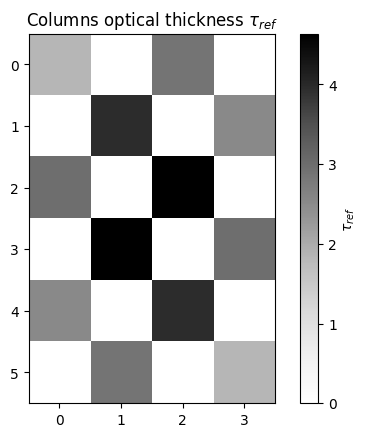

In [21]:
tau_max = 5

x, y = np.meshgrid(np.linspace(-1, 1, 4), np.linspace(-1, 1, 6))
d = np.sqrt(x * x + y * y)
sigma, mu = 1.0, 0.0
g = np.exp(-((d - mu) ** 2 / (2.0 * sigma**2)))
tau_ref = np.ones((4, 6))
tau_ref *= g.T
tau_ref = tau_ref * tau_max

i = np.repeat(np.arange(tau_ref.shape[0]).reshape(1, -1), tau_ref.shape[1], axis=0)
j = np.repeat(np.arange(tau_ref.shape[1]).reshape(-1, 1), tau_ref.shape[0], axis=1)
mask = i % 2 == j % 2
tau_ref = np.where(mask.T, tau_ref, 0)

cbar = plt.colorbar(plt.imshow(tau_ref.T, cmap="Greys"), label="$\\tau_{ref}$")
plt.title("Columns optical thickness $\\tau_{ref}$")
plt.show()
plt.close()

In [22]:
roi_size = 7.0 * ureg.km

In [23]:
from eradiate.scenes.measure import PerspectiveCameraMeasure

origin = [0, 0.01, 250] * ureg.km
resolution = 256
spp = 128

camera = PerspectiveCameraMeasure(
    id="camera",
    origin=origin,
    target=[1, 0, 0],
    up=[0, 0, 1],
    film_resolution=(resolution, resolution),
    spp=spp,
    far_clip=1e7 * ureg.km,
    fov=0.2,
)


def plot_camera(res, vmax=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(1, 1)
    res.squeeze(drop=True).plot.imshow(
        ax=ax,
        origin="upper",
        cmap="Greys_r",
        robust=True,
        add_colorbar=True,
        vmin=0,
        vmax=vmax,
    )
    ax.set_aspect(1)

A checkerboard surface is used to test the alignment

In [24]:
extra_objs = {
    "mysurface": {
        "factory": "shape",
        "type": "rectangle",
        "center": [0, 0, 0],
        "edges": [grid_3d.total_length.m_as("m") * 1000, grid_3d.total_length.m_as("m") * 1000],
        "bsdf": {
            "type": "lambertian",
            "reflectance": 0.8
            #"scale_pattern": grid_3d.total_length / grid_3d.cell_length,
        },
    }
}

In [25]:
particles_1d = ParticleLayer(
    tau_ref=tau_max, bottom=0, top=20 * ureg.m, geometry=geometry_1d
)

In [26]:
from eradiate.experiments import CanopyAtmosphereExperiment

exp_1d = CanopyAtmosphereExperiment(
    atmosphere=particles_1d,
    surface=None,
    measures=camera,
    illumination={"type": "directional", "zenith": 30, "azimuth": 30},
    integrator={"type": integrator, "moment": True},
    extra_objects=extra_objs,
    geometry=geometry_1d,
)

In [27]:
%%time

res_onedim = eradiate.run(exp_1d, spp=10)

CPU times: user 1min 11s, sys: 10.7 ms, total: 1min 11s
Wall time: 3.46 s


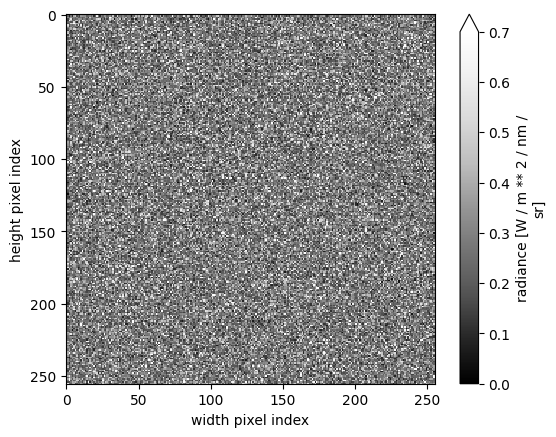

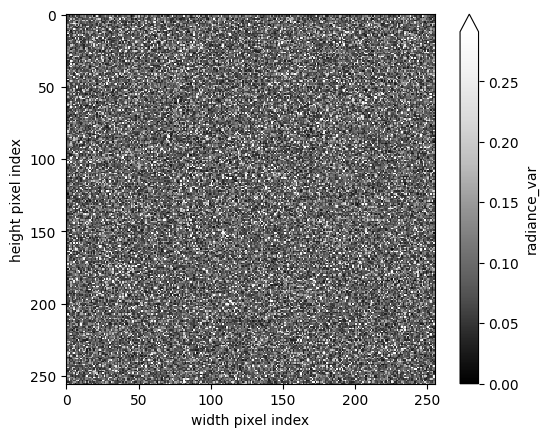

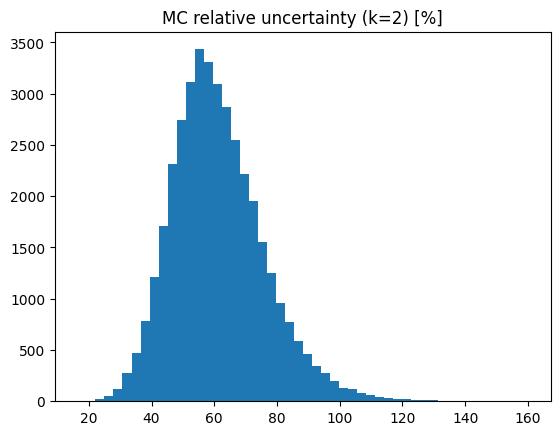

In [28]:
plot_camera(res_onedim.radiance, vmax=0.7)
plt.show()
plt.close()
plot_camera(np.sqrt(res_onedim.radiance_var))
plt.show()
plt.close()
std = np.sqrt(res_onedim.radiance_var.values.ravel())
std2 = 2 * np.where(std < 0.1, std, np.nan)
plt.hist(std2 / res_onedim.radiance.values.ravel() * 100, bins=50)
plt.title("MC relative uncertainty (k=2) [%]")
plt.show()
plt.close()

Now with the 2D variation

In [29]:
particles_tau2d = ParticleLayer(
    geometry=geometry_3d, tau_ref=tau_ref, bottom=0, top=20 * ureg.m
)

In [30]:
particles_tau2d.eval_fractions(particles_tau2d.geometry.grid).sum(axis=-1)

array([[1.]])

In [31]:
exp2 = AtmosphereExperiment(
    atmosphere=particles_tau2d,
    surface=None,
    measures=PerspectiveCameraMeasure(
        id="camera",
        origin=origin,
        target=[0, 0, 0],
        up=[0, 0, 1],
        film_resolution=(resolution, resolution),
        spp=spp,
        far_clip=1e7 * ureg.km,
        fov=0.05,
    ),
    integrator={"type": integrator, "moment": True},
    geometry=geometry_3d,
    illumination={"type": "directional", "zenith": 30, "azimuth": 30},
    extra_objects=extra_objs,
)

In [32]:
%%time

res2 = eradiate.run(exp2, spp=10)

CPU times: user 31.3 s, sys: 4.08 ms, total: 31.3 s
Wall time: 1.58 s


First 3D atmospheric simulations with Eradiate!

Text(0, 0.5, 'length pixel index')

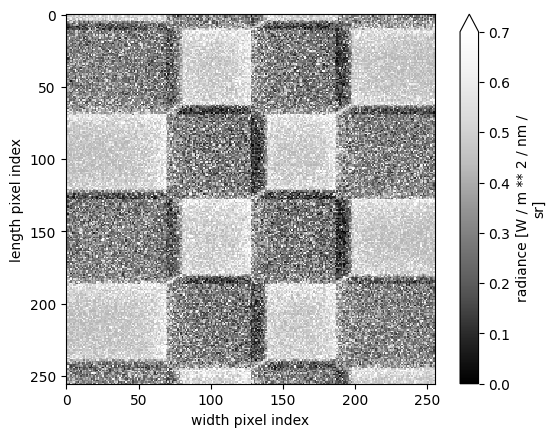

In [33]:
plot_camera(res2.radiance, vmax=0.7)
plt.ylabel("length pixel index")

The selected wrap_mode (clamp) extends the last values of the particles extinction coefficients within the range of the GridCoords until the edge of the atmospheric medium.

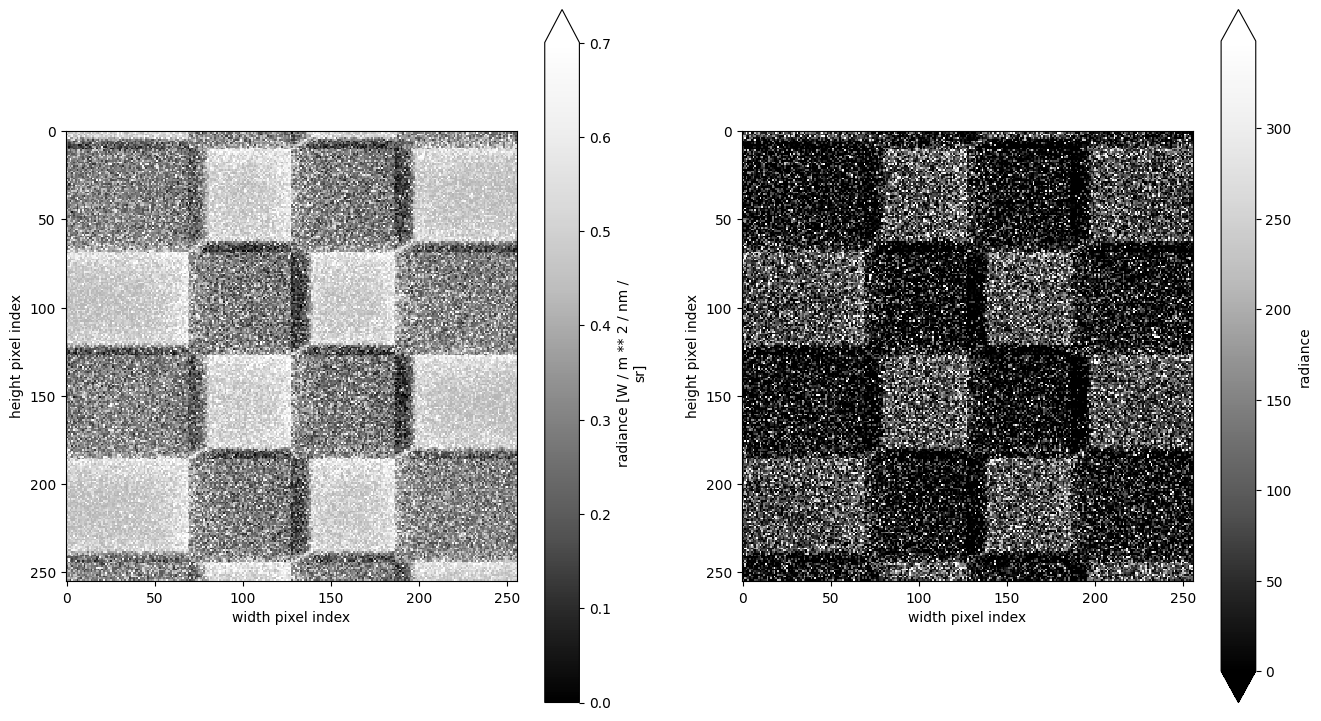

In [34]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))

plot_camera(res2.radiance, vmax=0.7, ax=ax1)
plot_camera((res2.radiance - res_onedim.radiance) / res_onedim.radiance * 100, ax=ax2)

/home/miskn/git/erd_multi/.pixi/envs/dev/lib/python3.10/site-packages/xarray/core/computation.py:818: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


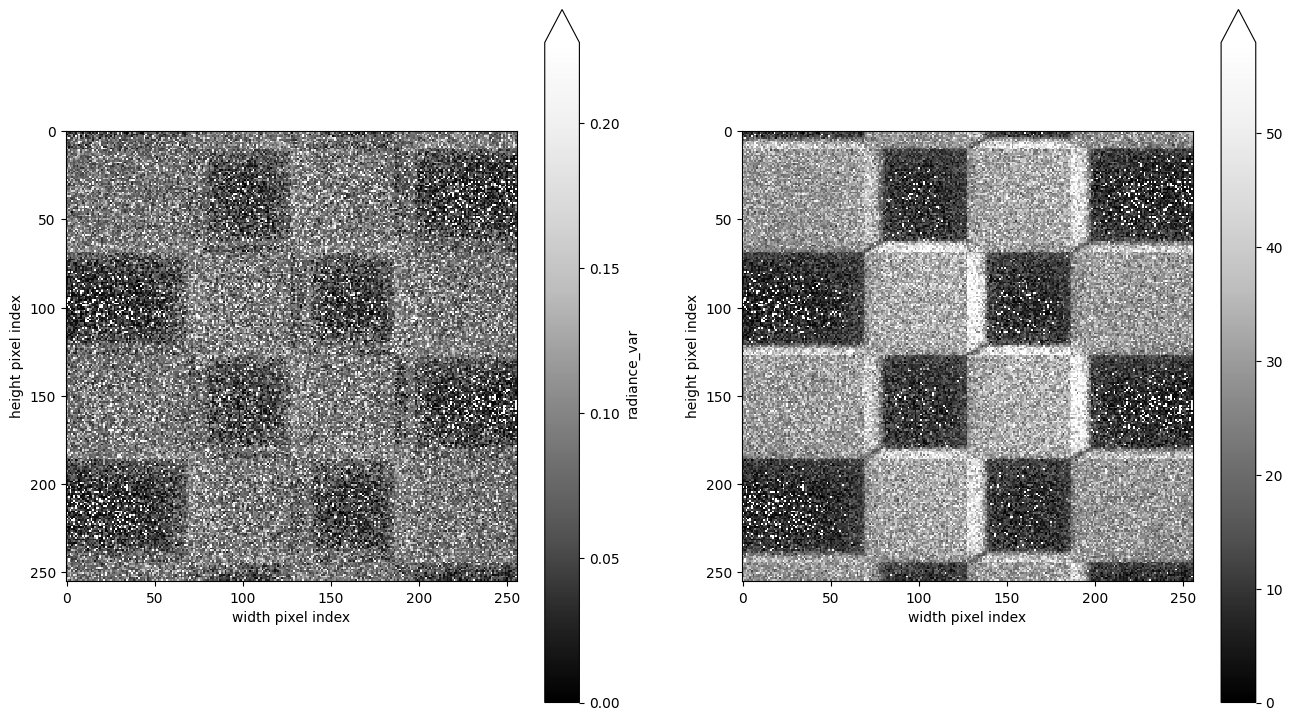

In [35]:
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))

plot_camera(np.sqrt(res2.radiance_var), ax=ax1)
plot_camera(np.sqrt(res2.radiance_var) / res2.radiance * 100, ax=ax2)

### 2. Horizontal distributions


In [36]:
from eradiate.scenes.atmosphere import GaussianParticleDistribution

particles_gauss = ParticleLayer(
    tau_ref=tau_ref, bottom=0, top=20 * ureg.m,
    geometry=geometry_3d,
)

In [37]:
particles_gauss.eval_fractions(particles_gauss.geometry.grid).T.max()

np.float64(0.05)

In [38]:
particles_gauss.eval_fractions(particles_gauss.geometry.grid).min()

np.float64(0.0)

In [39]:
particles_gauss.eval_fractions(particles_gauss.geometry.grid).max()

np.float64(0.05)

In [40]:
particles_gauss.eval_fractions(particles_gauss.geometry.grid).sum(axis=-1).T

array([[1.]])

In [41]:
from eradiate.scenes.geometry import WrapMode

exp3 = AtmosphereExperiment(
    atmosphere=particles_tau2d,
    surface=None,
    measures=camera,
    integrator={"type": "volpath", "moment": True},
    geometry=attrs.evolve(geometry_3d, wrap_mode=WrapMode.CLAMP),
    illumination={"type": "directional", "zenith": 30, "azimuth": 30},
    extra_objects=extra_objs,
)

In [42]:
%%time

res_repeat = eradiate.run(exp3, spp=10)

CPU times: user 37.7 s, sys: 72 μs, total: 37.7 s
Wall time: 2.05 s


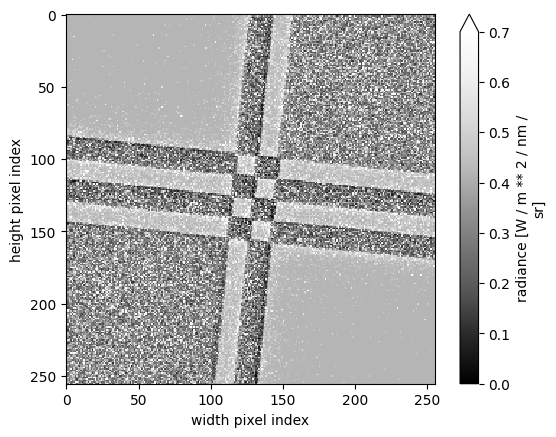

In [43]:
plot_camera(res_repeat.radiance, vmax=0.7)

In [44]:
from eradiate.scenes.geometry import WrapMode

exp4 = AtmosphereExperiment(
    atmosphere=particles_tau2d,
    surface=None,
    measures=camera,
    integrator={"type": "volpath", "moment": True},
    geometry=attrs.evolve(geometry_3d, wrap_mode=WrapMode.MIRROR),
    illumination={"type": "directional", "zenith": 30, "azimuth": 30},
    extra_objects=extra_objs,
)

In [45]:
res_mirror = eradiate.run(exp4, spp=10)

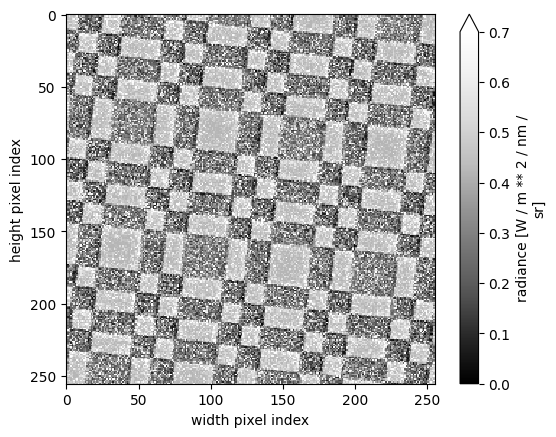

In [46]:
plot_camera(res_mirror.radiance, vmax=0.7)

## IV. IPRT case C2: with particles

### 1. Setup

Conversion function provided by Emdec

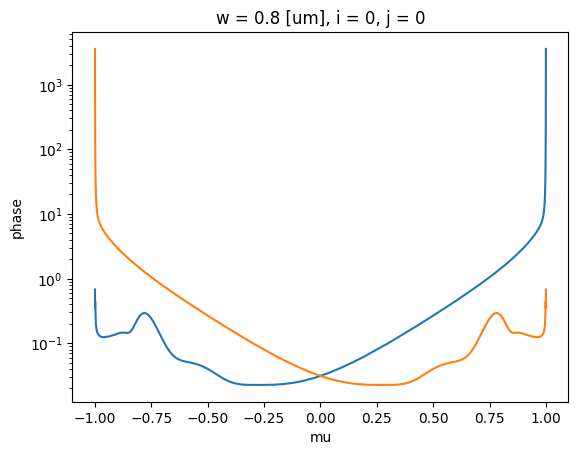

In [47]:
from test_3d_clouds.utils import load_aerosol_data
ds = load_aerosol_data("test_3d_clouds/watercloud.mie.cdf", "spherical", 800 * ureg.nm)
ds.phase.isel(w=1, i=0, j=0).plot(yscale="log")
ds_revert = ds.assign_coords(mu=-ds.mu)
ds_revert.phase.isel(w=1, i=0, j=0).plot(yscale="log")

We need to recreate the IPRT-C2 case parameters, this is a bit tedious

In [48]:
from eradiate.scenes.geometry import WrapMode
from eradiate.scenes.measure import TargetRectangle

c2_grid = PlaneParallelGridCoords.from_extent_and_resolution(
    levels=np.linspace(0, 5, 6) * ureg.km,
    extent_x=7 * ureg.km,
    extent_y=7 * ureg.km,
    n_cells_x=7,
    n_cells_y=7,
)
c2_geom = PlaneParallelGeometry(
    grid=c2_grid,
    toa_altitude=c2_grid.levels[-1],
    wrap_mode=WrapMode.REPEAT,
)
c2_spp = 1000
c2_w_ref = 800 * ureg.nm
c2_tau_ref = np.zeros((7, 7))
c2_tau_ref[3, 3] = 10.0
c2_surface_albedo = 0.2
c2_epsilon_dist = 1e-3 * ureg.m
c2_particle_layer = ParticleLayer(
    geometry=c2_geom,
    bottom=2 * ureg.km,
    top=3 * ureg.km,
    w_ref=c2_w_ref,
    tau_ref=c2_tau_ref,
    dataset=ds,
)
c2_particle_layer_r = ParticleLayer(
    geometry=c2_geom,
    bottom=2 * ureg.km,
    top=3 * ureg.km,
    w_ref=c2_w_ref,
    tau_ref=c2_tau_ref,
    dataset=ds_revert,
)
c2_integrator = "eovolpath"

In [49]:
c2_geometries = pd.DataFrame(
    columns=["sza", "z", "vza", "vaa"],
    index=np.arange(1, 10, 1),
    data=[
        [20, 0, 40, 0],
        [20, 0, 40, 60],
        [20, 0, 40, 120],
        [20, 0, 40, 180],
        [40, 5, 180, 0],
        [40, 5, 140, 0],
        [40, 5, 140, 60],
        [40, 5, 140, 120],
        [40, 5, 140, 180],
    ],
).T
c2_geometries

,1,2,3,4,5,6,7,8,9
sza,20,20,20,20,40,40,40,40,40
z,0,0,0,0,5,5,5,5,5
vza,40,40,40,40,180,140,140,140,140
vaa,0,60,120,180,0,0,60,120,180


In [50]:
from eradiate.scenes.measure import TargetRectangle, MultiPixelDistantMeasure
from eradiate.spectral import DeltaSRF

c2_targets = c2_geometries.apply(
    lambda x: TargetRectangle(
        xmin=-3.5 * ureg.km,
        xmax=3.5 * ureg.km,
        ymin=-3.5 * ureg.km,
        ymax=3.5 * ureg.km,
        z=x.z * ureg.km + c2_epsilon_dist,  # prevent clipping with surface at z=0
    )
).rename("target")

c2_domain_top = 5 * ureg.km

c2_measures = (
    pd.concat([c2_geometries.T, c2_targets], axis=1)
    .T.apply(
        lambda x: MultiPixelDistantMeasure.from_angles(
            angles=(x.vza - 180, x.vaa),
            target=x.target,
            film_resolution=[70, 70],
            srf=DeltaSRF(c2_w_ref),
            id=str(x.name),
            ray_offset=c2_epsilon_dist if x.z < 1 else None,
            spp=c2_spp,
        )
    )
    .rename("measure")
)

In [51]:
from eradiate.scenes.illumination import DirectionalIllumination

c2_illuminations = c2_geometries.apply(
    lambda x: DirectionalIllumination(
        zenith=x.sza * ureg.degree,
        azimuth=180 * ureg.degree,
        irradiance=1.0,
    )
).rename("illumination")

In [52]:
test_extra_objs = {
    "mysurface": {
        "factory": "shape",
        "type": "rectangle",
        "center": [0, 0, 0],
        "edges": [c2_grid.total_length.m_as("m"), c2_grid.total_length.m_as("m")],
        "bsdf": {
            "type": "checkerboard",
            "scale_pattern": c2_grid.total_length / c2_grid.cell_length,
        },
    }
}


c2_experiments = (
    pd.concat(
        [
            c2_illuminations,
            c2_measures,
        ],
        axis=1,
    )
    .T.apply(
        lambda x: AtmosphereExperiment(
            atmosphere=c2_particle_layer,
            surface={
                "type": "basic",
                "shape": {"type": "rectangle", "edges": [5e8, 5e8]},
                "bsdf": {"type": "lambertian", "reflectance": c2_surface_albedo},
            },
            measures=x.measure,
            illumination=x.illumination,
            geometry=c2_geom,
            integrator={"type": c2_integrator, "moment": True, "stokes": True},
        )
    )
    .rename("experiment")
)

c2_experiments_r = (
    pd.concat(
        [
            c2_illuminations,
            c2_measures,
        ],
        axis=1,
    )
    .T.apply(
        lambda x: AtmosphereExperiment(
            atmosphere=c2_particle_layer_r,
            surface={
                "type": "basic",
                "shape": {"type": "rectangle", "edges": [5e8, 5e8]},
                "bsdf": {"type": "lambertian", "reflectance": c2_surface_albedo},
            },
            measures=x.measure,
            illumination=x.illumination,
            geometry=c2_geom,
            integrator={"type": c2_integrator, "moment": True, "stokes": True},
        )
    )
    .rename("experiment")
)

### 2. Compute

In [53]:
%%time

from tqdm.notebook import tqdm

c2_results_dct = {}


def run_case(c):
    res = eradiate.run(c)
    return res


with tqdm(c2_experiments, total=len(c2_experiments)) as pbar:
    for key in c2_experiments.index:
        try:
            c2_results_dct[key] = xr.load_dataset(
                f"results/iprt_c2_noatm_{key}_spp{c2_spp}_eradiate.nc"
            )
        except FileNotFoundError:
            c2_results_dct[key] = run_case(c2_experiments.loc[key])

        pbar.update()

    c2_results = pd.Series(c2_results_dct, name="results")

  0%|          | 0/9 [00:00<?, ?it/s]

CPU times: user 61 ms, sys: 3 μs, total: 61 ms
Wall time: 58.7 ms


In [54]:
from tqdm.notebook import tqdm

c2_results_dct_r = {}


def run_case_r(c):
    res = eradiate.run(c, spp=10)
    return res

with tqdm(c2_experiments_r, total=len(c2_experiments)) as pbar:
    for key in c2_experiments_r.index:
        try:
            c2_results_dct_r[key] = xr.load_dataset(
                f"results/iprt_c2_noatm_{key}_spp{c2_spp}_eradiate_r.nc"
            )
        except FileNotFoundError:
            c2_results_dct_r[key] = run_case_r(c2_experiments_r.loc[key])

        pbar.update()

    c2_results_r = pd.Series(c2_results_dct_r, name="results")

  0%|          | 0/9 [00:00<?, ?it/s]

### 3. Visualization

In [55]:
idx = ["i_x", "i_y"]
polcmps = ["Q", "U", "V"]
values = ["I", *polcmps, "Istd", "Qstd", "Ustd", "Vstd"]
cols = ["case", "theta_0", "z", "theta", "phi"]

  0%|          | 0/9 [00:00<?, ?it/s]

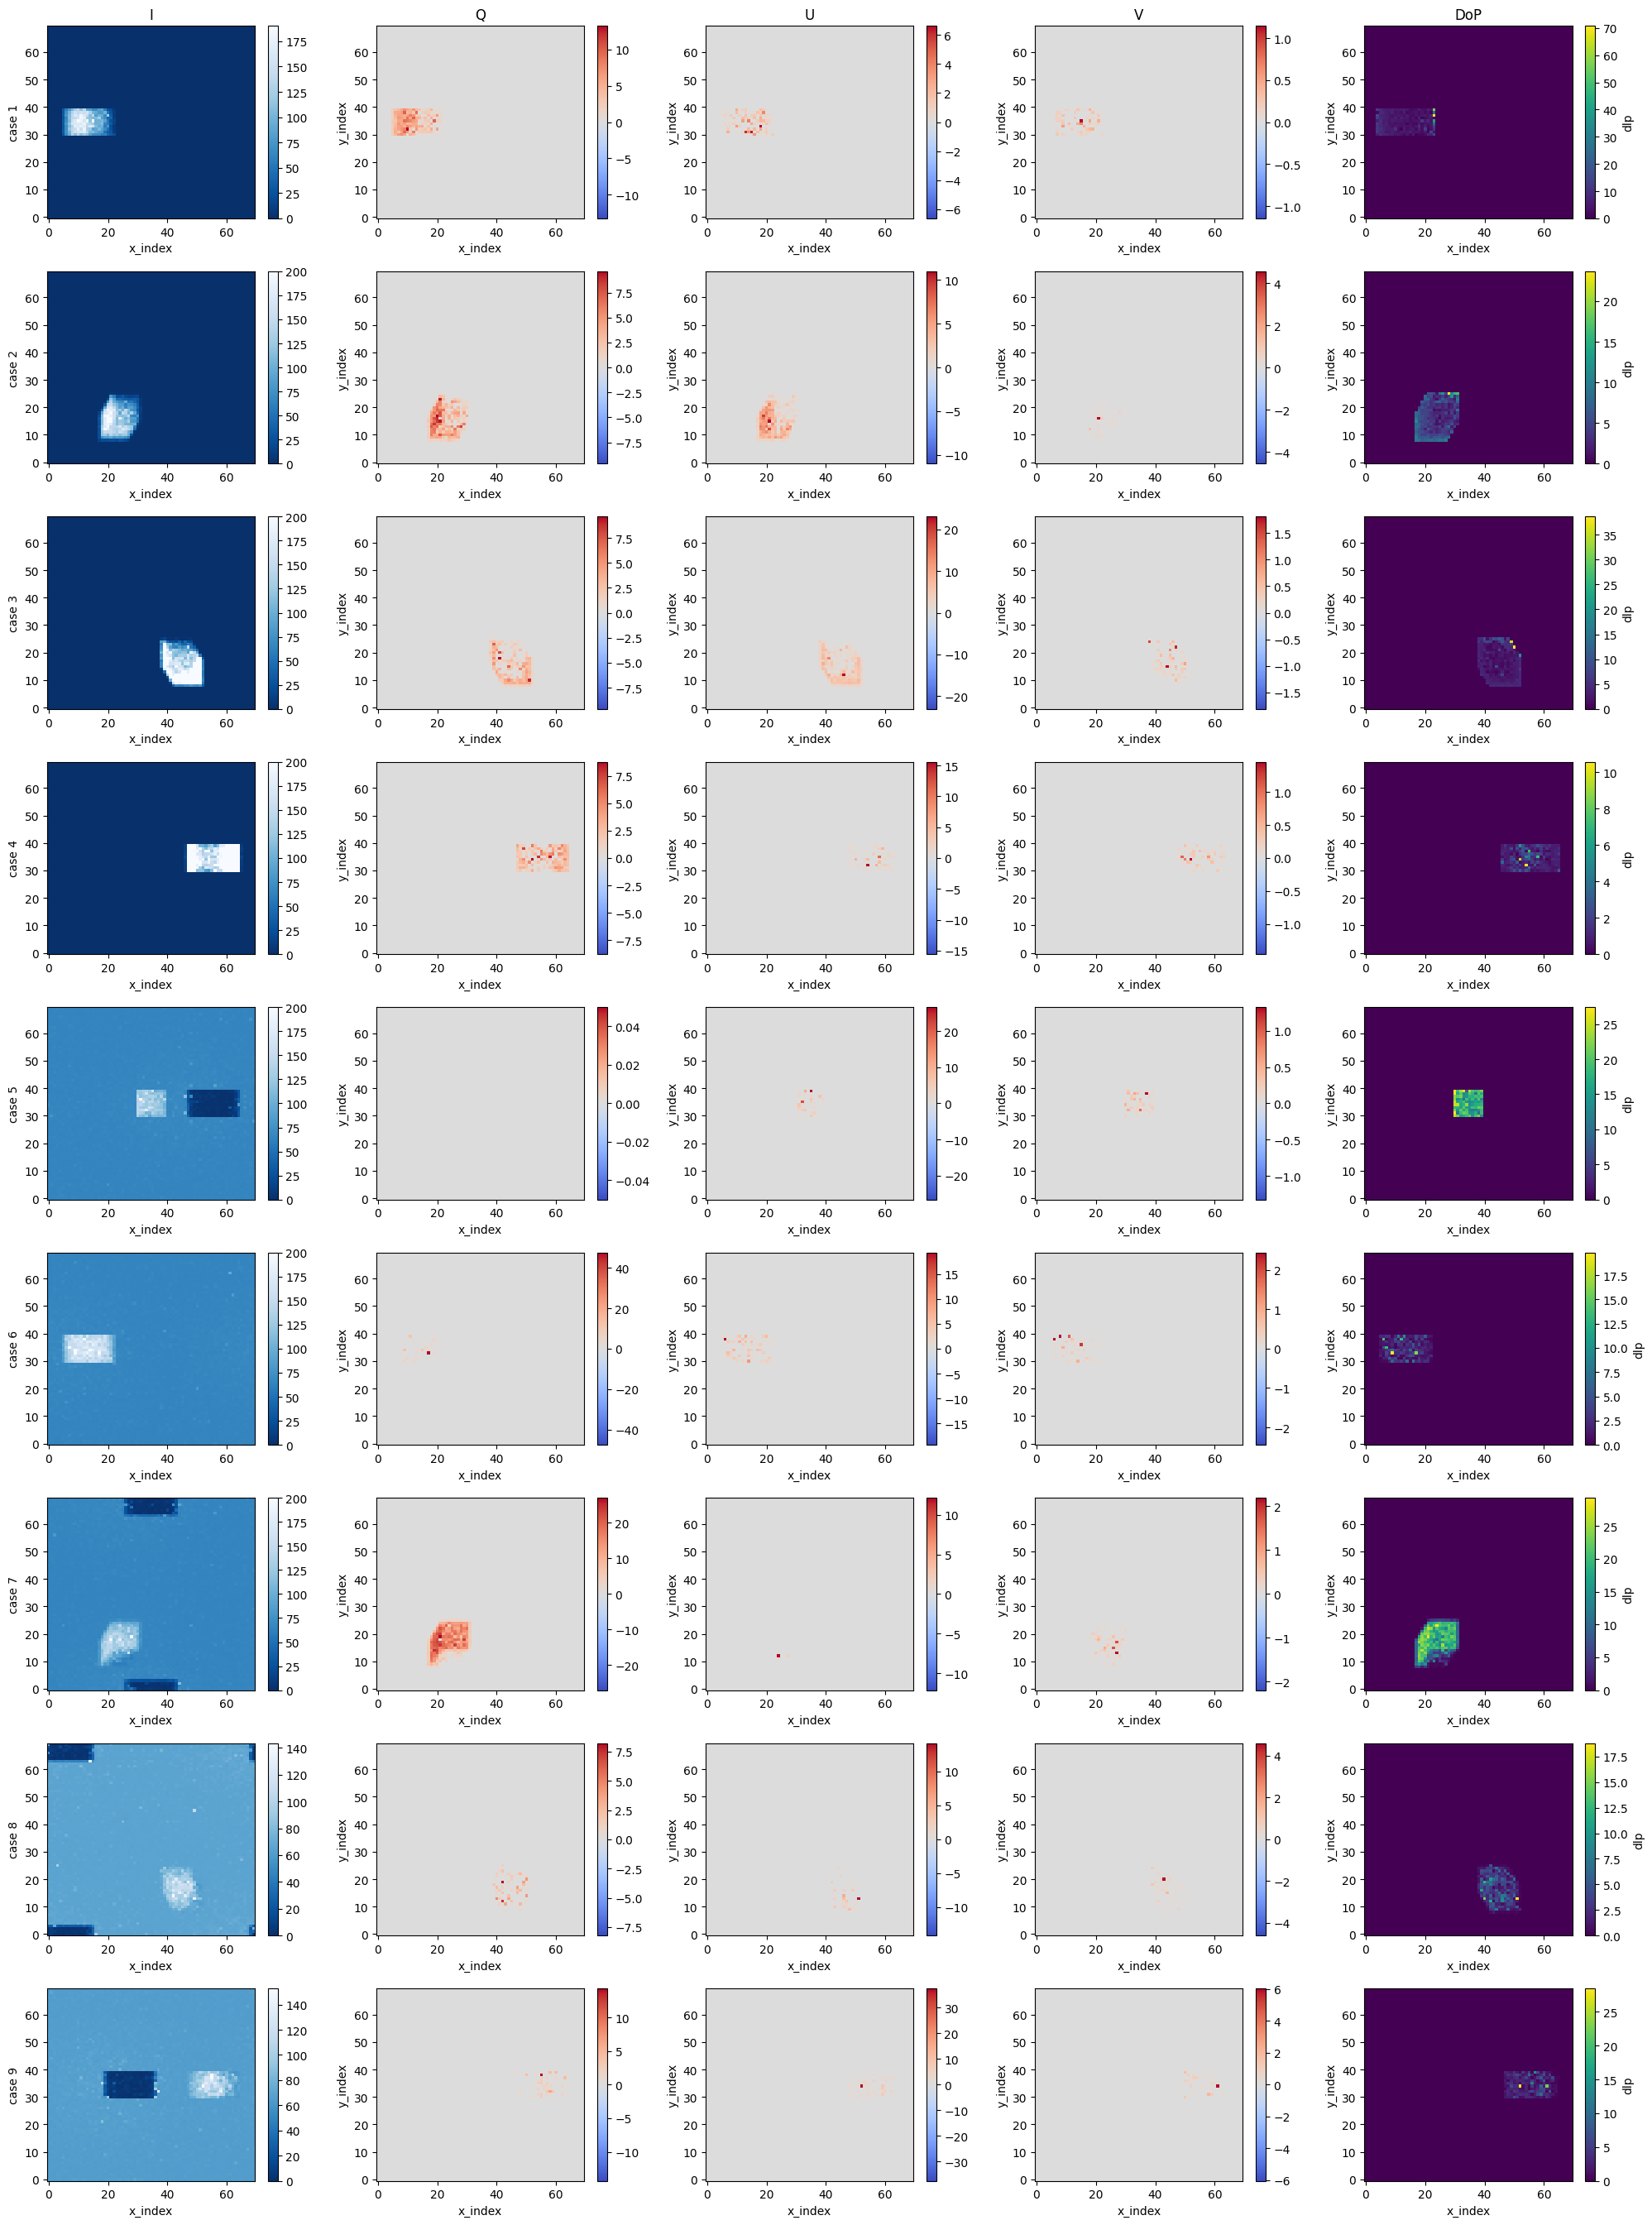

In [56]:
def make_iprt_panel_plot(results):
    fig, axs = plt.subplots(len(results.index), 5, figsize=(20, len(results.index) * 3))
    cmaps = ["Blues_r", "coolwarm", "coolwarm", "coolwarm", "viridis"]

    if not np.ndim(axs) >= 2:
        axs = [axs]

    for i, key in enumerate(tqdm(results.index)):
        case = results[key]

        for j, s in enumerate(["I", *polcmps]):
            ax = axs[i][j]
            cmap = cmaps[j]
            stokes_comp = case.sel(stokes=s).radiance.squeeze()
            stokes_normed = stokes_comp / case.irradiance.squeeze() * 1e3
            stokes_normed = np.clip(stokes_normed, 0, 200)
            vms = dict(vmin=0)
            if s in polcmps:
                vmin = abs(stokes_normed.min().item())
                vmax = abs(stokes_normed.max().item())
                vmin, vmax = min(-vmin, -vmax), max(vmin, vmax)
                vms = dict(vmin=vmin, vmax=vmax)
            stokes_normed.plot(
                ax=ax,
                cmap=cmap,
                **vms,
            )
            ax.set_title(None)
            if i == 0:
                ax.set_title(s)
            if j == 0:
                ax.set_ylabel(f"case {key}")

        dlp_percent = case.dlp.squeeze().fillna(0) * 100
        dlp_percent.plot(ax=axs[i][4])
        axs[i][4].set_title(None)
        if i == 0:
            axs[i][4].set_title("DoP")

    return fig, axs


make_iprt_panel_plot(c2_results)

plt.tight_layout()

#print("Save pdf...")

#plt.savefig("c2_iprt_panel.pdf", format="pdf")
#plt.savefig("c2_iprt_panel.png")

#print("Output images...")

plt.show()
plt.close()

#print("Done.")

  0%|          | 0/9 [00:00<?, ?it/s]

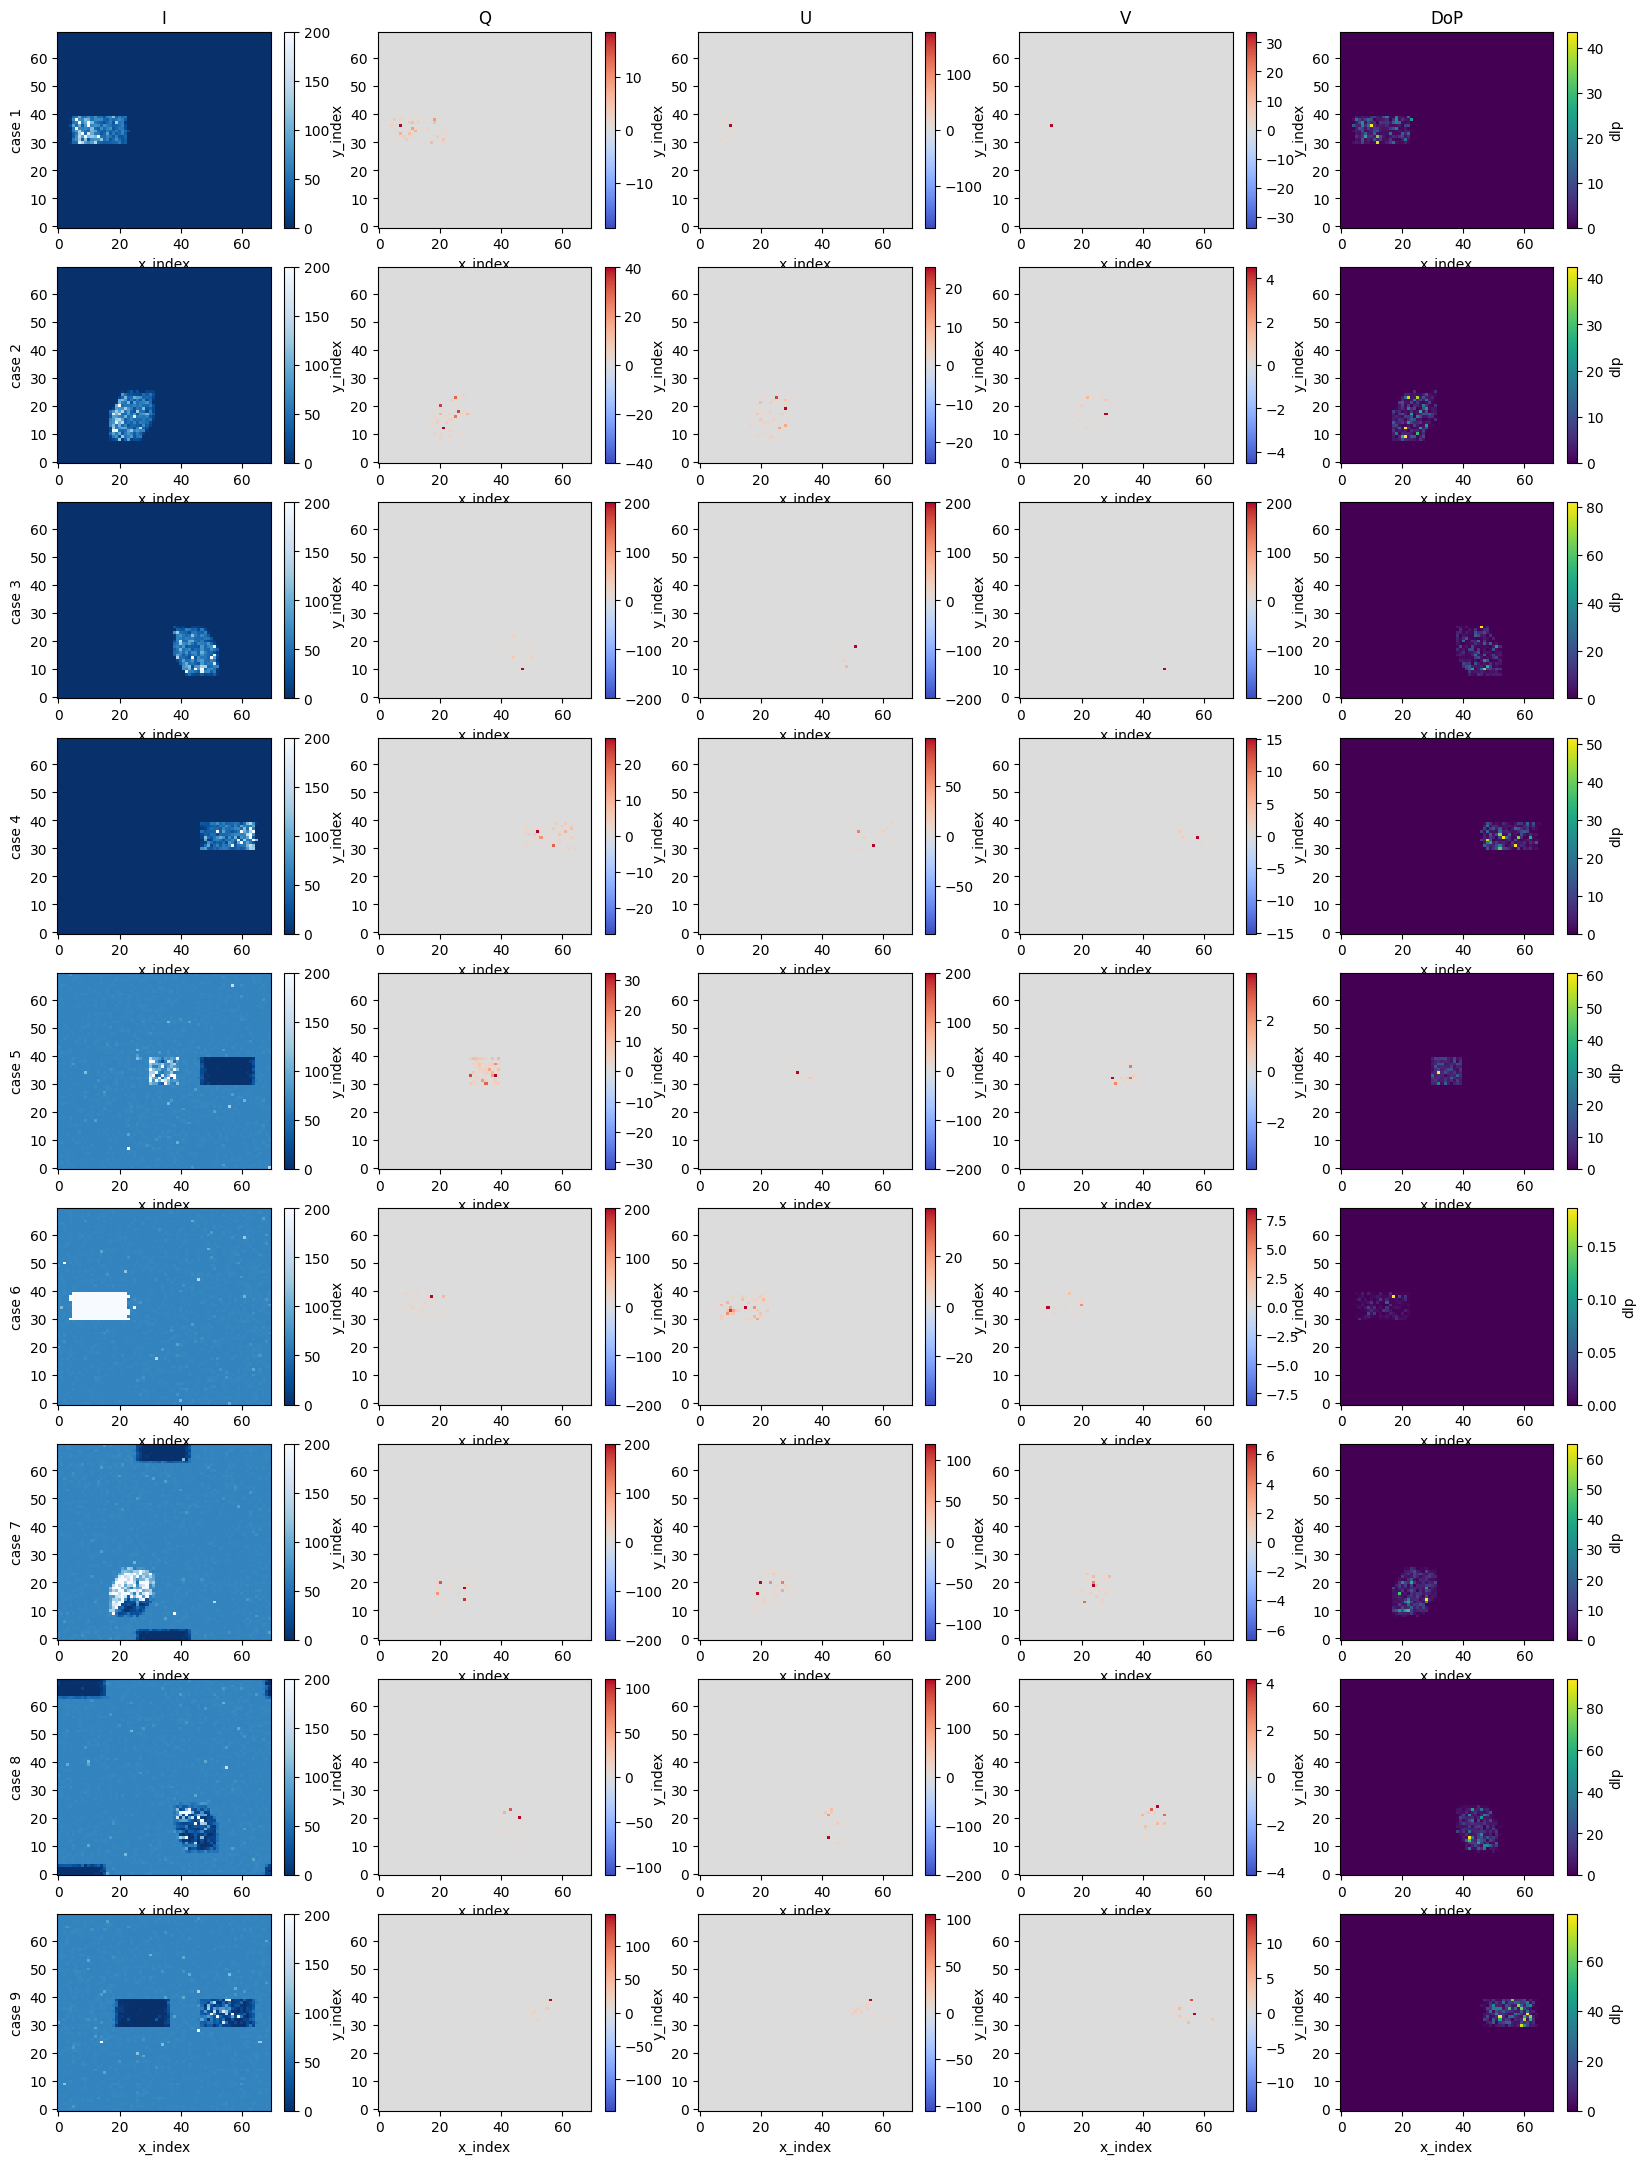

In [57]:
make_iprt_panel_plot(c2_results_r)
plt.show()
plt.close()

In [58]:
for i, key in enumerate(tqdm(c2_results.index)):
    c2_results[key].to_netcdf(f"results/iprt_c2_noatm_{key}_spp{c2_spp}_eradiate.nc")

  0%|          | 0/9 [00:00<?, ?it/s]

### 4. Compare with a manual cloud cube definition

Code provided by Claudia Emde here : https://github.com/emdec/eradiate_clouds/tree/main

In [59]:
from mitsuba import Transform4f as T

phase_data = load_aerosol_data(
    "./test_3d_clouds/watercloud.mie.cdf",
    particle_shape="spherical",
    wavelength=800 * ureg.nm,
)
cloud_cube = {
    "type": "cube",
    "to_world": T.translate([3.5e3, 3.5e3, 2.5e3]).scale(0.5e3),
    "bsdf": {"type": "null"},  # cube surface is transparent
    "interior": {
        "type": "homogeneous",
        "scale": 1.0,
        "albedo": 1.0,
        "sigma_t": 0.01,
        "phase": {
            "type": "tabphase_polarized",
            "m11": ",".join(map(str, phase_data.phase[0, :, 0, 0].data)),
            "m12": ",".join(map(str, phase_data.phase[0, :, 0, 1].data)),
            "m33": ",".join(map(str, phase_data.phase[0, :, 2, 2].data)),
            "m34": ",".join(map(str, phase_data.phase[0, :, 2, 3].data)),
            "m44": ",".join(map(str, phase_data.phase[0, :, 3, 3].data)),
            "m22": ",".join(map(str, phase_data.phase[0, :, 1, 1].data)),
            "nodes": ",".join(map(str, phase_data.mu[:].data)),
        },
    },
}
geometry = eradiate.scenes.geometry.PlaneParallelGeometry(
    toa_altitude=5.0 * ureg.km,
    ground_altitude=0.0 * ureg.km,
    grid=np.linspace(0.0, 5.0, 6) * ureg.km,
)
measure = {
    "type": "perspective",
    "origin": [3.5e3, 3.5e3, 10000.0e3],
    "target": [3.5e3, 3.5e3, 0.0e3],
    "fov": np.arcsin(0.0007) * 180.0 / np.pi,
    "up": [0, 1, 0],
    "film_resolution": (70, 70),
    "srf": DeltaSRF(c2_w_ref),
}
integrator = eradiate.scenes.integrators.EOVolPathIntegrator()
exp = eradiate.experiments.AtmosphereExperiment(
    kdict={"cloud": cloud_cube},
    surface={
        "type": "lambertian",
        "reflectance": 0.2,
    },
    illumination={
        "type": "directional",
        "zenith": 40,
        "azimuth": 180,
        "irradiance": 1.0,
    },
    atmosphere=eradiate.scenes.atmosphere.HomogeneousAtmosphere(
        sigma_s=0.0, sigma_a=0.0
    ),
    geometry=geometry,
    measures=measure,
    integrator=integrator,
)

exp.integrator.stokes = True

In [60]:
import mitsuba as mi

from eradiate import KernelContext, traverse

cube = mi.load_dict(cloud_cube["interior"])
cube_phase = mi.load_dict(cloud_cube["interior"]["phase"])
tmpl, pmap = traverse(c2_particle_layer)
kdict = tmpl.render(
    KernelContext(si=eradiate.spectral.MonoSpectralIndex(800 * ureg.nm))
)
part_phase = mi.load_dict(kdict["phase_atmosphere"])

In [61]:
kdict.keys()

dict_keys(['phase_atmosphere', 'medium_atmosphere', 'shape_atmosphere'])

In [62]:
cube_phase


TabulatedPolarizedPhaseFunction[
  distr = IrregularContinuousDistribution[
    size = 450,
    nodes = [-1, -0.999998, -0.999994, -0.999986, -0.999976,    440 skipped .., 0.999976, 0.999986, 0.999994, 0.999998, 1],
    integral = 2.00256,
    pdf = [0.678165, 0.670924, 0.649945, 0.617368, 0.576427,    440 skipped .., 3153.96, 3323.74, 3451.29, 3530.44, 3557.28],
  ]
]

In [63]:
part_phase


TabulatedPolarizedPhaseFunction[
  distr = IrregularContinuousDistribution[
    size = 450,
    nodes = [-1, -0.999998, -0.999994, -0.999986, -0.999976,    440 skipped .., 0.999976, 0.999986, 0.999994, 0.999998, 1],
    integral = 2.00256,
    pdf = [0.678165, 0.670924, 0.649945, 0.617368, 0.576427,    440 skipped .., 3153.96, 3323.74, 3451.29, 3530.44, 3557.28],
  ]
]

In [64]:
np.asarray(kdict["medium_atmosphere"]["albedo"]["grid"])[2, 3, 3]

np.float64(0.9999788307249806)

In [65]:
np.asarray(kdict["medium_atmosphere"]["sigma_t"]["grid"])[2, 3, 3]

np.float64(0.01)

In [66]:
%%time

run1 = eradiate.run(exp, spp=100)

/home/miskn/git/erd_multi/.pixi/envs/dev/lib/python3.10/site-packages/pint/facets/plain/quantity.py:1006: RuntimeWarning: invalid value encountered in scalar divide
  magnitude = magnitude_op(new_self._magnitude, other._magnitude)


CPU times: user 4.43 s, sys: 0 ns, total: 4.43 s
Wall time: 523 ms


In [67]:
%%time

exp2 = CanopyAtmosphereExperiment(
    atmosphere=c2_particle_layer,
    surface={"type": "lambertian", "reflectance": 0.2},
    measures={
        "type": "perspective",
        "origin": [0, 0, 10000.0e3],
        "target": [0, 0, 0.0e3],
        "fov": np.arcsin(0.0007) * 180.0 / np.pi,
        "up": [0, 1, 0],
        "film_resolution": (70, 70),
        "srf": DeltaSRF(c2_w_ref),
    },
    illumination={
        "type": "directional",
        "zenith": 40,
        "azimuth": 180,
        "irradiance": 1.0,
    },
    geometry=c2_geom,
    integrator=integrator,
)
run2 = eradiate.run(exp2, spp=100)

CPU times: user 21.5 s, sys: 3.8 ms, total: 21.5 s
Wall time: 1.55 s


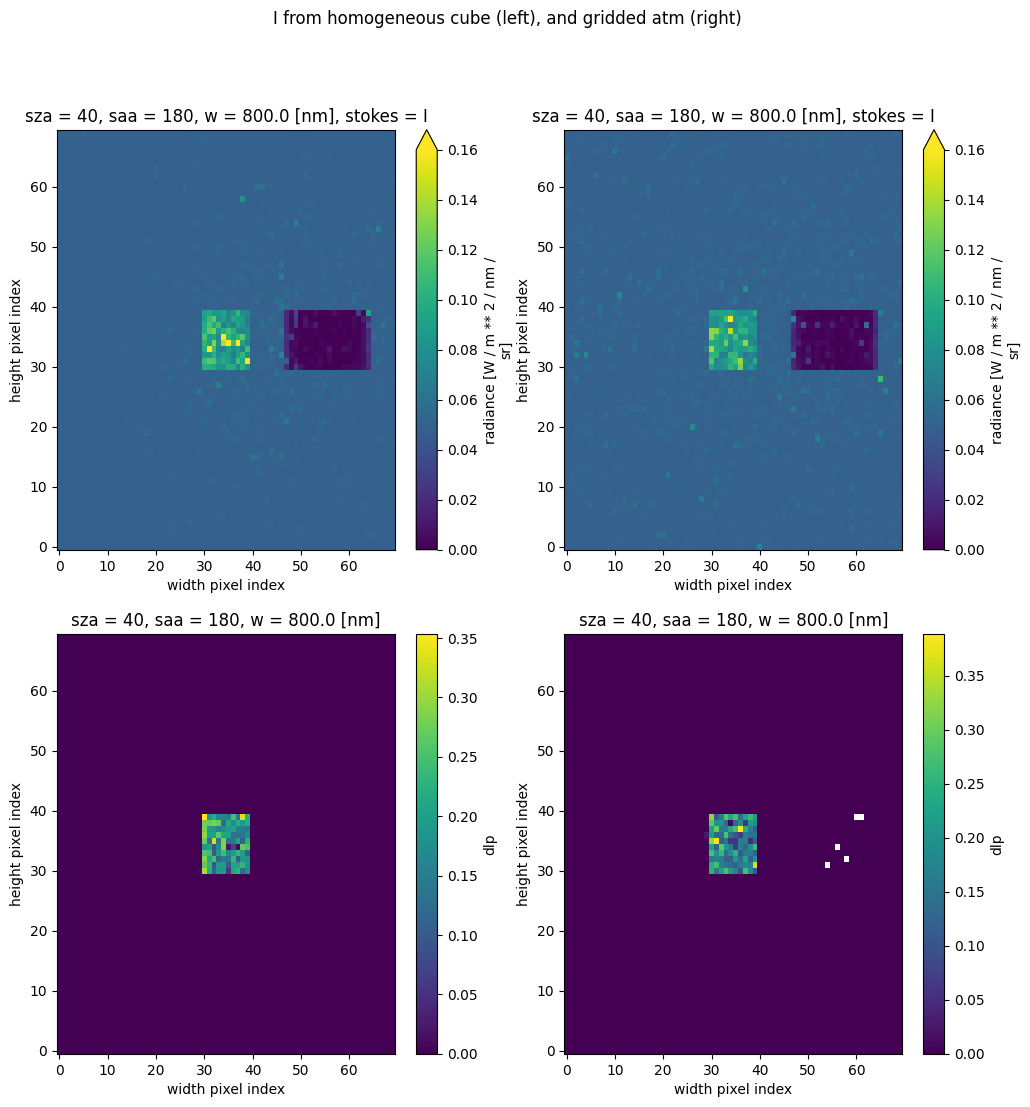

In [68]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
run1.radiance.sel(stokes="I").plot(ax=axs[0][0], vmin=0, vmax=0.16)
run2.radiance.sel(stokes="I").plot(ax=axs[0][1], vmin=0, vmax=0.16)
run1.dlp.plot(ax=axs[1][0])
run2.dlp.plot(ax=axs[1][1])
plt.suptitle("I from homogeneous cube (left), and gridded atm (right)")
plt.show()
plt.close()

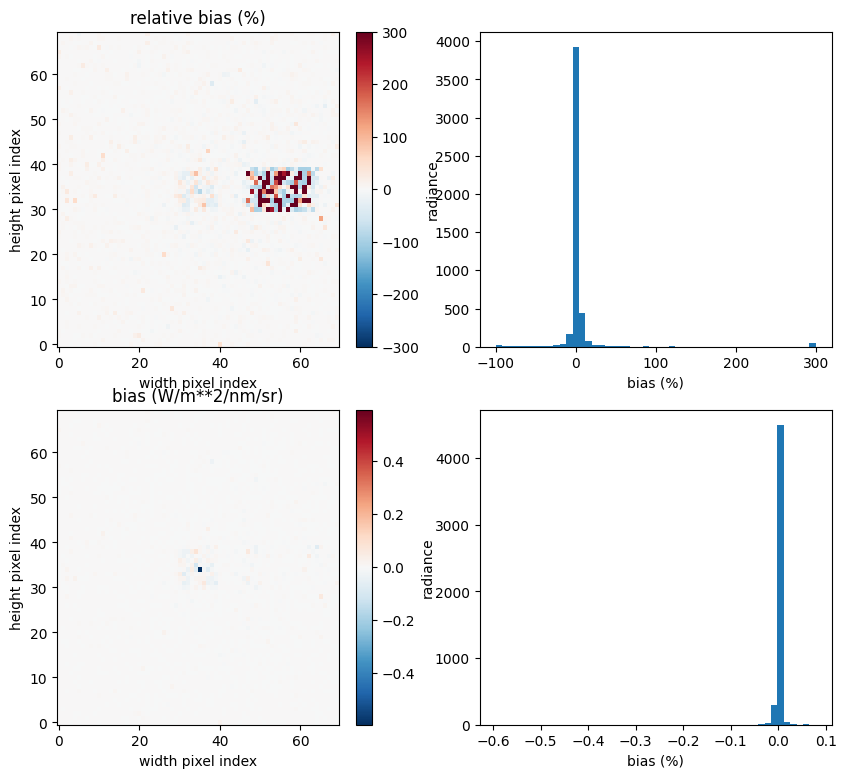

In [69]:
fig, axs = plt.subplots(2, 2, figsize=(10, 9))
rbias = ((run2.radiance - run1.radiance) / run1.radiance * 100).clip(-300, 300)
rbias.sel(stokes="I").plot(ax=axs[0][0])
axs[0][0].set_title("relative bias (%)")
axs[0][1].hist(rbias.sel(stokes="I").values.ravel(), bins=50)
axs[0][1].set_xlabel("bias (%)")
bias = run2.radiance - run1.radiance
bias.sel(stokes="I").plot(ax=axs[1][0])
axs[1][0].set_title("bias (W/m**2/nm/sr)")
axs[1][1].hist(bias.sel(stokes="I").values.ravel(), bins=50)
axs[1][1].set_xlabel("bias (%)")
plt.show()
plt.close()

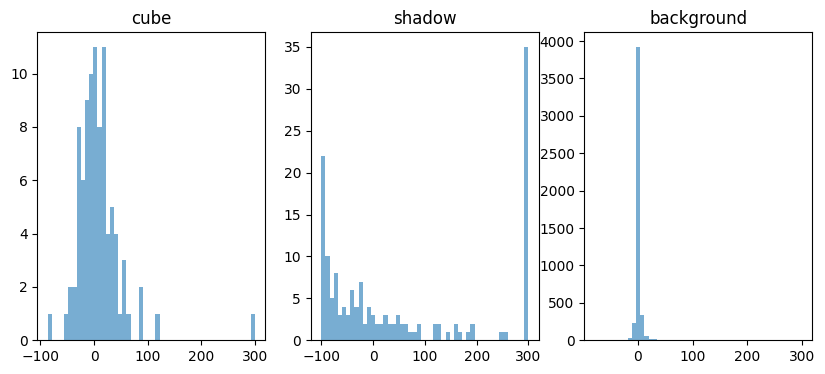

In [70]:
fig, axs = plt.subplots(1, 3, figsize=(10, 4))
icmp2 = run2.radiance.sel(stokes="I")
cube_mask = icmp2 > 0.075
bckg_mask = (icmp2 > 0.01) & ~cube_mask
shdw_mask = ~(cube_mask | bckg_mask)
axs[0].hist(rbias.sel(stokes="I").where(cube_mask).values.ravel(), bins=50, alpha=0.6)
axs[0].set_title("cube")
axs[1].hist(rbias.sel(stokes="I").where(shdw_mask).values.ravel(), bins=50, alpha=0.6)
axs[1].set_title("shadow")
axs[2].hist(rbias.sel(stokes="I").where(bckg_mask).values.ravel(), bins=50, alpha=0.6)
axs[2].set_title("background")
plt.show()
plt.close()

### 5. Comparison with Mystic on vacuum observations

In [71]:
data_mystic = np.loadtxt("./test_3d_clouds/iprt_case_c2_mystic.dat")

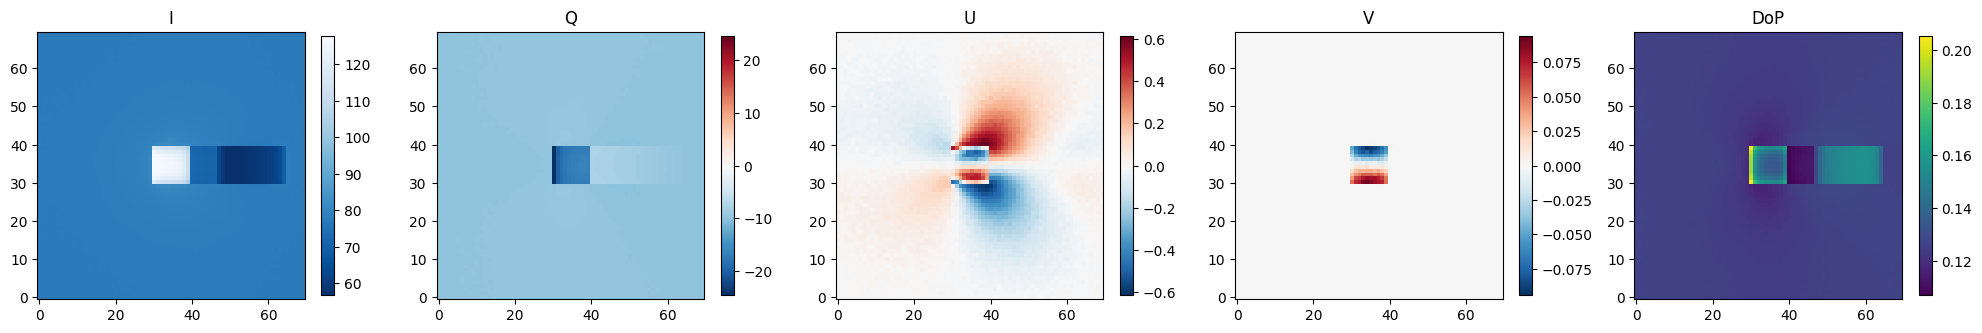


(
    <Figure size 2000x400 with 10 Axes>,
    array([<Axes: title={'center': 'I'}>, <Axes: title={'center': 'Q'}>,
       <Axes: title={'center': 'U'}>, <Axes: title={'center': 'V'}>,
       <Axes: title={'center': 'DoP'}>], dtype=object)
)

In [72]:
from test_3d_clouds import plot_stokes_from_ascii

mask = (
    (data_mystic[:, 0] == 2)  # case 1 no atmosphere, 2 atmosphere
    & (data_mystic[:, 1] == 40)  # theta0
    & (data_mystic[:, 2] == 5)  # zout
    & (data_mystic[:, 3] == 180)  # theta
    & (data_mystic[:, 4] == 0)  # phi
)

result_mystic = data_mystic[mask]

plot_stokes_from_ascii(result_mystic * 1e3)

In [73]:
mystic_df = pd.DataFrame(data=data_mystic, columns=cols + idx + values)
mystic_df = mystic_df.pivot(columns=cols, index=idx, values=values)
mystic_df["Q"]

case        1.0                                                       2.0  \
theta_0    20.0                    40.0                              20.0   
z           0.0                     5.0                               0.0   
theta     40.0                    180.0 140.0                       40.0    
phi       0.0   60.0  120.0 180.0 0.0   0.0   60.0  120.0 180.0     0.0     
i_x  i_y                                                                    
1.0  1.0    0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0 -0.022605   
     2.0    0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0 -0.022607   
     3.0    0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0 -0.022619   
     4.0    0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0 -0.022624   
     5.0    0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0 -0.022571   
...         ...   ...   ...   ...   ...   ...   ...   ...   ...       ...   
70.0 66.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0 -0.022594   
     67.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0 -0.022629   
     68.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0 -0.022609   
     69.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0 -0.022605   
     70.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0 -0.022603   

case                                                                   \
theta_0                                      40.0                       
z                                             5.0                       
theta                                       180.0     140.0             
phi           60.0      120.0     180.0     0.0       0.0       60.0    
i_x  i_y                                                                
1.0  1.0  -0.013523 -0.003336 -0.002424 -0.009807  0.002482  0.009005   
     2.0  -0.013534 -0.003322 -0.002384 -0.009782  0.002506  0.009010   
     3.0  -0.013532 -0.003311 -0.002395 -0.009792  0.002478  0.009007   
     4.0  -0.013516 -0.003319 -0.002389 -0.009792  0.002493  0.009027   
     5.0  -0.013513 -0.003324 -0.002377 -0.009799  0.002474  0.009014   
...             ...       ...       ...       ...       ...       ...   
70.0 66.0 -0.013520 -0.003367 -0.002382 -0.009805  0.002513  0.009007   
     67.0 -0.013527 -0.003339 -0.002390 -0.009797  0.002498  0.008999   
     68.0 -0.013530 -0.003353 -0.002400 -0.009788  0.002494  0.009024   
     69.0 -0.013529 -0.003340 -0.002393 -0.009799  0.002484  0.009000   
     70.0 -0.013543 -0.003350 -0.002396 -0.009788  0.002498  0.009014   

case                           
theta_0                        
z                              
theta                          
phi           120.0     180.0  
i_x  i_y                       
1.0  1.0  -0.005911 -0.028308  
     2.0  -0.005818 -0.028304  
     3.0  -0.005736 -0.028304  
     4.0  -0.005710 -0.028298  
     5.0  -0.005737 -0.028297  
...             ...       ...  
70.0 66.0 -0.006402 -0.028299  
     67.0 -0.006323 -0.028295  
     68.0 -0.006227 -0.028316  
     69.0 -0.006140 -0.028299  
     70.0 -0.006043 -0.028300  

[4900 rows x 18 columns]

In [74]:
def eradiate_conversion(case):
    def wrapped(ds):
        df = ds.item().to_dataframe()
        df = df.reset_index()
        # df["radiance"] /= df.irradiance.values
        df["radiance_std"] = np.sqrt(df.radiance_var)  # / df.irradiance
        df["theta"] = 180 - df.vza
        df["theta_0"] = df.sza
        df["i_x"] = df["x_index"] + 1
        df["i_y"] = df["y_index"] + 1
        df["phi"] = np.abs(df.vaa - 180)
        df = df.drop(
            [
                "vza",
                "vaa",
                "y",
                "x",
                "dlp",
                "irradiance",
                "x_index",
                "y_index",
                "w",
                "saa",
                "sza",
                "radiance_var",
            ],
            axis=1,
        )
        df = df[
            [
                "stokes",
                "radiance",
                "radiance_std",
                "phi",
                "theta",
                "theta_0",
                "i_x",
                "i_y",
            ]
        ]

        df = [
            x.rename(dict(radiance=c, radiance_std=f"{c}std"), axis=1).drop(
                ["stokes"], axis=1
            )
            for c, x in df.groupby("stokes")
        ]
        df = [x.set_index(["phi", "theta", "theta_0", "i_x", "i_y"]) for x in df]
        df = pd.concat(df, axis=1).reset_index()
        df["case"] = case
        #print(df)
        #print(ds.index[0], type(ds.index[0]), ds.index[0] > "4", df.index)
        df["z"] = 5 
        df.loc[df.theta_0 < 30, "z"] = 0
        return df

    return wrapped


def make_iprt_dataframe(results, case=1):
    conversion_case = eradiate_conversion(case)
    df = pd.concat(results.to_frame().apply(conversion_case, axis=1).tolist())
    df = df.pivot(columns=cols, index=idx, values=values)
    return df

In [75]:
erd_df1 = make_iprt_dataframe(c2_results, case=1)

In [76]:
erd_dfr = make_iprt_dataframe(c2_results_r, case=1)

/home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [77]:
erd_df1

I                                                            \
case        1                                                             
theta_0    20                          40                                 
z           0                           5                                 
theta   40.0                        180.0     140.0                       
phi     0.0   60.0  120.0 180.0     180.0     0.0       60.0      120.0   
i_x i_y                                                                   
1   1     0.0   0.0   0.0   0.0  0.049326  0.049372  0.049799  0.002293   
    2     0.0   0.0   0.0   0.0  0.049469  0.049418  0.049706  0.001921   
    3     0.0   0.0   0.0   0.0  0.049808  0.049074  0.049933  0.003881   
    4     0.0   0.0   0.0   0.0  0.049872  0.049750  0.049773  0.019193   
    5     0.0   0.0   0.0   0.0  0.049217  0.049555  0.049977  0.050362   
..        ...   ...   ...   ...       ...       ...       ...       ...   
70  66    0.0   0.0   0.0   0.0  0.049205  0.049558  0.050321  0.006775   
    67    0.0   0.0   0.0   0.0  0.049411  0.049916  0.049588  0.005419   
    68    0.0   0.0   0.0   0.0  0.049690  0.049342  0.050203  0.006504   
    69    0.0   0.0   0.0   0.0  0.049387  0.049849  0.050749  0.006843   
    70    0.0   0.0   0.0   0.0  0.050042  0.049389  0.049398  0.019459   

                      Q  ...  Ustd  Vstd                                      \
case                  1  ...     1     1                                       
theta_0              20  ...    40    20                      40               
z                     0  ...     5     0                       5               
theta             40.0   ... 140.0 40.0                    180.0 140.0         
phi         180.0 0.0    ... 180.0 0.0   60.0  120.0 180.0 180.0 0.0   60.0    
i_x i_y                  ...                                                   
1   1    0.049445   0.0  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
    2    0.049322   0.0  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
    3    0.049851   0.0  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
    4    0.049673   0.0  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
    5    0.049573   0.0  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
..            ...   ...  ...   ...   ...   ...   ...   ...   ...   ...   ...   
70  66   0.049680   0.0  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
    67   0.050427   0.0  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
    68   0.049875   0.0  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
    69   0.050903   0.0  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
    70   0.051341   0.0  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   

                     
case                 
theta_0              
z                    
theta                
phi     120.0 180.0  
i_x i_y              
1   1     NaN   NaN  
    2     NaN   NaN  
    3     NaN   NaN  
    4     NaN   NaN  
    5     NaN   NaN  
..        ...   ...  
70  66    NaN   NaN  
    67    NaN   NaN  
    68    NaN   NaN  
    69    NaN   NaN  
    70    NaN   NaN  

[4900 rows x 72 columns]

In [78]:
mystic_df.index = erd_df1.index

In [79]:
erd_df1.loc[:, polcmps] = np.abs(erd_df1[polcmps])
erd_dfr.loc[:, polcmps] = np.abs(erd_dfr[polcmps])
mystic_df.loc[:, polcmps] = np.abs(mystic_df[polcmps])

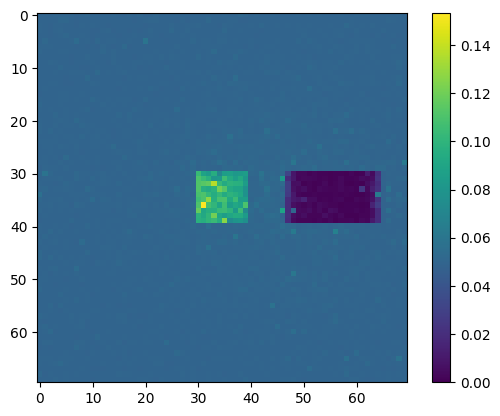

In [80]:
m = max(erd_df1.I.iloc[:, 4].max(), mystic_df.I.iloc[:, 4].max())

plt.colorbar(plt.imshow(erd_df1.I.iloc[:, 4].values.reshape(70, 70).T, vmin=0, vmax=m))

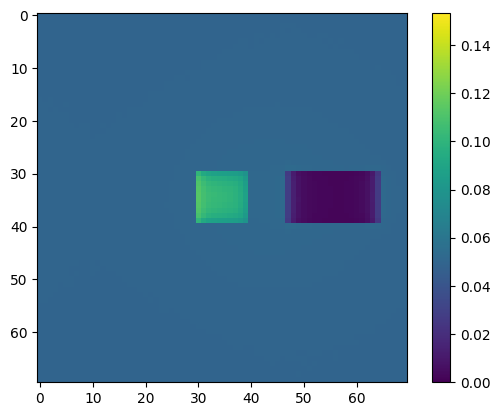

In [81]:
plt.colorbar(
    plt.imshow(mystic_df.I.iloc[:, 4].values.reshape(70, 70).T, vmin=0, vmax=m)
)

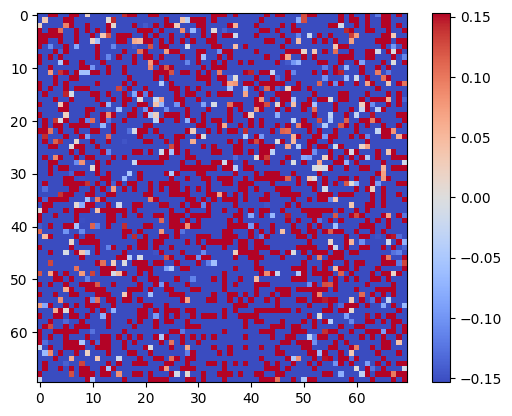

In [82]:
b = (erd_df1.I.iloc[:, 4] - mystic_df.I.iloc[:, 4]) / mystic_df.I.iloc[:, 4] * 100
m = np.max(np.abs(m))
plt.colorbar(plt.imshow(b.values.reshape(70, 70), cmap="coolwarm", vmin=-m, vmax=m))

<Axes: >

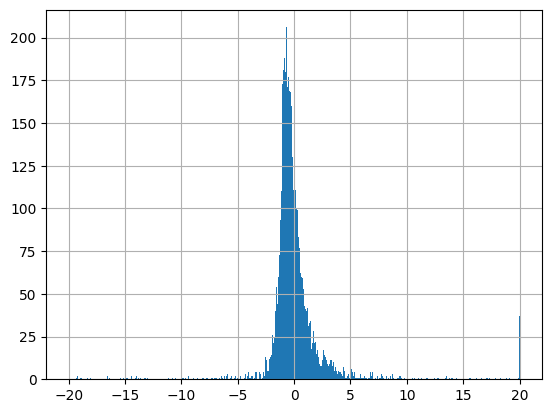

In [83]:
b.clip(-20,20).hist(bins=500)

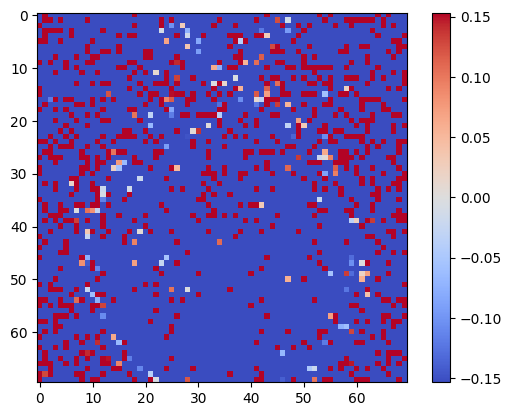

In [84]:
b = (erd_dfr.I.iloc[:, 4] - mystic_df.I.iloc[:, 4]) / mystic_df.I.iloc[:, 4] * 100
m = np.max(np.abs(m))
plt.colorbar(plt.imshow(b.values.reshape(70, 70), cmap="coolwarm", vmin=-m, vmax=m))

<Axes: >

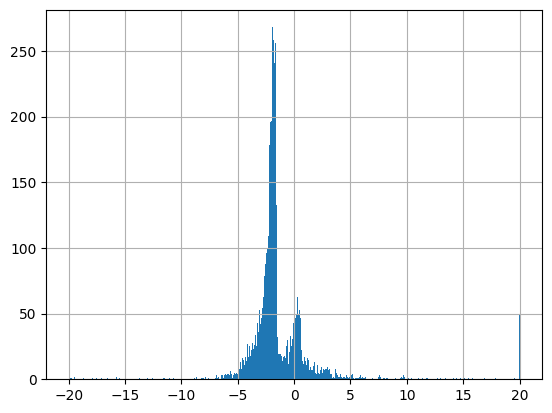

In [85]:
b.clip(-20,20).hist(bins=500)

In [86]:
c2_particle_layer.tau_ref.max()

<Quantity(10.0, 'dimensionless')>

In [87]:
c2_particle_layer.eval_sigma_s_mono(800*ureg.nm, c2_particle_layer.geometry.grid).max()

<Quantity(9.99978831, '1 / kilometer')>

In [88]:
from eradiate.units import to_quantity
aer800_lrbt = xr.load_dataset("test_3d_clouds/watercloud.mie.cdf")
ext_mass = to_quantity(aer800_lrbt.ext)
size = 1 * ureg.km
ot_c2 = 10 * ureg.dimensionless
ext_c2 = ot_c2 / size
mass_density = (ext_c2 / ext_mass).reshape(1)

In [89]:
profile_c2 = xr.Dataset(
    coords=dict(
        index=[1],
        x=range(8),
        y=range(8),
        z=range(6),
        w=(["w"], [800], dict(units="nanometer")),
    ),
    data_vars=dict(
        i_x=(["index"], [3]),
        i_y=(["index"], [3]),
        i_z=(["index"], [2]),
        r_eff=(["index"], [10.0], dict(units="micron")),
        v_eff=(["index"], [1.0 / 9.0], dict(units="micron**2")),
        x_levels=(["x"], c2_particle_layer.geometry.grid.edges_x.m_as("kilometer"), dict(units="kilometer")),
        y_levels=(["y"], c2_particle_layer.geometry.grid.edges_y.m_as("kilometer"), dict(units="kilometer")),
        z_levels=(["z"], c2_particle_layer.geometry.grid.levels.m_as("kilometer"), dict(units="kilometer")),
        mass_density=(["index"], mass_density.m_as("g/m**3"), dict(units="g/m**3"))
    ),
)

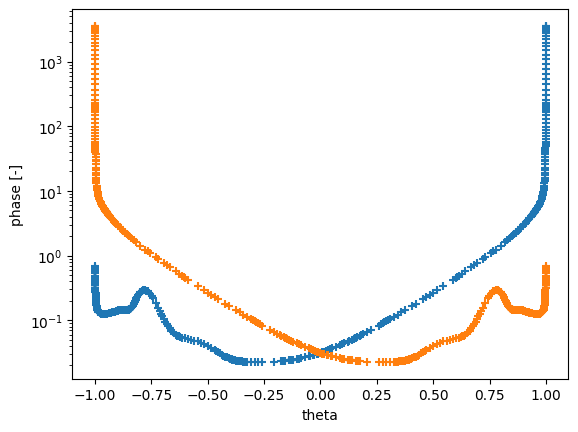

In [90]:
ds_wc800 = xr.load_dataset("test_3d_clouds/watercloud.mie.cdf")
ds_wc800_r = ds_wc800.assign_coords(theta=180.0 - ds_wc800.theta)
ds_wc800.squeeze().assign_coords(theta=np.cos(np.deg2rad(ds_wc800.theta))).isel(nphamat=0).plot.scatter(x="theta", y="phase", marker="+", yscale="log")
ds_wc800_r.squeeze().assign_coords(theta=np.cos(np.deg2rad(ds_wc800_r.theta))).isel(nphamat=0).plot.scatter(x="theta", y="phase", marker="+", yscale="log")
#ds_aer670.phase.squeeze().isel(w=1, i=0, j=0).plot(yscale="log")

In [114]:
from eradiate.scenes.atmosphere import ParticleField, HeterogeneousAtmosphere
c2_field = ParticleField(
    geometry = c2_particle_layer.geometry,
    properties = ds_wc800,
    profile = profile_c2,
)


In [115]:
c2_experiments_f = (
    pd.concat(
        [
            c2_illuminations,
            c2_measures,
        ],
        axis=1,
    )
    .T.apply(
        lambda x: AtmosphereExperiment(
            atmosphere=HeterogeneousAtmosphere(
                particle_field=c2_field
            ),
            surface={
                "type": "basic",
                "shape": {"type": "rectangle", "edges": [5e8, 5e8]},
                "bsdf": {"type": "lambertian", "reflectance": c2_surface_albedo},
            },
            measures=x.measure,
            illumination=x.illumination,
            geometry=c2_geom,
            integrator={"type": c2_integrator, "moment": True, "stokes": True},
        )
    )
    .rename("experiment")
)

In [116]:
c2_field.profile

<xarray.Dataset> Size: 416B
Dimensions:       (index: 1, x: 8, y: 8, z: 6, w: 1)
Coordinates:
  * index         (index) int64 8B 1
  * x             (x) int64 64B 0 1 2 3 4 5 6 7
  * y             (y) int64 64B 0 1 2 3 4 5 6 7
  * z             (z) int64 48B 0 1 2 3 4 5
  * w             (w) int64 8B 800
Data variables:
    i_x           (index) int64 8B 3
    i_y           (index) int64 8B 3
    i_z           (index) int64 8B 2
    r_eff         (index) float64 8B 10.0
    v_eff         (index) float64 8B 0.1111
    x_levels      (x) float64 64B -3.5 -2.5 -1.5 -0.5 0.5 1.5 2.5 3.5
    y_levels      (y) float64 64B -3.5 -2.5 -1.5 -0.5 0.5 1.5 2.5 3.5
    z_levels      (z) float64 48B 0.0 1.0 2.0 3.0 4.0 5.0
    mass_density  (index) float64 8B 0.06301

In [117]:
c2_field.properties

<xarray.Dataset> Size: 48kB
Dimensions:  (nlam: 1, nreff: 1, nphamat: 4, nthetamax: 1000, nmommax: 1000)
Dimensions without coordinates: nlam, nreff, nphamat, nthetamax, nmommax
Data variables:
    wavelen  (nlam) float64 8B 0.8
    reff     (nreff) float64 8B 10.0
    ntheta   (nlam, nreff, nphamat) int32 16B 450 450 450 450
    theta    (nlam, nreff, nphamat, nthetamax) float32 16kB 180.0 179.9 ... nan
    phase    (nlam, nreff, nphamat, nthetamax) float32 16kB 0.6782 ... nan
    nmom     (nlam, nreff, nphamat) int32 16B 1000 1000 1000 1000
    pmom     (nlam, nreff, nphamat, nmommax) float32 16kB 1.0 2.578 ... nan nan
    ext      (nlam, nreff) float64 8B 158.7
    ssa      (nlam, nreff) float64 8B 1.0
    refre    (nlam) float64 8B 1.326
    refim    (nlam) float64 8B 1.25e-07
    rho      (nlam, nreff) float64 8B 1.0
Attributes:
    file_info:         Netcdf file created using libRadtran-Mie-tool
    version:           20110916
    complete_moments:  0
    parameterization:  mie
    size_distr:        Gamma distribution.
    param_alpha:       7.0
    n_r_max:           5.0
    dx_max:            0.003000000026077032

In [118]:

def run_case_f(c):
    res = eradiate.run(c, spp=100)
    return res

In [119]:
from tqdm.notebook import tqdm

c2_results_dct_f = {}



with tqdm(c2_experiments_f, total=len(c2_experiments_f)) as pbar:
    for key in c2_experiments_f.index:
        try:
            c2_results_dct_f[key] = xr.load_dataset(
                f"results/iprt_c2_noatm_{key}_spp{c2_spp}_eradiate_f.nc"
            )
        except FileNotFoundError:
            c2_results_dct_f[key] = run_case_f(c2_experiments_f.loc[key])

        pbar.update()

    c2_results_fr = pd.Series(c2_results_dct_f, name="results")

  0%|          | 0/9 [00:00<?, ?it/s]

In [120]:
def run_case_profile_f():
    res = eradiate.run(c2_experiments_f[5], spp=50)
    return res

def run_case_profile():
    res = eradiate.run(c2_experiments[5], spp=50)
    return res

  0%|          | 0/9 [00:00<?, ?it/s]

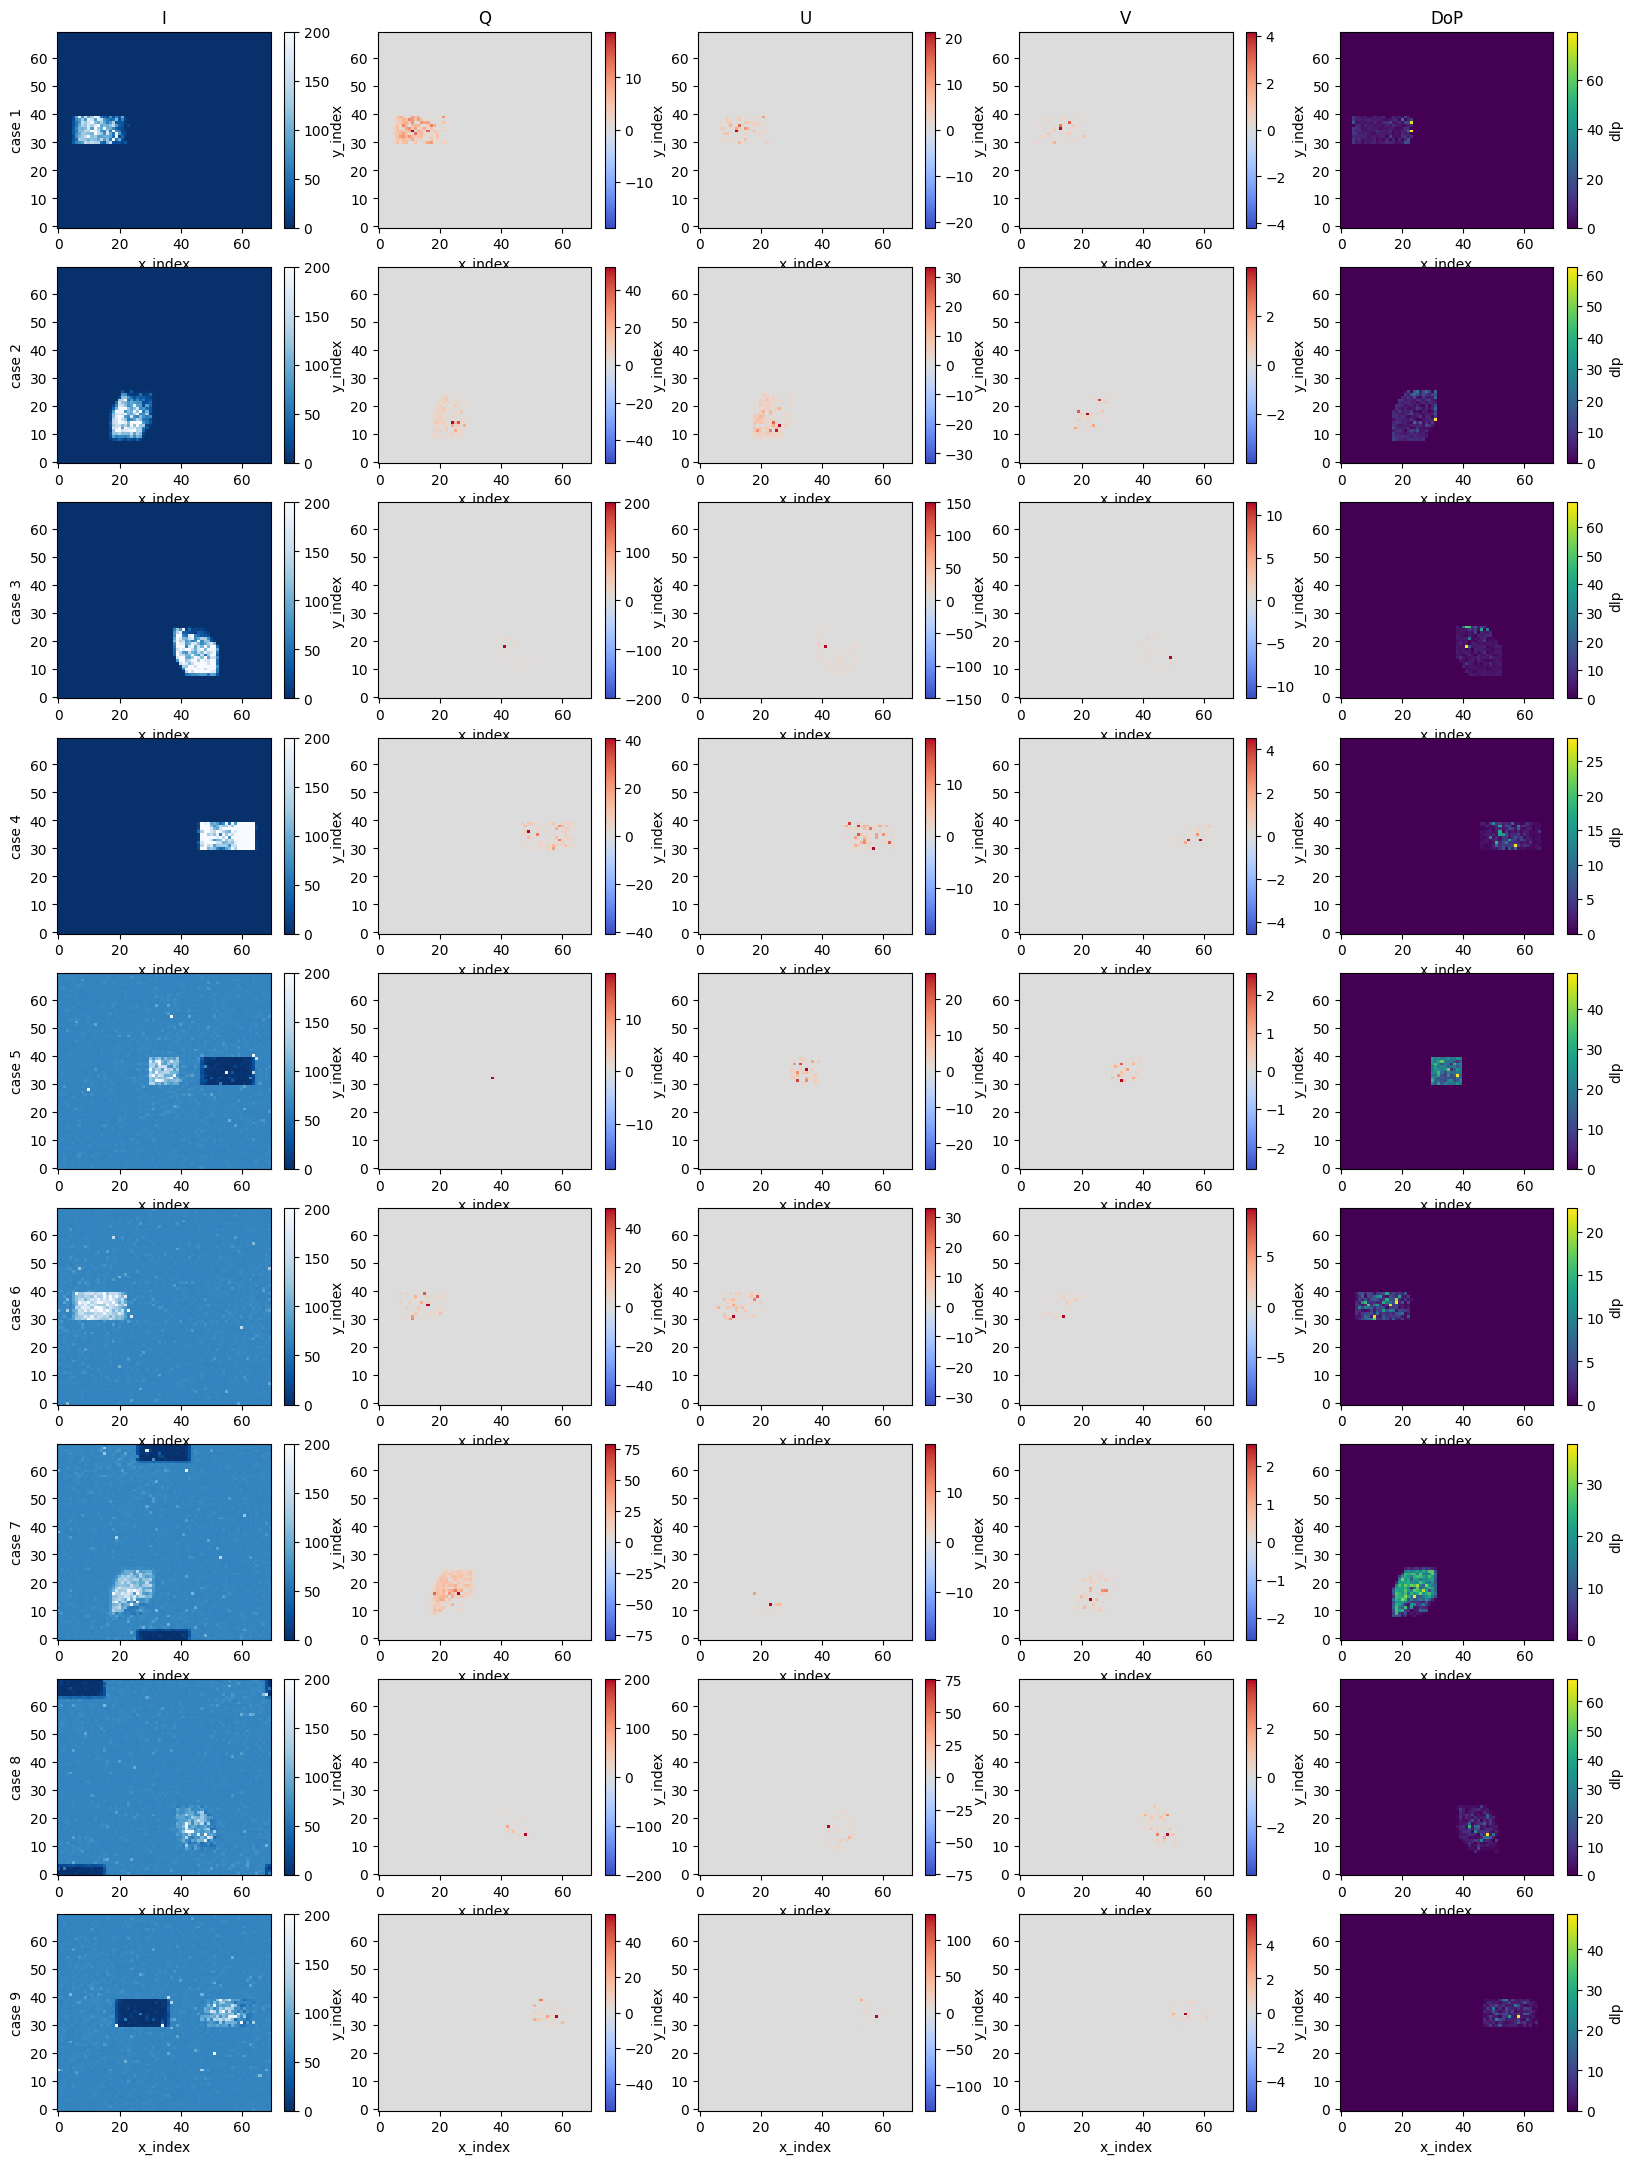

In [121]:
make_iprt_panel_plot(c2_results_fr)
plt.show()
plt.close()

In [99]:
erd_dff = make_iprt_dataframe(c2_results_fr, case=1)
erd_dff.loc[:, polcmps] = np.abs(erd_dff[polcmps])

/home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


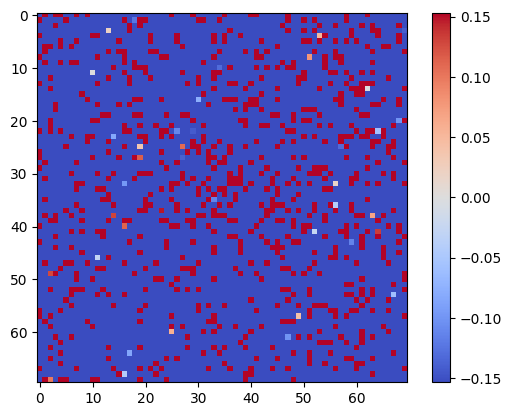

In [100]:
b = (erd_dff.I.iloc[:, 4] - mystic_df.I.iloc[:, 4]) / mystic_df.I.iloc[:, 4] * 100
m = np.max(np.abs(m))
plt.colorbar(plt.imshow(b.values.reshape(70, 70), cmap="coolwarm", vmin=-m, vmax=m))

<Axes: >

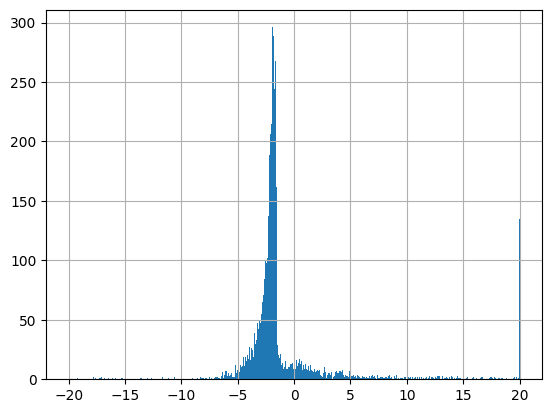

In [101]:
b.clip(-20,20).hist(bins=500)

### 6. Homogeneous atmosphere and cubic cloud case

The second batch of test for C2 includes a homogeneous atmosphere. Let's configure it.

In [79]:
from eradiate.scenes.atmosphere import HeterogeneousAtmosphere
from eradiate.scenes.phase import RayleighPhaseFunction

In [80]:
c2_geometries = pd.DataFrame(
    columns=["sza", "z", "vza", "vaa"],
    index=np.arange(1, 10, 1),
    data=[
        [20, 0, 40, 0],
        [20, 0, 40, 60],
        [20, 0, 40, 120],
        [20, 0, 40, 180],
        [40, 5, 180, 0],
        [40, 5, 140, 0],
        [40, 5, 140, 60],
        [40, 5, 140, 120],
        [40, 5, 140, 180],
    ],
).T
c2_geometries

c2_2_measures = (
    pd.concat([c2_geometries.T, c2_targets], axis=1)
    .T.apply(
        lambda x: MultiPixelDistantMeasure.from_angles(
            angles=(x.vza - 180, x.vaa),
            target=x.target,
            film_resolution=[70, 70],
            srf=DeltaSRF(c2_w_ref),
            id=str(x.name),
            ray_offset=c2_epsilon_dist if x.z < 1 else None,
            spp=c2_spp,
        )
    )
    .rename("measure")
)

In [81]:
def homogeneous_with_cubic(pbar):
    def wrapped(exp):
        hom_atm = eradiate.scenes.atmosphere.HomogeneousAtmosphere(
            geometry=c2_geom,
            sigma_s=0.5 / (5000),
            sigma_a=0.0,
        )
        hom_atm._phase = RayleighPhaseFunction(
            depolarization=np.array([0]), geometry=c2_geom
        )
        exp = AtmosphereExperiment(
            atmosphere=HeterogeneousAtmosphere(
                molecular_atmosphere=None,
                particle_layers=[c2_particle_layer],
                geometry=c2_geom,
                particle_field=hom_atm,
            ),
            surface=dict(type="lambertian", reflectance=0.2),
            illumination=exp.illumination,
            geometry=c2_geom,
            integrator=dict(type=c2_integrator, stokes=True, moment=True),
            measures=exp.measures,
        )
        pbar.update()
        return exp

    return wrapped


def compute_exp(pbar, spp):
    def wrapped(exp):
        res = eradiate.run(exp, spp=spp)
        pbar.update()
        return res

    return wrapped

In [82]:
with tqdm(range(9)) as pbar:
    c2_2_experiments = c2_experiments.apply(homogeneous_with_cubic(pbar))

  0%|          | 0/9 [00:00<?, ?it/s]

In [83]:
%%time

import drjit as dr
dr.set_thread_count(23)

c2_2_results_dct = {}


def run_case(c):
    res = eradiate.run(c, spp=c2_spp)
    return res


with tqdm(c2_2_experiments, total=len(c2_2_experiments)) as pbar:
    for key in c2_2_experiments.index:
        try:
            c2_2_results_dct[key] = xr.load_dataset(
                f"results/iprt_c2_2_homatm_{key}_spp{c2_spp}_eradiate.nc"
            )
            print(key)
            pbar.update()
        except FileNotFoundError:
            c2_2_results_dct[key] = run_case(c2_2_experiments.loc[key])
            c2_2_results_dct[key].to_netcdf(f"results/iprt_c2_2_homatm_{key}_spp{c2_spp}_eradiate.nc")
            pbar.update()


    c2_2_results = pd.Series(c2_2_results_dct, name="results")

  0%|          | 0/9 [00:00<?, ?it/s]

1
2
3
4
5
6
7
8
9
CPU times: user 53.2 ms, sys: 8.02 ms, total: 61.2 ms
Wall time: 58.5 ms


In [84]:
#make_iprt_panel_plot(c2_2_results)
#
#plt.tight_layout()
#
#print("Save pdf...")
#
#plt.savefig("c2_2_iprt_panel.pdf", format="pdf")
#plt.savefig("c2_2_iprt_panel.png")
#
#print("Output images...")
#
#plt.show()
#plt.close()
#
#print("Done.")

In [85]:
erd_df2 = make_iprt_dataframe(c2_2_results, case=2)

/home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/miskn/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: i

In [86]:
erd_df2

I                                                              \
case            2                                                               
theta_0        20                                      40                       
z               0                                       5                       
theta       40.0                                    180.0     140.0             
phi         0.0       60.0      120.0     180.0     180.0     0.0       60.0    
i_x i_y                                                                         
1   1    0.160805  0.157782  0.000000  0.409207  0.077231  0.244000  0.093437   
    2    0.056827  0.000000  0.000000  0.068948  0.070439  0.160774  0.025390   
    3    0.127906  0.000000  0.059231  0.000000  0.089343  0.041504  0.053312   
    4    0.000000  0.081421  0.000000  0.000000  0.109360  0.072759  0.025390   
    5    0.000000  0.112039  0.000000  0.103389  0.033999  0.040980  0.043734   
..            ...       ...       ...       ...       ...       ...       ...   
70  66   0.000000  0.000000  0.083317  0.243404  0.043446  0.044340  0.046787   
    67   0.109905  0.160423  0.074884  0.154928  0.025727  0.025390  0.062037   
    68   0.000000  0.000000  0.000000  0.106880  0.042369  0.035339  0.097582   
    69   0.000000  0.000000  0.125547  0.000000  0.025390  0.025390  0.025390   
    70   0.044689  0.000000  0.071532  0.162219  0.025390  0.036716  0.041068   

                                    Q  ...  Ustd  Vstd                    \
case                                2  ...     2     2                     
theta_0                            20  ...    40    20                     
z                                   0  ...     5     0                     
theta                           40.0   ... 140.0 40.0                      
phi         120.0     180.0     0.0    ... 180.0 0.0   60.0  120.0 180.0   
i_x i_y                                ...                                 
1   1    0.015894  0.033244 -0.007960  ...   NaN   NaN   NaN   NaN   NaN   
    2    0.000000  0.025390 -0.034096  ...   NaN   NaN   NaN   NaN   NaN   
    3    0.000000  0.058700 -0.088835  ...   NaN   NaN   NaN   NaN   NaN   
    4    0.016160  0.025390  0.000000  ...   NaN   NaN   NaN   NaN   NaN   
    5    0.039724  0.110895  0.000000  ...   NaN   NaN   NaN   NaN   NaN   
..            ...       ...       ...  ...   ...   ...   ...   ...   ...   
70  66   0.076247  0.053027  0.000000  ...   NaN   NaN   NaN   NaN   NaN   
    67   0.000000  0.025390 -0.040020  ...   NaN   NaN   NaN   NaN   NaN   
    68   0.125609  0.025390  0.000000  ...   NaN   NaN   NaN   NaN   NaN   
    69   0.000000  0.025390  0.000000  ...   NaN   NaN   NaN   NaN   NaN   
    70   0.067067  0.054559 -0.026814  ...   NaN   NaN   NaN   NaN   NaN   

                                       
case                                   
theta_0    40                          
z           5                          
theta   180.0 140.0                    
phi     180.0 0.0   60.0  120.0 180.0  
i_x i_y                                
1   1     NaN   NaN   NaN   NaN   NaN  
    2     NaN   NaN   NaN   NaN   NaN  
    3     NaN   NaN   NaN   NaN   NaN  
    4     NaN   NaN   NaN   NaN   NaN  
    5     NaN   NaN   NaN   NaN   NaN  
..        ...   ...   ...   ...   ...  
70  66    NaN   NaN   NaN   NaN   NaN  
    67    NaN   NaN   NaN   NaN   NaN  
    68    NaN   NaN   NaN   NaN   NaN  
    69    NaN   NaN   NaN   NaN   NaN  
    70    NaN   NaN   NaN   NaN   NaN  

[4900 rows x 72 columns]

In [87]:
erd_df = pd.concat([erd_df1, erd_df2], axis=1)

In [88]:
case_index = pd.MultiIndex.from_product(
    [[1, 2], list(range(1, 10))], names=["<atmosphere>", "<geometry>"]
)

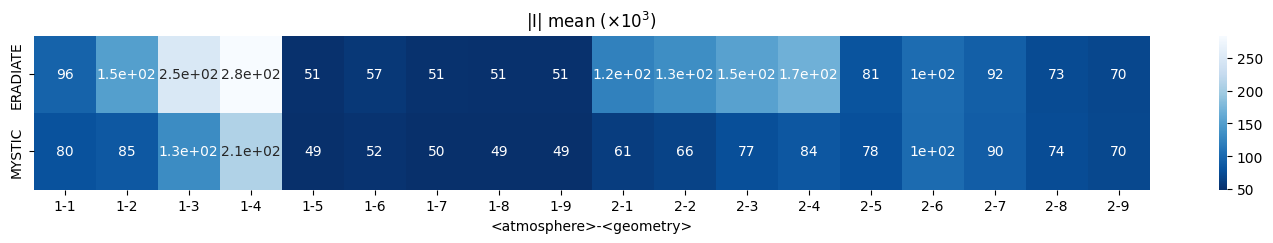

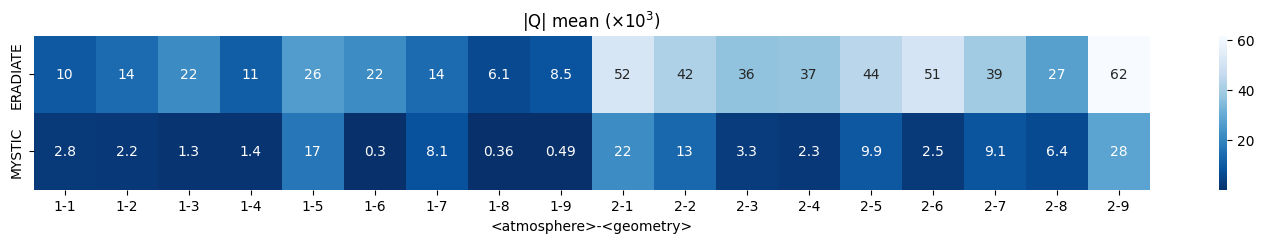

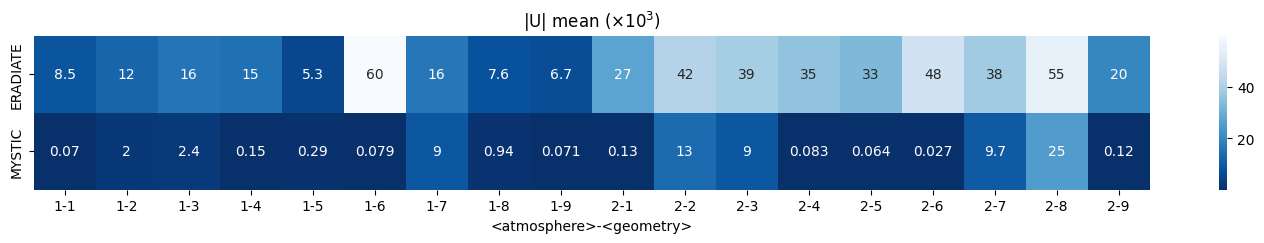

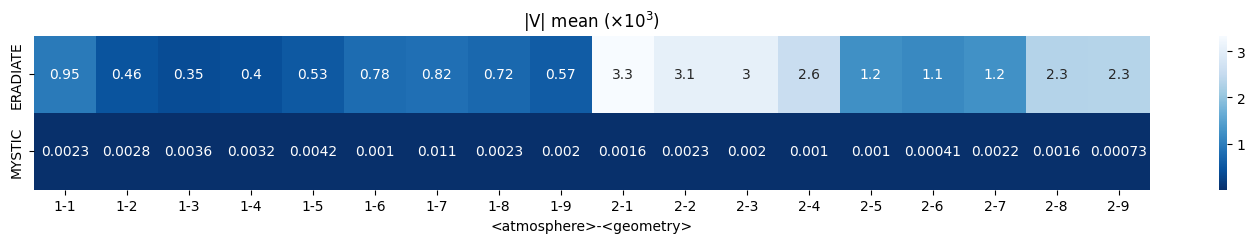

In [214]:
import seaborn as sns

for cmp in ["I", *polcmps]:
    imean_mystic = mystic_df[cmp].T * 1e3
    imean_mystic = imean_mystic.where(imean_mystic != 0)
    imean_mystic.index = case_index
    imean_mystic = imean_mystic.T.abs().mean().rename("MYSTIC")
    imean_erd = erd_df[cmp].T * 1e3
    imean_erd = imean_erd.where(imean_erd != 0)
    imean_erd.index = case_index
    imean_erd = imean_erd.T.abs().mean().rename("ERADIATE")

    plt.figure(figsize=(18, 2))
    sns.heatmap(
        pd.concat([imean_erd, imean_mystic], axis=1).T, cmap="Blues_r", annot=True
    )
    plt.title(f"|{cmp}| mean ($\\times 10^3$)")
    plt.show()
    plt.close()

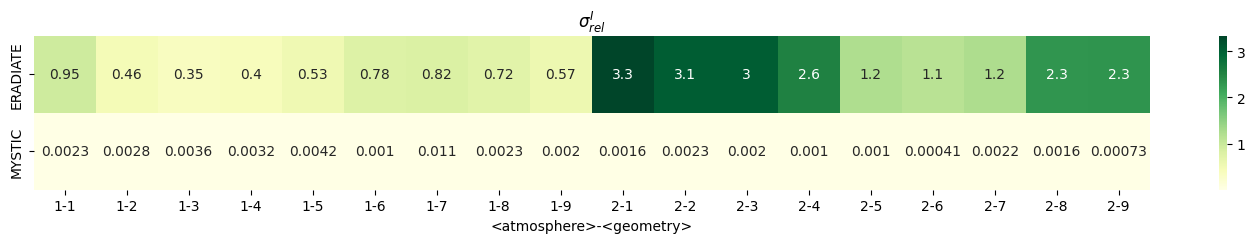

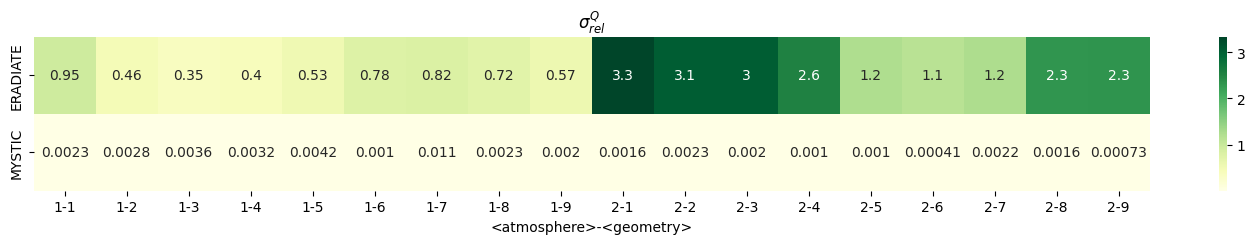

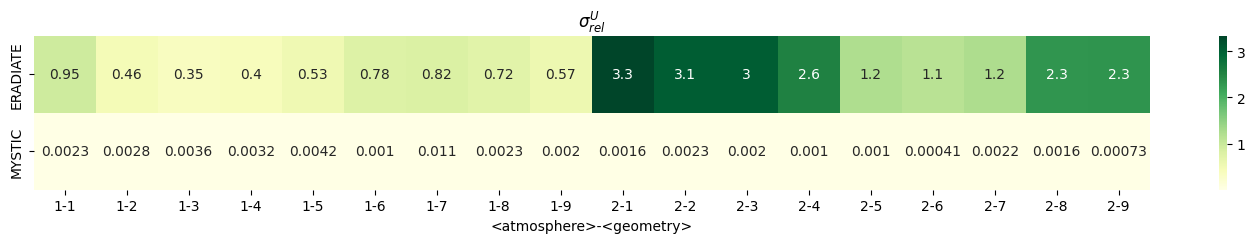

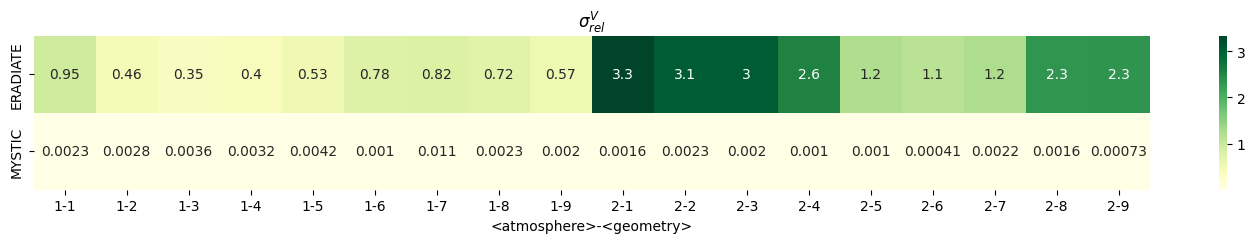

In [90]:
for cmp in ["I", *polcmps]:
    std_mystic = mystic_df[cmp].T
    std_mystic.index = case_index
    std_mystic = std_mystic.where(std_mystic != 0)
    std_mystic = std_mystic.T.std().rename("MYSTIC") / std_mystic.T.mean().values * 100
    std_erd = erd_df[cmp].T
    std_erd.index = case_index
    std_erd = std_erd.where(std_erd != 0)
    std_erd = std_erd.T.std().rename("ERADIATE") / std_erd.T.mean().values * 100

    plt.figure(figsize=(18, 2))
    sns.heatmap(pd.concat([imean_erd, imean_mystic], axis=1).T, cmap="YlGn", annot=True)
    plt.title(f"$\\sigma_{{rel}}^{cmp}$")
    plt.show()
    plt.close()

In [91]:
def rmse(v1, v2):
    v1 = v1[v2 != 0]
    v2 = v2[v2 != 0]
    return np.sqrt(np.mean((v1 - v2) ** 2)) / v2.mean() * 100

In [92]:
def corr_metric(df1, df2, scmp, method="pearson"):
    return (
        df1[scmp]
        .T.reset_index()
        .T.corrwith(df2[scmp].T.reset_index().T, method=method)
        .to_frame()
        .set_index(df2[scmp].T.index)[0]
        .rename(scmp)
    )

In [93]:
def rbias(v1, v2):
    v1 = v1[v2 != 0]
    v2 = v2[v2 != 0]
    return ((v1 - v2) / v2 * 100).mean()

<Axes: ylabel='<atmosphere>-<geometry>'>

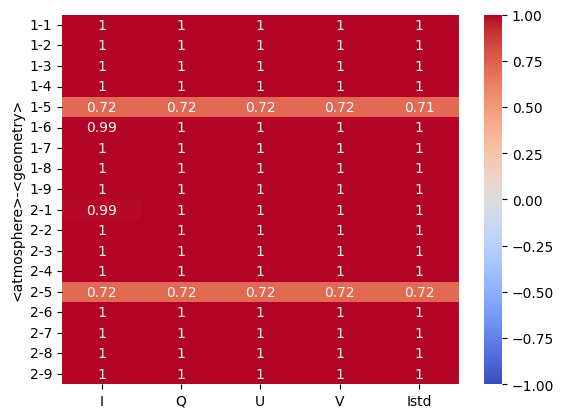

In [94]:
cor = pd.concat(
    [corr_metric(erd_df, mystic_df, scmp) for scmp in ["I", "Q", "U", "V", "Istd"]],
    axis=1,
).reset_index(drop=True)
cor.index = case_index
sns.heatmap(cor, cmap="coolwarm", vmin=-1, vmax=1, annot=True)

Text(0.5, 1.0, 'Relative RMSE')

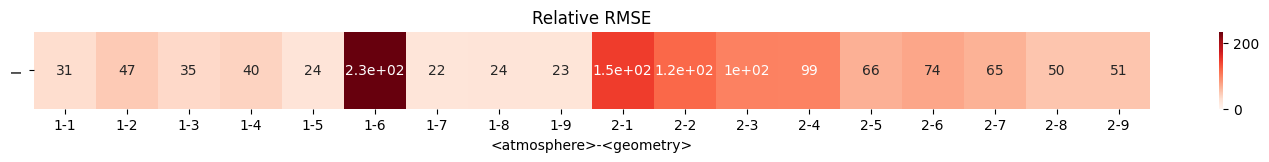

In [95]:
cmps_r_rmse = ["I"]
plt.figure(figsize=(18, len(cmps_r_rmse)))
drmse = pd.concat(
    [
        corr_metric(erd_df, mystic_df, scmp, method=rmse)
        for scmp in cmps_r_rmse
    ],
    axis=1,
).reset_index(drop=True)
drmse.index = case_index
sns.heatmap(drmse.T, cmap="Reds", vmin=0, annot=True)
plt.title("Relative RMSE")

<Axes: xlabel='<atmosphere>-<geometry>'>

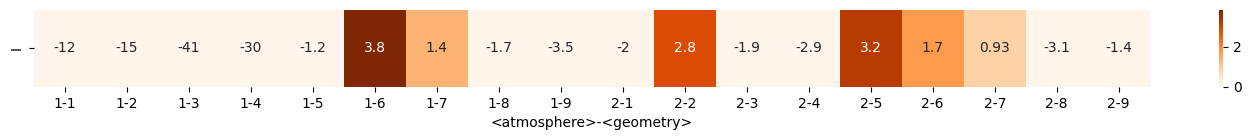

In [96]:
plt.figure(figsize=(18, 1))
bias = pd.concat(
    [
        corr_metric(erd_df, mystic_df, scmp, method=rbias)
        for scmp in ["I", "Q", "U", "V"]
    ],
    axis=1,
).reset_index(drop=True)
bias.index = case_index
sns.heatmap(bias[["I"]].T, cmap="Oranges", vmin=0, annot=True)


<Axes: xlabel='<atmosphere>-<geometry>'>

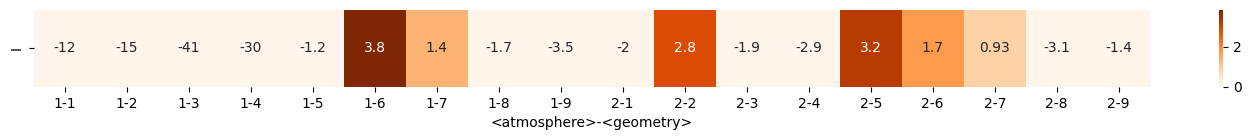

In [97]:
plt.figure(figsize=(18, 1))
bias = pd.concat(
    [
        corr_metric(erd_df, mystic_df, scmp, method=rbias)
        for scmp in ["I", "Q", "U", "V"]
    ],
    axis=1,
).reset_index(drop=True)
bias.index = case_index
sns.heatmap(bias[["I"]].T, cmap="Oranges", vmin=0, annot=True)

In [98]:
sel_c2_2_5 = (2.0, 40.0, 5.0, 180.0)
mystic_c2_2_5 = mystic_df.I[sel_c2_2_5].values.reshape(70, 70)
erd_c2_2_5 = erd_df.I[sel_c2_2_5].values.reshape(70, 70)

/tmp/ipykernel_3276668/2999720329.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  mystic_c2_2_5 = mystic_df.I[sel_c2_2_5].values.reshape(70, 70)
/tmp/ipykernel_3276668/2999720329.py:3: PerformanceWarning: indexing past lexsort depth may impact performance.
  erd_c2_2_5 = erd_df.I[sel_c2_2_5].values.reshape(70, 70)


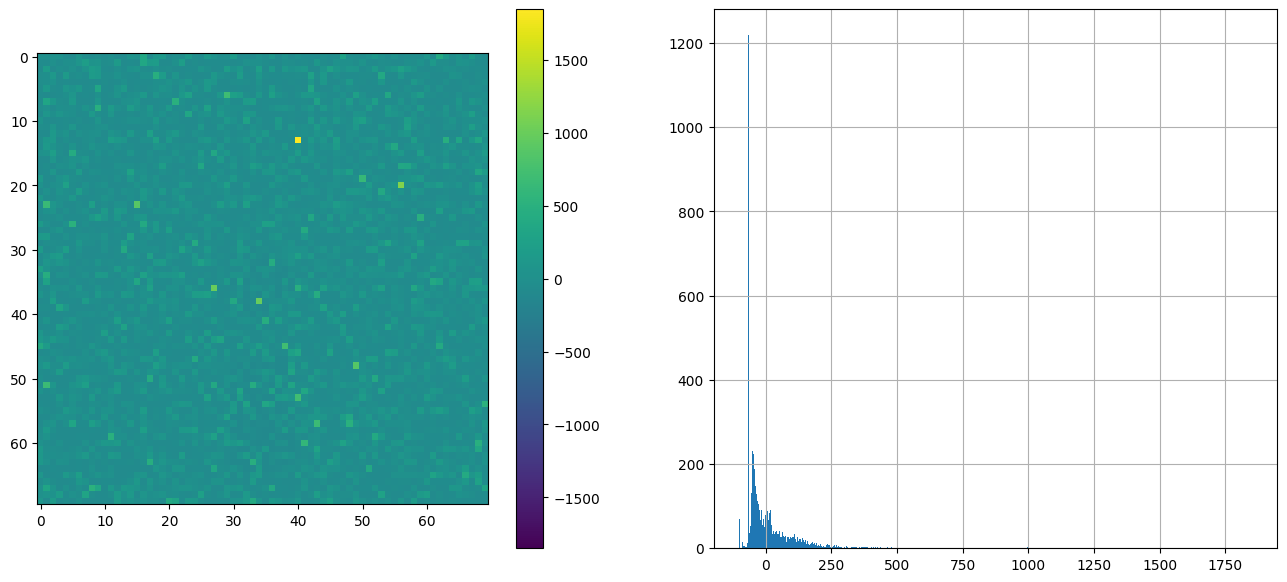

In [99]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

b = (erd_c2_2_5 - mystic_c2_2_5) / mystic_c2_2_5 * 100
m = np.abs(b).max()
plt.colorbar(ax1.imshow(b, vmin=-m, vmax=m))

_ = ax2.hist(b.ravel(), bins=500)
plt.grid()

In [100]:
mystic_df.I[(2.0,20.0)]

z             0.0                              
theta        40.0                              
phi         0.0       60.0      120.0     180.0
i_x i_y                                        
1   1    0.059287  0.063351  0.073502  0.079551
    2    0.059298  0.063323  0.073434  0.079478
    3    0.059315  0.063353  0.073471  0.079589
    4    0.059324  0.063314  0.073512  0.079543
    5    0.059254  0.063346  0.073473  0.079555
...           ...       ...       ...       ...
70  66   0.059304  0.063303  0.073458  0.079589
    67   0.059324  0.063301  0.073464  0.079557
    68   0.059282  0.063315  0.073458  0.079545
    69   0.059298  0.063281  0.073496  0.079535
    70   0.059297  0.063327  0.073489  0.079578

[4900 rows x 4 columns]

In [101]:
sel_c2_2_1 = (2.0,20.0,0.0, 40.0, 0.0)
mystic_c2_2_1 = mystic_df.I[sel_c2_2_1].values.reshape(70, 70).T
erd_c2_2_1 = erd_df.I[sel_c2_2_1].values.reshape(70, 70).T


(
    array([2.54e+03, 1.76e+02, 5.48e+02, 4.60e+02, 3.98e+02, 2.45e+02,
       1.64e+02, 1.07e+02, 8.00e+01, 4.80e+01, 3.00e+01, 3.30e+01,
       1.50e+01, 1.30e+01, 8.00e+00, 6.00e+00, 3.00e+00, 3.00e+00,
       7.00e+00, 5.00e+00, 0.00e+00, 2.00e+00, 2.00e+00, 0.00e+00,
       0.00e+00, 3.00e+00, 0.00e+00, 1.00e+00, 1.00e+00, 0.00e+00,
       0.00e+00, 0.00e+00, 1.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
       0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
       0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
       0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
       0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
       0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
       0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
       0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00, 0.00e+00,
       0.00e+00, 1.00e+00]),
    array([-100.        ,  -57.759207  ,  -15.518414  ,   26.722379  ,
         68.963172  , 

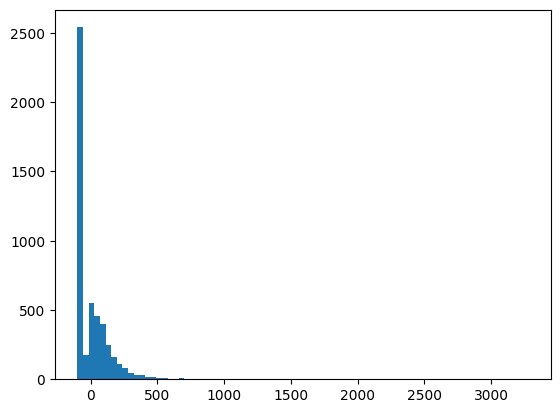

In [102]:
plt.hist(((erd_c2_2_1 - mystic_c2_2_1) / mystic_c2_2_1 *100).ravel(), bins=80)

## V. A proper cloud interface

Using particle layers to fill Eradiate extinction coefficient grids is feasible, but lacks proper support for intrinsic cloud properties. It lets users handle important pre-processing steps at the core of the scope of Eradiate and this is not sufficient. Spatially varying phase functions due to cloud particles effective radius and effective radius variance interpolation would also lack support.

### 1. Loading, preprocessing

Source cloud properties can be defined as follows:
 - a cloud profile, composed of gamma distribution parameters R_eff (effective radius) and V_eff (effective variance) define on the atmospheric grid spatial extent.
 - a cloud presence metric, defined by the LWC.
 - cloud material properties, depending on the observed species (water).

From IPRT case C3:

In [122]:
from eradiate.spectral import DeltaSRF
import numpy as np
from eradiate.units import unit_registry as ureg
import xarray as xr
import matplotlib.pyplot as plt
import eradiate
eradiate.set_mode("mono_polarized_double")
import attrs
from eradiate.scenes.measure import MultiPixelDistantMeasure
from eradiate.scenes.atmosphere import HeterogeneousAtmosphere
from eradiate.contexts import KernelContext
from eradiate.spectral import MonoSpectralIndex
import mitsuba as mi
import drjit as dr
import pandas as pd

In [123]:
mie_ws = xr.load_dataset("test_3d_clouds/watercloud_670.mie.cdf")
mie_ws

<xarray.Dataset> Size: 1MB
Dimensions:  (nlam: 1, nreff: 25, nphamat: 4, nthetamax: 1000, nmommax: 1000)
Dimensions without coordinates: nlam, nreff, nphamat, nthetamax, nmommax
Data variables:
    wavelen  (nlam) float64 8B 0.67
    reff     (nreff) float64 200B 1.0 2.0 3.0 4.0 5.0 ... 22.0 23.0 24.0 25.0
    ntheta   (nlam, nreff, nphamat) int32 400B 164 164 164 ... 1000 1000 1000
    theta    (nlam, nreff, nphamat, nthetamax) float32 400kB 180.0 179.9 ... 0.0
    phase    (nlam, nreff, nphamat, nthetamax) float32 400kB 0.243 ... -0.04677
    nmom     (nlam, nreff, nphamat) int32 400B 1000 1000 1000 ... 1000 1000 1000
    pmom     (nlam, nreff, nphamat, nmommax) float32 400kB 1.0 ... 0.0006352
    ext      (nlam, nreff) float64 200B 2.092e+03 868.0 559.7 ... 64.28 61.66
    ssa      (nlam, nreff) float64 200B 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    refre    (nlam) float64 8B 1.33
    refim    (nlam) float64 8B 2.1e-08
    rho      (nlam, nreff) float64 200B 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
Attributes:
    file_info:         Netcdf file created using libRadtran-Mie-tool
    version:           20110916
    complete_moments:  0
    parameterization:  mie
    size_distr:        Gamma distribution.
    param_alpha:       7.0
    n_r_max:           5.0
    dx_max:            0.003000000026077032

The provided format is a ragged array of phase function defined on incompatible irregular angular grids. Preprocessing in this situation must be handled with care to avoid:
 - unnecessary padding (the data is large enough)
 - excessive grid stitching, leading to much more memory usage
 - unvectorized implementation of the interpolation
 - approximations
 - aliazing when mapping the interpolated properties onto a regular spatial grid.

The proposed solution develops an intermediate polarized phase function dataset format, contiguous in memory with a sparse representation. Each phase is thus defined on its own minimal grid, minimizing memory costs. The implementation is reasonably optimized to allow subsecond evaluation of the C3 set of phase functions. The contiguous nature facilitates loading of the data and avoid unnecessary copies of complex structures, all the while limiting fragmentation. 

It's not perfect though, this approach still consumes a large amount of memory. It could be optimized to provide a specific variant for spherical and spheroidal shapes. The tradeoff of interpolating against R_eff and V_eff at integration time in Mitsuba has not been evaluated. An attempt was made to use legendre space interpolation, leading to excessive time being spent in coefficients evaluation.

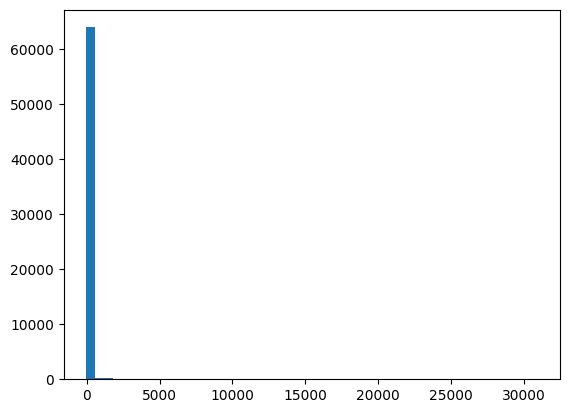

In [124]:
phase_da = mie_ws.phase
_ = plt.hist(phase_da.values.ravel(), bins=50)

For the general case in Eradiate we need to encode the 16 Mueller matrix components, even though it is not necessary for the spherical particles of the case C3. Phase function backscattering peaks can reach very high values > 30k, this breaks the physicality of the scene. In practice the peak is never directly sampled at a scattering angle of 0°, unless we build an artificial scene to do this (directional irradiance and directional observation exactly at the backscattering position). 

In [125]:
from eradiate.scenes.atmosphere import format_particles_dataset

# Only 1 v_eff value is used in this dataset, equal to 1/9.
wc_ds = format_particles_dataset(mie_ws, [1 / 9])
wc_ds

<xarray.Dataset> Size: 2MB
Dimensions:       (total_pts: 16283, ch16: 16, w: 1, r_eff: 25, v_eff: 1)
Coordinates:
  * w             (w) float64 8B 0.67
  * r_eff         (r_eff) float64 200B 1.0 2.0 3.0 4.0 ... 22.0 23.0 24.0 25.0
  * v_eff         (v_eff) float64 8B 0.1111
    rho           float64 8B 1.0
    alpha         (v_eff) float64 8B 7.0
Dimensions without coordinates: total_pts, ch16
Data variables:
    theta_native  (total_pts) float64 130kB 180.0 179.9 179.7 ... 0.3 0.2 0.0
    phase_native  (total_pts, ch16) float64 2MB 0.243 -1.221e-06 ... 3.089e+04
    start         (w, r_eff, v_eff) int64 200B 0 164 410 ... 13283 14283 15283
    n_pts         (w, r_eff, v_eff) int32 100B 164 246 291 ... 1000 1000 1000
    m_extinction  (w, r_eff, v_eff) float64 200B 2.092e+03 868.0 ... 64.28 61.66
    albedo        (w, r_eff, v_eff) float64 200B 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
Attributes:
    file_info:         Netcdf file created using libRadtran-Mie-tool
    version:           20110916
    complete_moments:  0
    parameterization:  mie
    size_distr:        Gamma distribution.
    param_alpha:       7.0
    n_r_max:           5.0
    dx_max:            0.003000000026077032

The proposed solution uses a single index for the entire dataset of phase function points (total_pts). The data variables start and n_pts provide the necessary segmentation points of this large array. This representation avoid padding in the data and provides constant access to any specific phase function. However, this is still not interpolated against a specific set of cloud physical properties (r_eff, v_eff) or observation wavelength.

In [126]:
def load_extinction_profile(cumulus_path, w, v_eff=1 / 9):
    
    """
    Read the cumulus .dat file and return cumulus_profile (xr.Dataset).
    This function support IPRT extinction profiles
    """
    
    import pandas as pd

    df = pd.DataFrame(
        data=np.loadtxt(cumulus_path, skiprows=3),
        columns=["i_x", "i_y", "i_z", "extinction", "r_eff"],
    )
    df[["i_x", "i_y", "i_z"]] = df[["i_x", "i_y", "i_z"]].astype(int) - 1
    n_x, n_y, n_z = np.loadtxt(cumulus_path, skiprows=1, max_rows=1, usecols=(0, 1, 2))
    x_r, y_r = np.loadtxt(cumulus_path, skiprows=2, max_rows=1, usecols=(0, 1))
    z_levels = np.loadtxt(cumulus_path, skiprows=2, max_rows=1)[2:]
    df["v_eff"] = float(v_eff)
    ext = df.extinction
    df = df.drop("extinction", axis=1)
    ds1 = df.to_xarray()

    ds2 = xr.Dataset(
        coords=dict(
            x=(["x"], np.arange(0, n_x + 1, 1, dtype=int)),
            y=(["y"], np.arange(0, n_y + 1, 1, dtype=int)),
            z=(["z"], np.arange(0, n_z + 1, 1, dtype=int)),
        ),
        data_vars=dict(
            x_levels=(
                ["x"],
                np.arange(0, x_r * n_x * 1.01, x_r),
                dict(units="km"),
            ),
            y_levels=(
                ["y"],
                np.arange(0, y_r * n_y * 1.01, y_r),
                dict(units="km"),
            ),
            z_levels=(["z"], z_levels, dict(units="km")),
        ),
    )

    ext.index.name = "index"
    ext = ext.to_frame()
    ext["w"] = w.m_as("nm")
    ext = ext.set_index("w", append=True)
    ds3 = ext.to_xarray()

    ds = xr.merge(
        [
            ds1,
            ds2,
            ds3,
        ]
    )
   
    ds.w.attrs["units"] = "nanometer"
    ds.extinction.attrs["units"] = "1/kilometer"
    ds.r_eff.attrs["units"] = "micron"
    ds.v_eff.attrs["units"] = "micron ** 2"

    return ds

In [127]:
cu_profile = load_extinction_profile("test_3d_clouds/cumulus.dat", 670 * ureg.nm)

In [128]:
cu_profile

<xarray.Dataset> Size: 1MB
Dimensions:     (index: 20435, x: 101, y: 101, z: 54, w: 1)
Coordinates:
  * index       (index) int64 163kB 0 1 2 3 4 ... 20430 20431 20432 20433 20434
  * x           (x) int64 808B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99 100
  * y           (y) int64 808B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99 100
  * z           (z) int64 432B 0 1 2 3 4 5 6 7 8 ... 45 46 47 48 49 50 51 52 53
  * w           (w) int64 8B 670
Data variables:
    i_x         (index) int64 163kB 0 0 0 0 0 0 0 0 ... 99 99 99 99 99 99 99 99
    i_y         (index) int64 163kB 1 1 1 1 1 1 1 2 ... 98 98 98 99 99 99 99 99
    i_z         (index) int64 163kB 15 16 17 18 19 20 21 ... 23 18 19 20 21 22
    r_eff       (index) float64 163kB 7.05 8.11 8.65 8.7 ... 7.04 8.81 9.79 9.6
    v_eff       (index) float64 163kB 0.1111 0.1111 0.1111 ... 0.1111 0.1111
    x_levels    (x) float64 808B 0.0 0.0667 0.1334 0.2001 ... 6.537 6.603 6.67
    y_levels    (y) float64 808B 0.0 0.0667 0.1334 0.2001 ... 6.537 6.603 6.67
    z_levels    (z) float64 432B 0.0 0.2 0.4 0.6 0.8 ... 15.0 20.0 25.0 30.0
    extinction  (index, w) float64 163kB 47.89 63.11 71.67 ... 74.34 91.24 87.95

Here we provide the following profile loading/formatting function, but do not include it in the delivery. This is a proposal format for this profile, and it may be documented. Just like the phase function properties, it is indexed on a single variable to take advantage of sparsity. Besides, this dataset doesn't really need an inverse index to retrieve the properties of a grid cell from its position, all grid cells are always treated sequentially in order of memory position. This also means that preprocessing of the dataset to order the cells by r_eff and v_eff can improve interpolation performances. This latter optimization is not implemented.

### 2. Compute Profile LWC

IPRT C3 cumulus profile provides the extinction coefficent of the cloud component directly. In all due correctness this profile should contain LWC to be used to recompute the extinction from the cloud properties mass extinction and species volumic mass. In this section we thus calculate LWC to be included in the profile and later used by the CloudField

In [129]:
def extend_profile_lwc(profile, properties, method="linear"):

    r_eff = profile.r_eff
    v_eff = profile.v_eff
    mass_ext = properties.m_extinction.interp(r_eff=r_eff, v_eff=v_eff, method=method)
    mass_ext = mass_ext.assign_coords(
        w=eradiate.units.to_quantity(mass_ext.w).m_as(profile.w.units)
    )
    mass_density = eradiate.units.to_quantity(profile.extinction).T / eradiate.units.to_quantity(mass_ext)
    assert np.allclose(np.abs(mass_density.m - mass_density.m[0]), 0.0)
    
    profile_extended = profile.copy()
    u = str(mass_density.units)
    profile_extended["mass_density"] = (["index"], mass_density.m_as(u)[0])
    profile_extended["mass_density"].attrs["units"] = str(u)

    return profile_extended

cu_profile_lwc = extend_profile_lwc(cu_profile, wc_ds)

In [130]:
cu_profile_lwc

<xarray.Dataset> Size: 1MB
Dimensions:       (index: 20435, x: 101, y: 101, z: 54, w: 1)
Coordinates:
  * index         (index) int64 163kB 0 1 2 3 4 ... 20431 20432 20433 20434
  * x             (x) int64 808B 0 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
  * y             (y) int64 808B 0 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
  * z             (z) int64 432B 0 1 2 3 4 5 6 7 8 ... 46 47 48 49 50 51 52 53
  * w             (w) int64 8B 670
Data variables:
    i_x           (index) int64 163kB 0 0 0 0 0 0 0 0 ... 99 99 99 99 99 99 99
    i_y           (index) int64 163kB 1 1 1 1 1 1 1 2 ... 98 98 99 99 99 99 99
    i_z           (index) int64 163kB 15 16 17 18 19 20 21 ... 23 18 19 20 21 22
    r_eff         (index) float64 163kB 7.05 8.11 8.65 8.7 ... 8.81 9.79 9.6
    v_eff         (index) float64 163kB 0.1111 0.1111 0.1111 ... 0.1111 0.1111
    x_levels      (x) float64 808B 0.0 0.0667 0.1334 0.2001 ... 6.537 6.603 6.67
    y_levels      (y) float64 808B 0.0 0.0667 0.1334 0.2001 ... 6.537 6.603 6.67
    z_levels      (z) float64 432B 0.0 0.2 0.4 0.6 0.8 ... 15.0 20.0 25.0 30.0
    extinction    (index, w) float64 163kB 47.89 63.11 71.67 ... 91.24 87.95
    mass_density  (index) float64 163kB 0.2111 0.3217 0.3898 ... 0.5648 0.5331

This would be the definitive profile format.

### 3. Configuring a cloud field

In [131]:
import eradiate.scenes.atmosphere
from eradiate.scenes.atmosphere import ParticleField

We need a few bits of setup:

In [132]:
from eradiate.units import unit_registry as ureg

w = np.array([0.670]) * ureg.micron

In [221]:
cfield = ParticleField(
    profile=cu_profile_lwc,
    properties=mie_ws,
)

In [222]:
cfield = cfield.to_profile_regular_grid()  # inefficient sampling
cfield.geometry.grid.shape

(100, 100, 1500)

In [223]:
cfield._interpolate_properties(w, cfield.geometry.grid)

<xarray.Dataset> Size: 2MB
Dimensions:       (total_pts: 16283, ch16: 16, w: 1, r_eff: 25, v_eff: 1)
Coordinates:
  * w             (w) float64 8B 0.67
  * r_eff         (r_eff) float64 200B 1.0 2.0 3.0 4.0 ... 22.0 23.0 24.0 25.0
  * v_eff         (v_eff) float64 8B 0.1111
    rho           float64 8B 1.0
    alpha         (v_eff) float64 8B 7.0
Dimensions without coordinates: total_pts, ch16
Data variables:
    theta_native  (total_pts) float64 130kB 180.0 179.9 179.7 ... 0.3 0.2 0.0
    phase_native  (total_pts, ch16) float64 2MB 0.243 -1.221e-06 ... 3.089e+04
    start         (w, r_eff, v_eff) int64 200B 0 164 410 ... 13283 14283 15283
    n_pts         (w, r_eff, v_eff) int32 100B 164 246 291 ... 1000 1000 1000
    m_extinction  (w, r_eff, v_eff) float64 200B 2.092e+03 868.0 ... 64.28 61.66
    albedo        (w, r_eff, v_eff) float64 200B 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
Attributes:
    file_info:         Netcdf file created using libRadtran-Mie-tool
    version:           20110916
    complete_moments:  0
    parameterization:  mie
    size_distr:        Gamma distribution.
    param_alpha:       7.0
    n_r_max:           5.0
    dx_max:            0.003000000026077032

In [224]:
sigma_t = cfield.eval_sigma_t(MonoSpectralIndex(w[0]))

In [225]:
s1 = sigma_t.ravel()[sigma_t.ravel() > 0]

Only the index is duplicated on most of the 1500 layers, not the profile values, but we still pay a price for this

In [226]:
from eradiate.scenes.geometry import WrapMode

cfield = attrs.evolve(
    cfield, geometry=attrs.evolve(cfield.geometry, wrap_mode=WrapMode.REPEAT)
)

In [227]:
type(cfield)

<class 'eradiate.scenes.atmosphere._particle_field.ParticleField'>

Just like case C2, the WrapMode allows to implement periodic boundary conditions in the atmosphere without any additional cost.

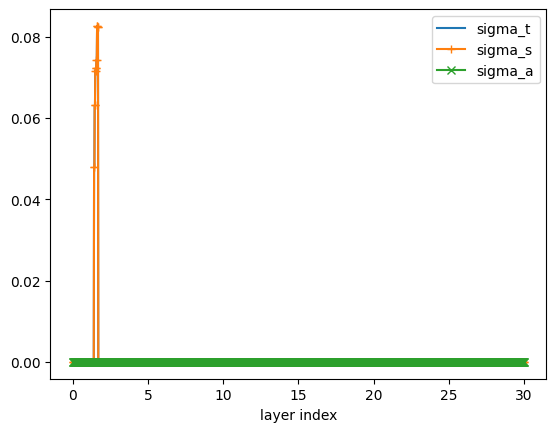

In [140]:
from eradiate.spectral import MonoSpectralIndex

si = MonoSpectralIndex(w=w.item())
sigma_t = cfield.eval_sigma_t(si).m_as("m**-1")
sigma_s = cfield.eval_sigma_s(si).m_as("m**-1")
sigma_a = cfield.eval_sigma_a(si).m_as("m**-1")
albedo = cfield.eval_albedo(si)

plt.plot(cfield.geometry.grid.layers.m, sigma_t[0, 1, :], label="sigma_t")
plt.plot(cfield.geometry.grid.layers.m, sigma_s[0, 1, :], label="sigma_s", marker="+")
plt.plot(cfield.geometry.grid.layers.m, sigma_a[0, 1, :], label="sigma_a", marker="x")
plt.xlabel("layer index")
plt.legend()

As expected, cloud absorption on an arbitrary selected column is close to zero. Scattering increases on cloud filled cells.

### 3. Test case: C3 clouds in the void, nadir obseration

Before delving into more complicated and expensive cases, a simpler one is defined. It is base on IPRT C3 at nadir observation direction (geometry 5). The molecular atmosphere and aerosols are not included. Only a single scattering event is allowed.

In [425]:
3.385* 2

6.77

In [426]:
sza = 40 * ureg.degree

target = {
    "type": "rectangle",
    "xmin": -3.335e3,
    "xmax": 3.335e3,
    "ymin": -3.335e3,
    "ymax": 3.335e3,
    "z": 0,
}

scene_config = dict(
    geometry=cfield.geometry,
    surface={
        "type": "basic",
        "shape": {"type": "rectangle", "edges": [1e12, 1e12]},
        "bsdf": {"type": "lambertian", "reflectance": 0.2},
    },
    measures=[
        MultiPixelDistantMeasure.from_angles(
            angles=(0, 0),
            target=target,
            film_resolution=[100, 100],
            srf=DeltaSRF(si.w),
            id="test_cumulus",
            ray_offset=30 * ureg.km,
            spp=1,
        ),
    ],
    illumination={
        "type": "directional",
        "irradiance": 1, #/ np.cos(sza.m_as("radian")),
        "zenith": sza,
        "azimuth": 180 * ureg.degree,
    },
    integrator={
        "type": "eovolpath",
        "moment": True,
        "stokes": True,
    },
)

In [427]:
bounds_check = AtmosphereExperiment(
    atmosphere=HeterogeneousAtmosphere(
        particle_field=cfield,
        molecular_atmosphere=None,
        particle_layers=[],
        geometry=cfield.geometry,
    ),
    **scene_config,
)
bounds_check= attrs.evolve(bounds_check, measures=[
    attrs.evolve(bounds_check.measures[0], target={
        "type": "rectangle",
        "xmin": -24.0e3,
        "xmax": 24.0e3,
        "ymin": -24.0e3,
        "ymax": 24.0e3,
        "z": 0,
    })
])

In [428]:
%%time

res_bounds = eradiate.run(bounds_check, spp=1)

CPU times: user 4min, sys: 1.28 s, total: 4min 1s
Wall time: 18.7 s


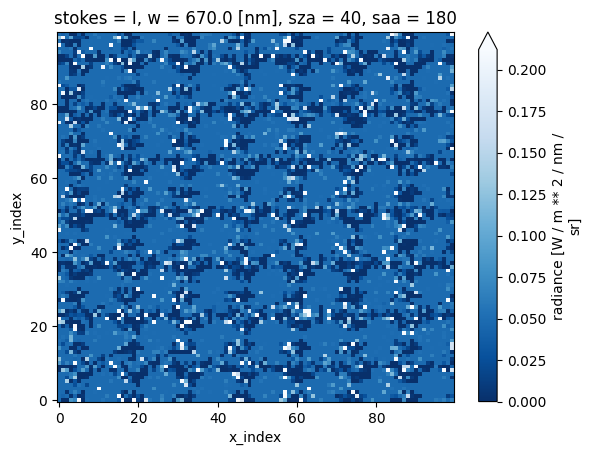

In [429]:
res_bounds.radiance.sel(stokes="I").squeeze().plot(cmap="Blues_r", robust=True)

These parameters will be reused.

In [430]:
from eradiate.experiments import AtmosphereExperiment
from eradiate.scenes.measure import MultiPixelDistantMeasure, PerspectiveCameraMeasure
from eradiate.spectral import DeltaSRF

single_scattering_experiment = AtmosphereExperiment(
    atmosphere=HeterogeneousAtmosphere(
        particle_field=cfield,
        molecular_atmosphere=None,
        particle_layers=[],
        geometry=cfield.geometry,
    ),
    **scene_config,
)
single_scattering_experiment.integrator = attrs.evolve(
    single_scattering_experiment.integrator,
    max_depth = 2,
    moment= True,
    stokes= True,
)

In [431]:
st = single_scattering_experiment.atmosphere.eval_sigma_t(si)
al = single_scattering_experiment.atmosphere.eval_albedo(si)

In [439]:
%%time

dr.set_thread_count(11)
# No extremum structure:
# ~6.4s for SPP=1
# ~20s for SPP=10
# for SPP=100

res_single_void = eradiate.run(single_scattering_experiment, spp=100)

CPU times: user 44min 28s, sys: 516 ms, total: 44min 29s
Wall time: 5min 39s


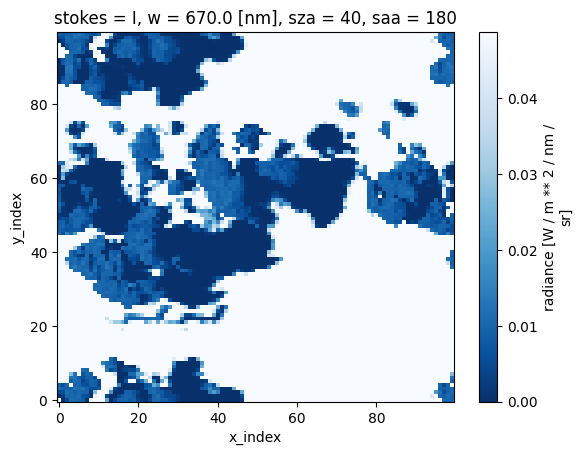

In [440]:
res_single_void.radiance.sel(stokes="I").squeeze().plot(cmap="Blues_r")

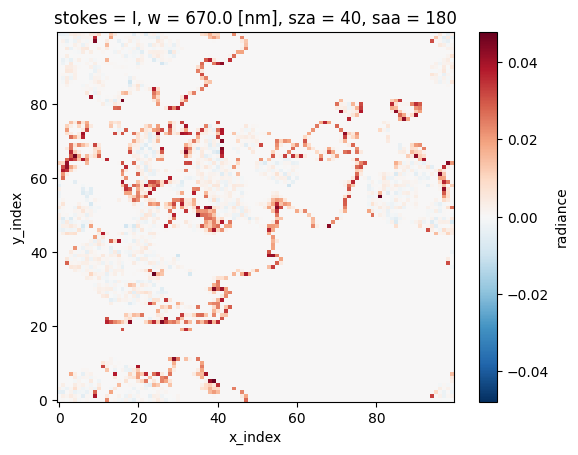

In [442]:
essds = xr.load_dataset("expert_single_scattering_spp10.nc")
essI = essds.radiance.sel(stokes="I").squeeze().values
(res_single_void.radiance.sel(stokes="I").squeeze() - essI).plot()

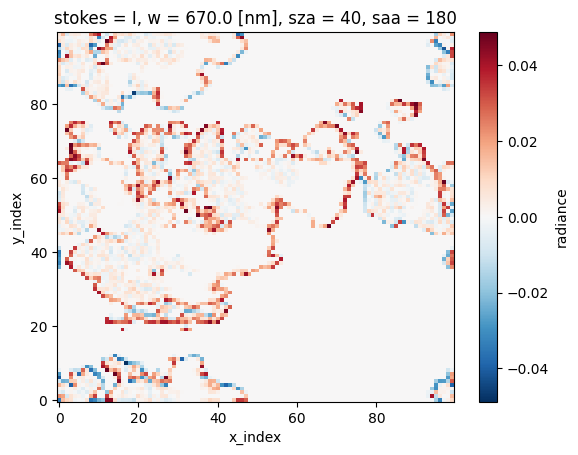

### 5. Multiple scattering vacuum case

In [216]:
vacuum_experiment = AtmosphereExperiment(
    atmosphere=HeterogeneousAtmosphere(
        particle_field=cfield,
        molecular_atmosphere=None,
        particle_layers=[],
        geometry=cfield.geometry,
    ),
    **scene_config,
)
vacuum_experiment.integrator.ddis_threshold = 0.1

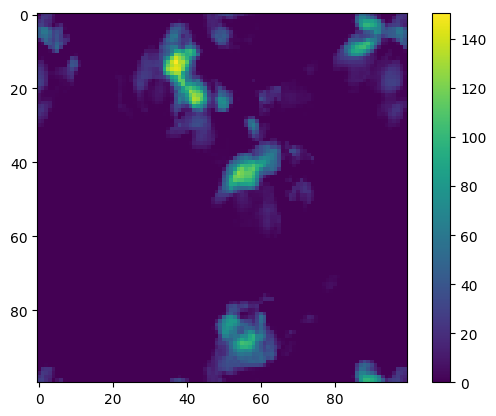

In [233]:
st = vacuum_experiment.atmosphere.eval_sigma_t(si)
ot = st * single_exp.atmosphere.geometry.grid.layer_height
ot_im = ot.sum(axis=-1)
plt.colorbar(plt.imshow(ot_im.m_as("dimensionless")))

In [230]:
from importlib import reload
import test_3d_clouds
reload(test_3d_clouds.utils)
from test_3d_clouds.utils import load_aerosol_data

ds_aer670 = load_aerosol_data("test_3d_clouds/watercloud_670.mie.cdf", "spherical", 670*ureg.nm, nreff=9)
aer670 = ParticleLayer(dataset=ds_aer670, w_ref=670 * ureg.nm)

sfield = attrs.evolve(cfield)
sfield._phase = aer670.phase
single_exp = attrs.evolve(
    vacuum_experiment,
    atmosphere = attrs.evolve(
        vacuum_experiment.atmosphere,
        particle_field = sfield
    )
)
assert sfield._phase != cfield._phase
assert cfield._phase is None

In [379]:
%%time

dr.set_thread_count(19)

# 17.2s SPP=1
# 2min 33s SPP=10
# 25min30 SPP=100
# 4h 42min 59s SPP=1000

res_vacuum2 = eradiate.run(vacuum_experiment, spp=1000)

CPU times: user 2d 15h 34min 26s, sys: 17.1 s, total: 2d 15h 34min 43s
Wall time: 4h 42min 59s


In [380]:
res_single_phase.to_netcdf("single_tabulated_vacuum_c3_spp1e3.nc")
res_vacuum2.to_netcdf("particle_phase_vacuum_c3_spp1e3.nc")

In [278]:
%%time

# 19s SPP=1
# 2min30 SPP=10
# 25min SPP=100
# 4h10min SPP=1000

res_single_phase = eradiate.run(single_exp, spp=1000)

CPU times: user 2d 17h 1min 6s, sys: 7.29 s, total: 2d 17h 1min 14s
Wall time: 4h 10min 48s


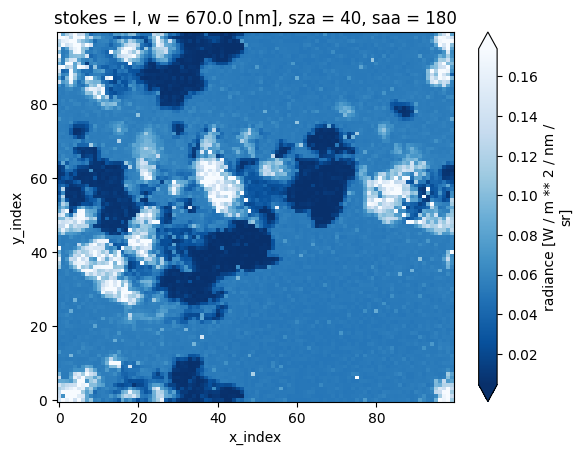

In [281]:
res_single_phase.radiance.sel(stokes="I").squeeze().plot(cmap="Blues_r", robust=True)

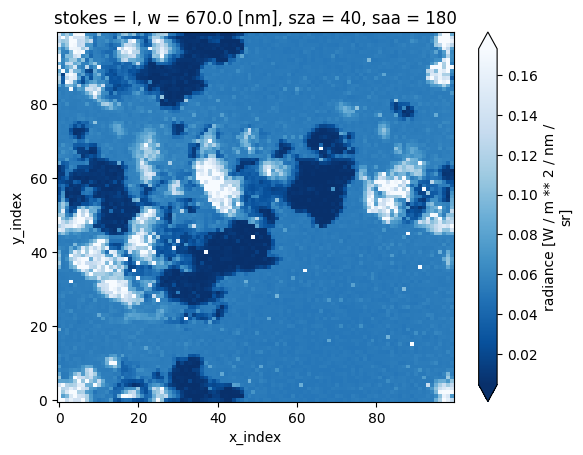

In [381]:
res_vacuum2.radiance.sel(stokes="I").squeeze().plot(cmap="Blues_r", robust=True)

In [382]:
mys_vacq = -np.load("test_3d_clouds/mystic_vacuum.npy")[:, ::-1, 1].T
mys_vacu =  np.load("test_3d_clouds/mystic_vacuum.npy")[:, ::-1, 2].T
mys_vacv =  np.load("test_3d_clouds/mystic_vacuum.npy")[:, ::-1, 3].T

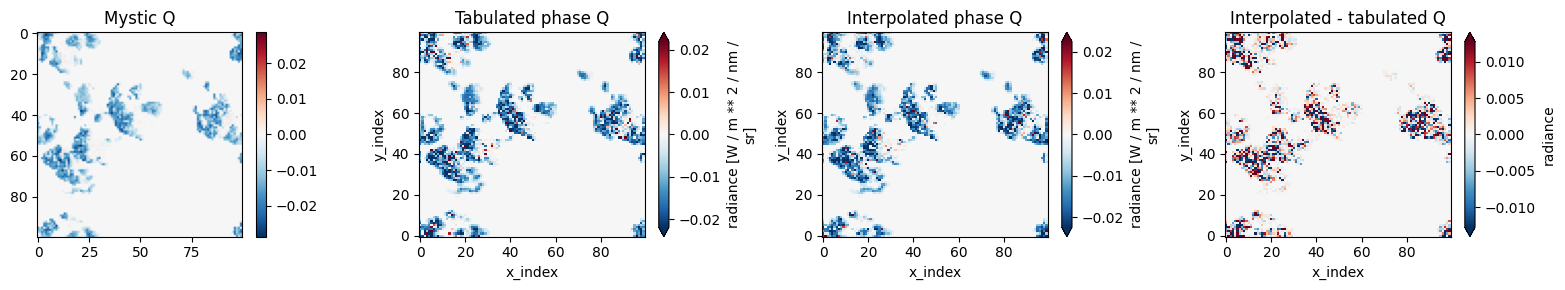

In [383]:
fig, axs = plt.subplots(1, 4, figsize=(16,3))

m = np.max(np.abs(mys_vacq))
plt.colorbar(axs[0].imshow(mys_vacq, vmin=-m, vmax=m, cmap="RdBu_r"))
axs[0].set_title("Mystic Q")

(res_single_phase.radiance.sel(stokes="Q").squeeze()).plot(cmap="RdBu_r", robust=True, ax=axs[1])
axs[1].set_title("Tabulated phase Q")

(res_vacuum2.radiance.sel(stokes="Q").squeeze()).plot(cmap="RdBu_r", robust=True, ax=axs[2])
axs[2].set_title("Interpolated phase Q")

(res_vacuum2.radiance.sel(stokes="Q") - res_single_phase.radiance.sel(stokes="Q")).squeeze().plot(cmap="RdBu_r", robust=True, ax=axs[3])
axs[3].set_title("Interpolated - tabulated Q")

plt.tight_layout()

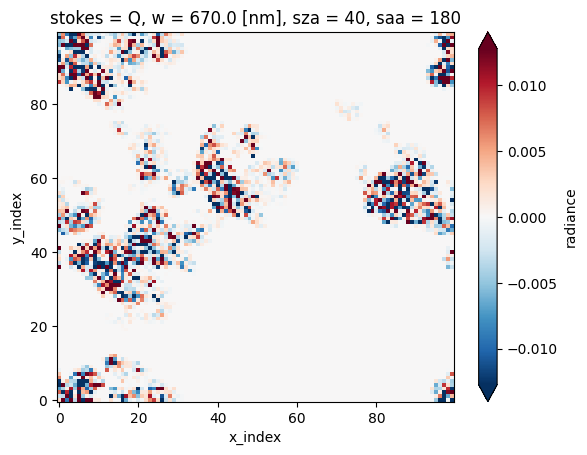

In [396]:
(res_vacuum2.radiance.sel(stokes="Q") - res_single_phase.radiance.sel(stokes="Q")).squeeze().plot(cmap="RdBu_r", robust=True)

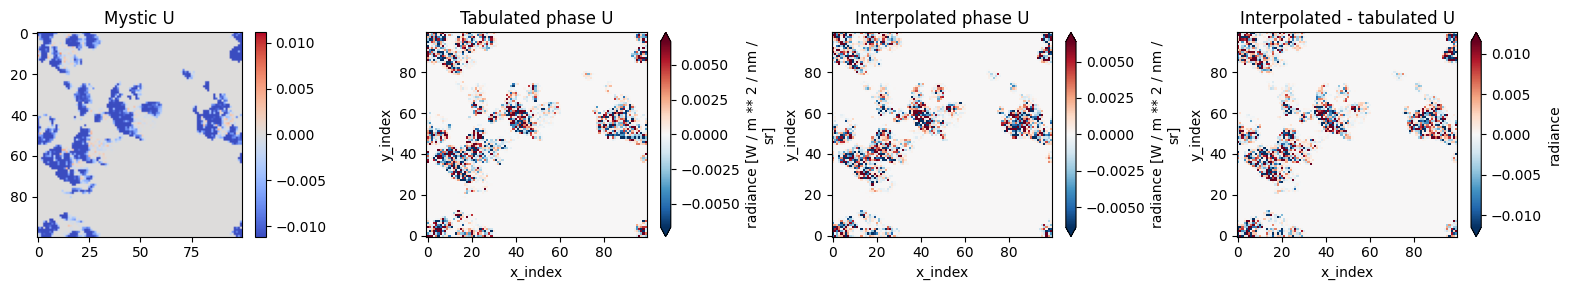

In [385]:
fig, axs = plt.subplots(1, 4, figsize=(16,3))

m = np.max(np.abs(mys_vacu))
plt.colorbar(axs[0].imshow(mys_vacq, vmin=-m, vmax=m, cmap="coolwarm"))
axs[0].set_title("Mystic U")

(res_single_phase.radiance.sel(stokes="U").squeeze()).plot(cmap="RdBu_r", robust=True, ax=axs[1])
axs[1].set_title("Tabulated phase U")

(res_vacuum2.radiance.sel(stokes="U").squeeze()).plot(cmap="RdBu_r", robust=True, ax=axs[2])
axs[2].set_title("Interpolated phase U")

(res_vacuum2.radiance.sel(stokes="U") - res_single_phase.radiance.sel(stokes="U")).squeeze().plot(cmap="RdBu_r", robust=True, ax=axs[3])
axs[3].set_title("Interpolated - tabulated U")

plt.tight_layout()

Text(0.5, 1.0, 'V')

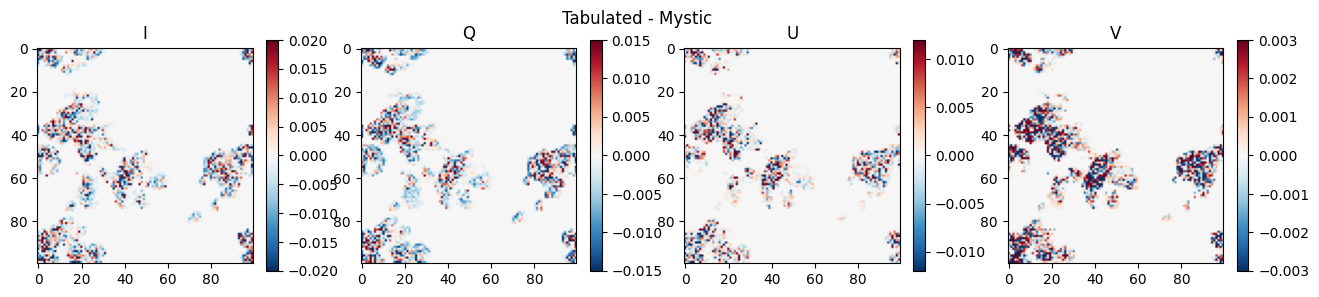

In [386]:
fig, axs = plt.subplots(1, 4, figsize=(16,3))

d0 = res_single_phase.radiance.sel(stokes="I").values.squeeze() - mys_vac[::-1, :]
m = 0.02
plt.colorbar(axs[0].imshow(d1, vmin=-m, vmax=m, cmap="RdBu_r"))

d1 = res_single_phase.radiance.sel(stokes="Q").values.squeeze() - mys_vacq[::-1, :]
m = 0.015
plt.colorbar(axs[1].imshow(d1, vmin=-m, vmax=m, cmap="RdBu_r"))

d2 = res_single_phase.radiance.sel(stokes="U").values.squeeze() - mys_vacu[::-1, :]
m = 0.012
plt.colorbar(axs[2].imshow(d2, vmin=-m, vmax=m, cmap="RdBu_r"))

d3 = res_single_phase.radiance.sel(stokes="V").values.squeeze() - mys_vacu[::-1, :]
m = 0.003
plt.colorbar(axs[3].imshow(d3, vmin=-m, vmax=m, cmap="RdBu_r"))

plt.suptitle("Tabulated - Mystic")
axs[0].set_title("I")
axs[1].set_title("Q")
axs[2].set_title("U")
axs[3].set_title("V")

Text(0.5, 1.0, 'V')

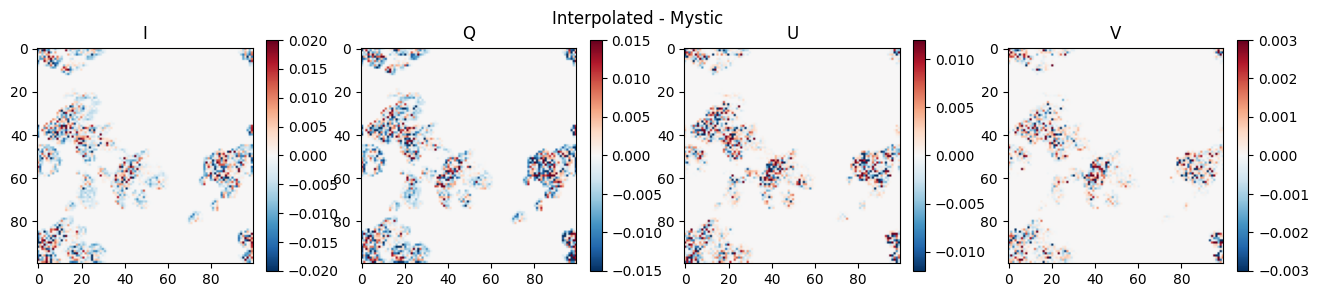

In [387]:
fig, axs = plt.subplots(1, 4, figsize=(16,3))

d0 = res_vacuum2.radiance.sel(stokes="I").values.squeeze() - mys_vac[::-1, :]
m = 0.02
plt.colorbar(axs[0].imshow(d1, vmin=-m, vmax=m, cmap="RdBu_r"))

d1 = res_vacuum2.radiance.sel(stokes="Q").values.squeeze() - mys_vacq[::-1, :]
m = 0.015
plt.colorbar(axs[1].imshow(d1, vmin=-m, vmax=m, cmap="RdBu_r"))

d2 = res_vacuum2.radiance.sel(stokes="U").values.squeeze() - mys_vacu[::-1, :]
m = 0.012
plt.colorbar(axs[2].imshow(d2, vmin=-m, vmax=m, cmap="RdBu_r"))

d3 = res_vacuum2.radiance.sel(stokes="V").values.squeeze() - mys_vacv[::-1, :]
m = 0.003
plt.colorbar(axs[3].imshow(d3, vmin=-m, vmax=m, cmap="RdBu_r"))

plt.suptitle("Interpolated - Mystic")
axs[0].set_title("I")
axs[1].set_title("Q")
axs[2].set_title("U")
axs[3].set_title("V")

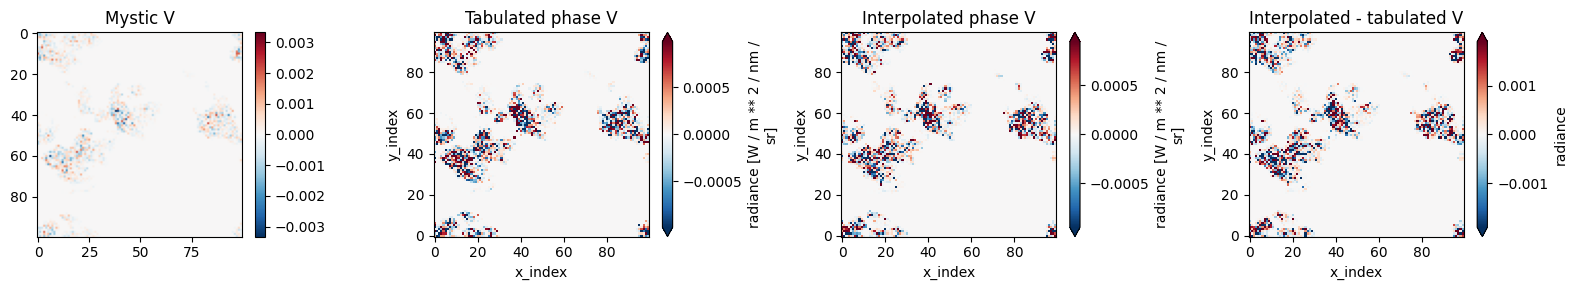

In [388]:
fig, axs = plt.subplots(1, 4, figsize=(16,3))

m = np.max(np.abs(mys_vacv))
plt.colorbar(axs[0].imshow(mys_vacv, vmin=-m, vmax=m, cmap="RdBu_r"))
axs[0].set_title("Mystic V")

(res_single_phase.radiance.sel(stokes="V").squeeze()).plot(cmap="RdBu_r", robust=True, ax=axs[1])
axs[1].set_title("Tabulated phase V")

(res_vacuum2.radiance.sel(stokes="V").squeeze()).plot(cmap="RdBu_r", robust=True, ax=axs[2])
axs[2].set_title("Interpolated phase V")

(res_vacuum2.radiance.sel(stokes="V") - res_single_phase.radiance.sel(stokes="V")).squeeze().plot(cmap="RdBu_r", robust=True, ax=axs[3])
axs[3].set_title("Interpolated - tabulated V")

plt.tight_layout()

In [389]:
mys_vac = np.load("test_3d_clouds/mystic_vacuum.npy")[:, ::-1, 0].T

Text(0.5, 1.0, 'bias(interpolated, mystic)')

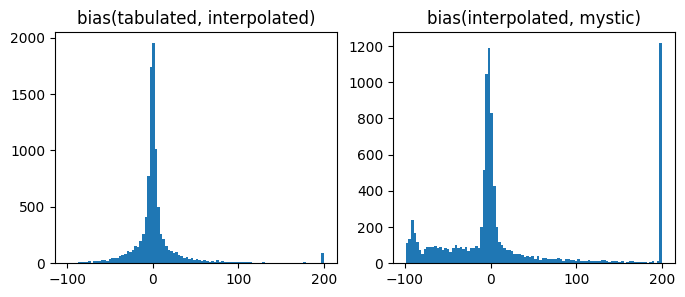

In [390]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3))

b1 = (res_single_phase.radiance.sel(stokes="I").squeeze() - res_vacuum2.radiance.sel(stokes="I").squeeze()) / res_vacuum2.radiance.sel(stokes="I").squeeze() * 100
_ =  axs[0].hist(np.clip(b1.values.ravel(), -200, 200), bins=100)
axs[0].set_title("bias(tabulated, interpolated)")

b2 = (res_vacuum2.radiance.sel(stokes="I").squeeze() - mys_vac) / mys_vac * 100
_ =  axs[1].hist(np.clip(b2.values.ravel(), -200, 200), bins=100)
axs[1].set_title("bias(interpolated, mystic)")

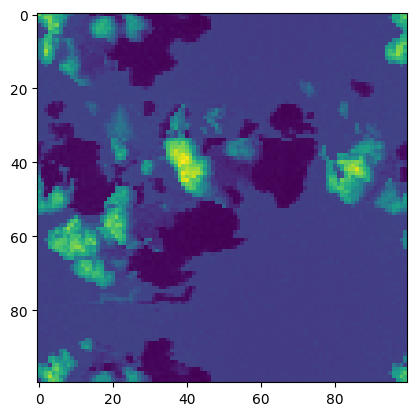

In [347]:
plt.imshow(mys_vac)

In [348]:
target

{'type': 'rectangle', 'xmin': -3385.0, 'xmax': 3385.0, 'ymin': -3385.0, 'ymax': 3385.0, 'z': 0}

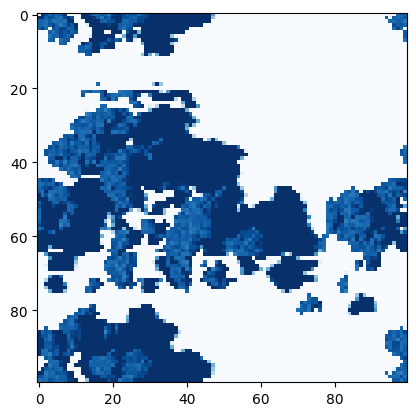

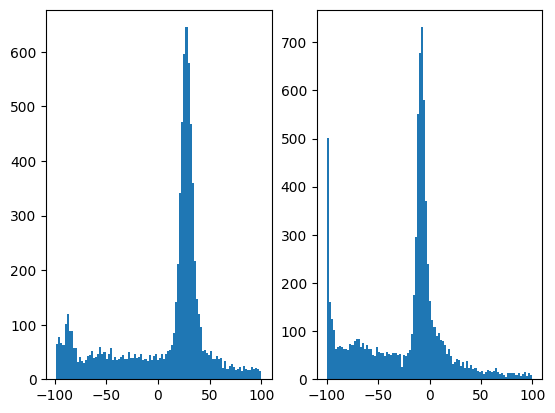

In [361]:
fig, (ax1, ax2) = plt.subplots(1, 2)

b3 = ((erd_vac - mys_vac) / mys_vac) * 100
m = np.max(np.abs(b3))
m = min(m, 100)
p3 = np.where(b3 < m, b3, np.nan)
ax1.hist(p3.ravel(), bins=100)


b4 = ((res_vacuum2.radiance.sel(stokes="I").squeeze().values - mys_vac) / mys_vac) * 100
m = np.max(np.abs(b4))
m = min(m, 100)
p4 = np.where(b4 < m, b4, np.nan)
_ = ax2.hist(p4.ravel(), bins=100)

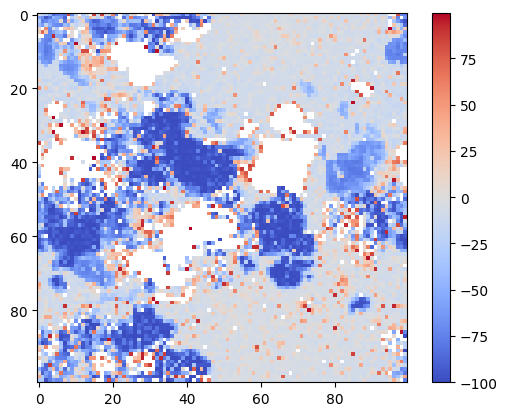

In [362]:
plt.colorbar(plt.imshow(p4, cmap="coolwarm"))

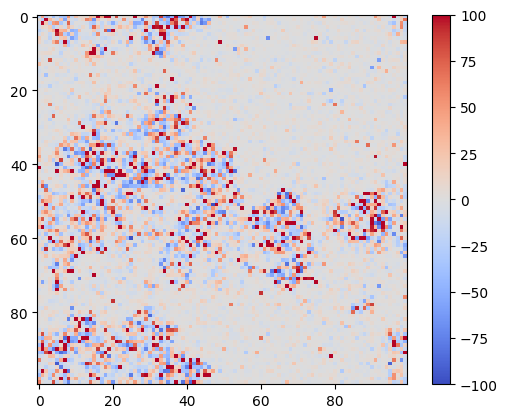

In [296]:
plt.colorbar(plt.imshow(b1, cmap="coolwarm", vmin=-m, vmax=m))

### 6. Testing the phase

#### Against C2

In [257]:
phase1 = c2_particle_layer.phase

In [258]:
pfc2 = ParticleField.from_particle_layer(
    c2_particle_layer,
    1.0 * (ureg.g / ureg.cm ** 3),
    10 * ureg.micron, 1/9
)

si8 = MonoSpectralIndex(w=800*ureg.nm)

# Quick sanity check
assert np.allclose(pfc2.eval_sigma_t(si8), c2_particle_layer.eval_sigma_t(si8), rtol=0.001)
assert np.allclose(pfc2.eval_sigma_s(si8), c2_particle_layer.eval_sigma_s(si8), rtol=0.001)
assert np.allclose(pfc2.eval_sigma_a(si8), c2_particle_layer.eval_sigma_a(si8), rtol=0.001)

In [259]:
pds = pfc2.phase.phase_data(KernelContext(si8))

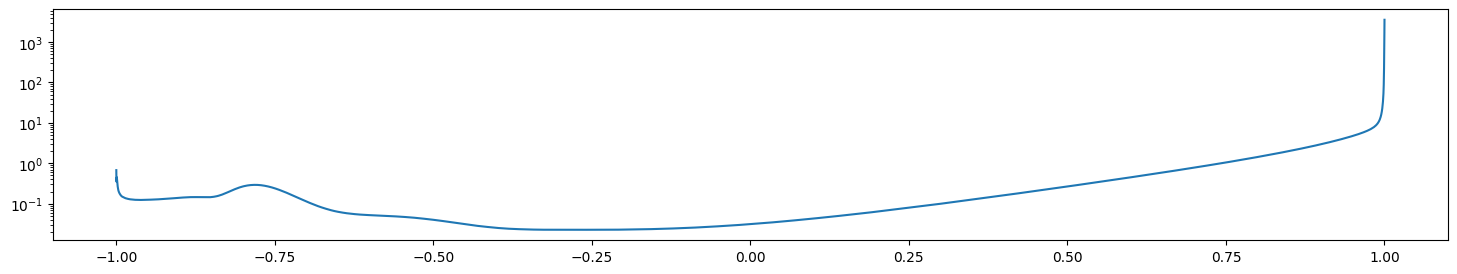

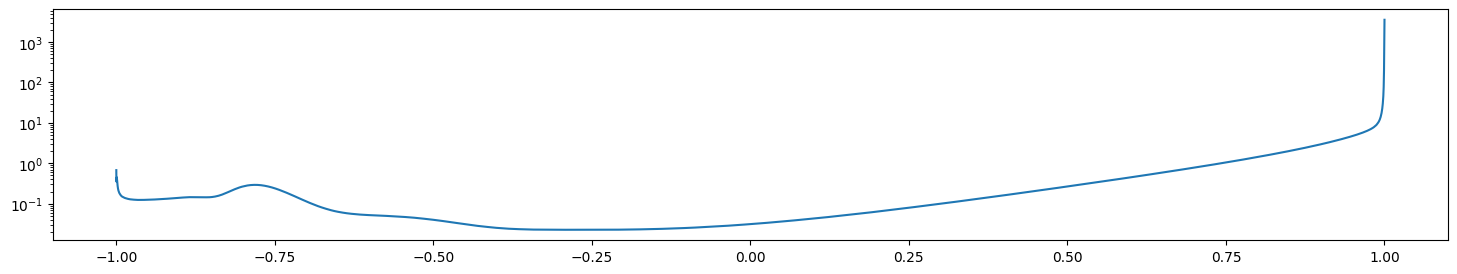

In [275]:
plt.figure(figsize=(18, 3))
plt.plot(c2_particle_layer.phase.data.mu.values, phase1.eval_mono(800*ureg.nm, 0,0))
plt.yscale("log")
plt.show()
plt.close()
plt.figure(figsize=(18, 3))
plt.plot(np.cos(np.deg2rad(pds.theta_native)), pds.phase_native.isel(ch16=0))
plt.yscale("log")

In [277]:
for i in range(4):
    for j in range(4):
        assert np.allclose(pds.phase_native.isel(ch16=i * 4 + j)[::-1], phase1.eval_mono(800*ureg.nm, i, j))

#### Against original profile

In [241]:
cfield.properties

<xarray.Dataset> Size: 1MB
Dimensions:  (nlam: 1, nreff: 25, nphamat: 4, nthetamax: 1000, nmommax: 1000)
Dimensions without coordinates: nlam, nreff, nphamat, nthetamax, nmommax
Data variables:
    wavelen  (nlam) float64 8B 0.67
    reff     (nreff) float64 200B 1.0 2.0 3.0 4.0 5.0 ... 22.0 23.0 24.0 25.0
    ntheta   (nlam, nreff, nphamat) int32 400B 164 164 164 ... 1000 1000 1000
    theta    (nlam, nreff, nphamat, nthetamax) float32 400kB 180.0 179.9 ... 0.0
    phase    (nlam, nreff, nphamat, nthetamax) float32 400kB 0.243 ... -0.04677
    nmom     (nlam, nreff, nphamat) int32 400B 1000 1000 1000 ... 1000 1000 1000
    pmom     (nlam, nreff, nphamat, nmommax) float32 400kB 1.0 ... 0.0006352
    ext      (nlam, nreff) float64 200B 2.092e+03 868.0 559.7 ... 64.28 61.66
    ssa      (nlam, nreff) float64 200B 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    refre    (nlam) float64 8B 1.33
    refim    (nlam) float64 8B 2.1e-08
    rho      (nlam, nreff) float64 200B 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
Attributes:
    file_info:         Netcdf file created using libRadtran-Mie-tool
    version:           20110916
    complete_moments:  0
    parameterization:  mie
    size_distr:        Gamma distribution.
    param_alpha:       7.0
    n_r_max:           5.0
    dx_max:            0.003000000026077032

In [282]:
cfield.properties

<xarray.Dataset> Size: 1MB
Dimensions:  (nlam: 1, nreff: 25, nphamat: 4, nthetamax: 1000, nmommax: 1000)
Dimensions without coordinates: nlam, nreff, nphamat, nthetamax, nmommax
Data variables:
    wavelen  (nlam) float64 8B 0.67
    reff     (nreff) float64 200B 1.0 2.0 3.0 4.0 5.0 ... 22.0 23.0 24.0 25.0
    ntheta   (nlam, nreff, nphamat) int32 400B 164 164 164 ... 1000 1000 1000
    theta    (nlam, nreff, nphamat, nthetamax) float32 400kB 180.0 179.9 ... 0.0
    phase    (nlam, nreff, nphamat, nthetamax) float32 400kB 0.243 ... -0.04677
    nmom     (nlam, nreff, nphamat) int32 400B 1000 1000 1000 ... 1000 1000 1000
    pmom     (nlam, nreff, nphamat, nmommax) float32 400kB 1.0 ... 0.0006352
    ext      (nlam, nreff) float64 200B 2.092e+03 868.0 559.7 ... 64.28 61.66
    ssa      (nlam, nreff) float64 200B 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    refre    (nlam) float64 8B 1.33
    refim    (nlam) float64 8B 2.1e-08
    rho      (nlam, nreff) float64 200B 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
Attributes:
    file_info:         Netcdf file created using libRadtran-Mie-tool
    version:           20110916
    complete_moments:  0
    parameterization:  mie
    size_distr:        Gamma distribution.
    param_alpha:       7.0
    n_r_max:           5.0
    dx_max:            0.003000000026077032

r_eff = 1.0 µm
n_nodes = 164
theta range: [180.00, 0.00] deg
M11 range:   [0.0905, 60.6660]


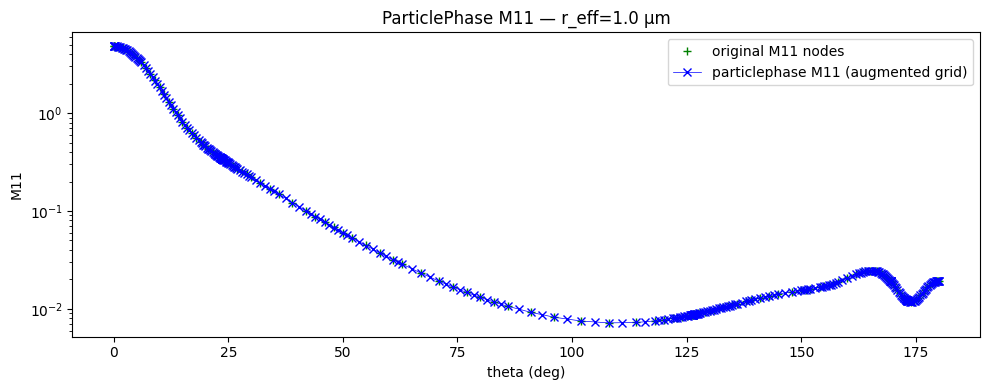

In [422]:
import numpy as np
import mitsuba as mi
import matplotlib.pyplot as plt
from eradiate import traverse
from eradiate.contexts import KernelContext
from eradiate.spectral.index import MonoSpectralIndex
from eradiate.units import unit_registry as ureg
from eradiate.units import to_quantity

eradiate.set_mode("mono_polarized")

si  = MonoSpectralIndex(w=ureg.Quantity(0.67, "micron"))
ctx = KernelContext(si)

# ── pick first r_eff entry ────────────────────────────────────────────────────
i = 0
reff_val = float(cfield.properties.reff.values[i])

reduced_profile = cfield.profile.isel(index=[0])
reduced_profile.r_eff.values = reduced_profile.r_eff.values.copy()
reduced_profile.r_eff.values = np.atleast_1d(cfield.properties.reff.values[i])
reduced_profile = reduced_profile.isel(x=[reduced_profile.i_x.item(), reduced_profile.i_x.item() + 1])
reduced_profile = reduced_profile.isel(y=[reduced_profile.i_y.item(), reduced_profile.i_y.item() + 1])
reduced_profile = reduced_profile.isel(z=range(reduced_profile.i_z.item() + 2))
reduced_profile.i_y.values[0] = 0
reduced_profile.y.values[0] = 0
reduced_profile.y.values[1] = 1

rfield = ParticleField(profile=reduced_profile, properties=cfield.properties)
rfield = rfield.to_profile_regular_grid()

phase_data = rfield.phase.phase_data(ctx)
s = int(phase_data.start.isel(r_eff=i).squeeze().item())
l = int(phase_data.n_pts.isel(r_eff=i).squeeze().item())
e = s + l

theta_native = phase_data.theta_native.values[s:e]   # degrees, 0→180
m11_native   = phase_data.phase_native.values[s:e, 0] # M11 aligned with theta

print(f"r_eff = {reff_val:.1f} µm")
print(f"n_nodes = {l}")
print(f"theta range: [{theta_native[0]:.2f}, {theta_native[-1]:.2f}] deg")
print(f"M11 range:   [{m11_native.min():.4f}, {m11_native.max():.4f}]")

template, umap = traverse(rfield.phase)
rendered  = template.render(ctx)
mi_phase  = mi.load_dict(rendered)

zmin = to_quantity(reduced_profile.z_levels.isel(z=reduced_profile.i_z.item())).m_as("meter")
zmax = to_quantity(reduced_profile.z_levels.isel(z=reduced_profile.i_z.item() + 1)).m_as("meter")
ymin = to_quantity(reduced_profile.y_levels.isel(y=reduced_profile.i_y.item())).m_as("meter")
ymax = to_quantity(reduced_profile.y_levels.isel(y=reduced_profile.i_y.item() + 1)).m_as("meter")
xmin = to_quantity(reduced_profile.x_levels.isel(x=reduced_profile.i_x.item())).m_as("meter")
xmax = to_quantity(reduced_profile.x_levels.isel(x=reduced_profile.i_x.item() + 1)).m_as("meter")

cx = (xmin + xmax) / 2.0
cy = (ymin + ymax) / 2.0
cz = (zmin + zmax) / 2.0

mei             = mi.MediumInteraction3f()
mei.p           = mi.Point3f(cx, cy, cz)
mei.wi          = mi.Vector3f(0, 0, -1)
mei.t           = 0.0
mei.time        = 0.0
mei.wavelengths = mi.Color0f()
phase_ctx       = mi.PhaseFunctionContext(None)

theta_aug = np.sort(np.concatenate([
    theta_native,
    (theta_native[:-1] + theta_native[1:]) / 2.0,
]))

m11_out = []
for th in theta_aug:
    ct = np.cos(np.deg2rad(th))
    st = np.sqrt(max(0.0, 1.0 - ct**2))
    wo = mi.Vector3f(st, 0.0, ct)
    val, _ = mi_phase.eval_pdf(phase_ctx, mei, wo)
    m11_out.append(float(val[0][0].item()))

m11_out = np.array(m11_out)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    theta_native, m11_native / np.pi / 4,
    color="green", marker="+", linestyle="none",
    label="original M11 nodes",
)
ax.plot(
    theta_aug, m11_out,
    color="blue", linewidth=0.5, marker="x",
    label="particlephase M11 (augmented grid)",
)

ax.set_xlabel("theta (deg)")
ax.set_ylabel("M11")
ax.set_title(f"ParticlePhase M11 — r_eff={reff_val:.1f} µm")
ax.set_yscale("log")
ax.legend()
plt.tight_layout()
plt.show()

  0%|          | 0/25 [00:00<?, ?it/s]

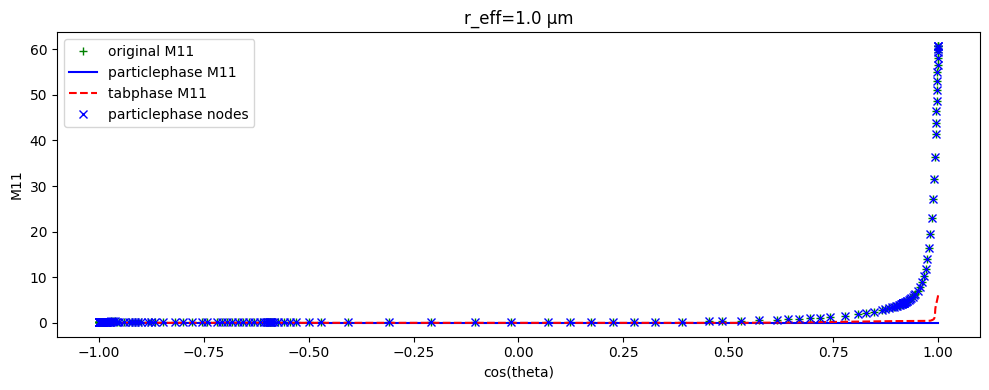

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:176                                                                                  │
│                                                                                                  │
│   173 │   │   │   │   )                                                                          │
│   174 │   │   │   │                                                                              │
│   175 │   │   │   │   if rel_err_pdf > 1e-3:                                                     │
│ ❱ 176 │   │   │   │   │   raise AssertionError(f"PDF mismatch:\n{ctx_str}")                      │
│   177 │   │   │   │   if max_rel_mat > 1e-3:                                                     │
│   178 │   │   │   │   │   raise AssertionError(f"Mueller matrix mismatch:\n{ctx_str}")           │
│   179 │   │   │   │   if zero_violations:                                                        │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
AssertionError: PDF mismatch:
reff=1.0  pos=min  theta=[0.00,0.10]  angle=node_lo  theta=0.000°
  pdf=(-0.000000,6.039598)  rel_err=1.00e+00
  particle M:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
  tabphase M:
[[6.0396 0.     0.     0.    ]
 [0.     0.     0.     0.    ]
 [0.     0.     0.     0.    ]
 [0.     0.     0.     6.0396]]
  rel diff:
[[1. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 1.]]

In [294]:
for i, reff in enumerate(tqdm(cfield.properties.reff)):

    reduced_profile = cfield.profile.isel(index=[0])
    reduced_profile.r_eff.values = reduced_profile.r_eff.values.copy()
    reduced_profile.r_eff.values = np.atleast_1d(reff.values)
    reduced_profile = reduced_profile.isel(x=[reduced_profile.i_x.item(), reduced_profile.i_x.item() + 1])
    reduced_profile = reduced_profile.isel(y=[reduced_profile.i_y.item(), reduced_profile.i_y.item() + 1])
    reduced_profile = reduced_profile.isel(z=range(reduced_profile.i_z.item() + 2))
    reduced_profile.i_y.values[0] = 0
    reduced_profile.y.values[0] = 0
    reduced_profile.y.values[1] = 1

    rfield = ParticleField(profile=reduced_profile, properties=cfield.properties)
    rfield = rfield.to_profile_regular_grid()

    phase_data = rfield.phase.phase_data(KernelContext(si))
    phase_ref  = rfield.properties.phase.squeeze().isel(nreff=i).dropna(dim="nthetamax", how="all")
    assert np.all(~np.isnan(phase_ref))

    s = phase_data.start.isel(r_eff=i).squeeze().item()
    l = phase_data.n_pts.isel(r_eff=i).squeeze().item()
    e = s + l

    theta     = phase_data.theta_native.values[s:e]   # 0→180°
    phase     = phase_data.phase_native.values[s:e]   # aligned with theta
    cosvl     = np.cos(np.deg2rad(theta))              # 1→-1 decreasing
    cosvl_asc = cosvl[::-1]                            # -1→1 ascending for tabphase

    # ── assertions ────────────────────────────────────────────────────────────
    assert np.allclose(phase_ref.isel(nphamat=0).values, phase[::-1, 0])
    assert np.allclose(phase_ref.isel(nphamat=0).values, phase[::-1, 5])
    assert np.allclose(phase_ref.isel(nphamat=1).values, phase[::-1, 1])
    assert np.allclose(phase_ref.isel(nphamat=1).values, phase[::-1, 4])
    assert np.allclose(phase_ref.isel(nphamat=2).values, phase[::-1, 10])
    assert np.allclose(phase_ref.isel(nphamat=2).values, phase[::-1, 15])
    assert np.allclose(phase_ref.isel(nphamat=3).values, phase[::-1, 11])
    assert np.allclose(phase_ref.isel(nphamat=3).values, phase[::-1, 14])
    for ch in [2,3,6,7,8,9,12,13]:
        assert np.allclose(0.0, phase[::-1, ch])

    # ── build plugins ─────────────────────────────────────────────────────────
    ctx      = KernelContext(si)
    template, umap = traverse(rfield.phase)
    rendered = template.render(ctx)
    mi_phase = mi.load_dict(rendered)

    m11_asc = phase_ref.isel(nphamat=0).values[::-1]
    m12_asc = phase_ref.isel(nphamat=1).values[::-1]
    m33_asc = phase_ref.isel(nphamat=2).values[::-1]
    m34_asc = phase_ref.isel(nphamat=3).values[::-1]

    mi_tabphase = mi.load_dict({
        "type": "tabphase_polarized",
        "nodes": ",".join(str(float(x)) for x in cosvl_asc),
        "m11":   ",".join(str(float(x)) for x in m11_asc),
        "m12":   ",".join(str(float(x)) for x in m12_asc),
        "m22":   ",".join(str(float(x)) for x in m11_asc),
        "m33":   ",".join(str(float(x)) for x in m33_asc),
        "m34":   ",".join(str(float(x)) for x in m34_asc),
        "m44":   ",".join(str(float(x)) for x in m33_asc),
    })

    nodes_eval   = np.array(rendered["nodes"])
    mueller_eval = np.array(rendered["phase_mueller"])

    # ── interaction point at voxel centre ─────────────────────────────────────
    zmin, zmax = reduced_profile.z_levels.isel(z=[reduced_profile.i_z.item(), reduced_profile.i_z.item()+1])
    ymin, ymax = reduced_profile.y_levels.isel(y=[reduced_profile.i_y.item(), reduced_profile.i_y.item()+1])
    xmin, xmax = reduced_profile.x_levels.isel(x=[reduced_profile.i_x.item(), reduced_profile.i_x.item()+1])

    cx = (float(to_quantity(xmin).m_as("meter")) + float(to_quantity(xmax).m_as("meter"))) / 2.0
    cy = (float(to_quantity(ymin).m_as("meter")) + float(to_quantity(ymax).m_as("meter"))) / 2.0
    cz = (float(to_quantity(zmin).m_as("meter")) + float(to_quantity(zmax).m_as("meter"))) / 2.0

    mei             = mi.MediumInteraction3f()
    mei.p           = mi.Point3f(cx, cy, cz)
    mei.wi          = mi.Vector3f(0, 0, -1)
    mei.t           = 0.0
    mei.time        = 0.0
    mei.wavelengths = mi.Color0f()
    phase_ctx       = mi.PhaseFunctionContext(None)

    # ── dense plot ────────────────────────────────────────────────────────────
    plot_theta  = np.linspace(0, 180, 361)
    plot_cos    = np.cos(np.deg2rad(plot_theta))
    m11_p, m11_t = [], []

    for angle in plot_theta:
        ct = np.cos(np.deg2rad(angle))
        st = np.sqrt(max(0.0, 1.0 - ct**2))
        wo = mi.Vector3f(st, 0.0, -ct)   # note: -ct because wi=(0,0,-1)
        vp, _ = mi_phase.eval_pdf(phase_ctx, mei, wo)
        vt, _ = mi_tabphase.eval_pdf(phase_ctx, mei, wo)
        m11_p.append(float(vp[0][0].item()))
        m11_t.append(float(vt[0][0].item()))

    fig, ax = plt.subplots(figsize=(10, 4))
    orig_theta = cfield.properties.isel(nreff=i, nphamat=0, nlam=0).theta.dropna(dim="nthetamax")
    orig_phase = cfield.properties.isel(nreff=i, nphamat=0, nlam=0).phase.dropna(dim="nthetamax")
    ax.plot(np.cos(np.deg2rad(orig_theta)), orig_phase,
            label="original M11", color="green", marker="+", linestyle="none")
    ax.plot(plot_cos, m11_p, label="particlephase M11", color="blue")
    ax.plot(plot_cos, m11_t, label="tabphase M11",      color="red",  linestyle="--")
    ax.plot(nodes_eval[s:e], mueller_eval[s*6:e*6:6],
            label="particlephase nodes", color="blue", marker="x", linestyle="none")
    #ax.set_yscale("log")
    ax.set_xlabel("cos(theta)")
    ax.set_ylabel("M11")
    ax.set_title(f"r_eff={float(reff.values):.1f} µm")
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.close()

    # ── pointwise assertion ───────────────────────────────────────────────────
    for thi_idx in range(len(theta) - 1):
        thi_lo, thi_hi = theta[thi_idx], theta[thi_idx + 1]

        for px, py, pz, pos_label in [
            (float(to_quantity(xmin).m_as("meter")),
             float(to_quantity(ymin).m_as("meter")),
             float(to_quantity(zmin).m_as("meter")), "min"),
            (cx, cy, cz, "center"),
            (float(to_quantity(xmax).m_as("meter")),
             float(to_quantity(ymax).m_as("meter")),
             float(to_quantity(zmax).m_as("meter")), "max"),
        ]:
            mei2             = mi.MediumInteraction3f()
            mei2.p           = mi.Point3f(px, py, pz)
            mei2.wi          = mi.Vector3f(0, 0, -1)
            mei2.t           = 0.0
            mei2.time        = 0.0
            mei2.wavelengths = mi.Color0f()

            for angle_label, angle_deg in [
                ("node_lo", thi_lo),
                ("interp",  (thi_lo + thi_hi) / 2.0),
                ("node_hi", thi_hi),
            ]:
                ct = np.cos(np.deg2rad(angle_deg))
                st = np.sqrt(max(0.0, 1.0 - ct**2))
                wo = mi.Vector3f(st, 0.0, -ct)

                value_p, pdf_p = mi_phase.eval_pdf(phase_ctx, mei2, wo)
                value_t, pdf_t = mi_tabphase.eval_pdf(phase_ctx, mei2, wo)

                pdf_p_f = float(pdf_p)
                pdf_t_f = float(pdf_t)

                def extract_mueller(v):
                    return np.array([[float(v[r][c].item()) for c in range(4)] for r in range(4)])

                mp = extract_mueller(value_p)
                mt = extract_mueller(value_t)
                diff = mp - mt
                with np.errstate(invalid="ignore", divide="ignore"):
                    rel = np.where(np.abs(mt) > 1e-12,
                                   np.abs(diff) / np.abs(mt),
                                   np.abs(diff))

                expected_zero_idx = [(0,2),(0,3),(1,2),(1,3),(2,0),(2,1),(3,0),(3,1)]
                zero_violations   = [(r,c,mp[r,c]) for r,c in expected_zero_idx if abs(mp[r,c]) > 1e-6]
                rel_err_pdf       = abs(pdf_p_f - pdf_t_f) / abs(pdf_t_f) if abs(pdf_t_f) > 1e-12 else abs(pdf_p_f)
                max_rel_mat       = float(np.max(rel))

                ctx_str = (
                    f"reff={float(reff.values):.1f}  pos={pos_label}  "
                    f"theta=[{thi_lo:.2f},{thi_hi:.2f}]  angle={angle_label}  theta={angle_deg:.3f}°\n"
                    f"  pdf=({pdf_p_f:.6f},{pdf_t_f:.6f})  rel_err={rel_err_pdf:.2e}\n"
                    f"  particle M:\n{np.array2string(mp, precision=5, suppress_small=True)}\n"
                    f"  tabphase M:\n{np.array2string(mt, precision=5, suppress_small=True)}\n"
                    f"  rel diff:\n{np.array2string(rel, precision=2, suppress_small=True)}"
                )

                if rel_err_pdf > 1e-3:
                    raise AssertionError(f"PDF mismatch:\n{ctx_str}")
                if max_rel_mat > 1e-3:
                    raise AssertionError(f"Mueller matrix mismatch:\n{ctx_str}")
                if zero_violations:
                    raise AssertionError(f"Non-zero at expected-zero positions:\n  {zero_violations}\n{ctx_str}")

    break

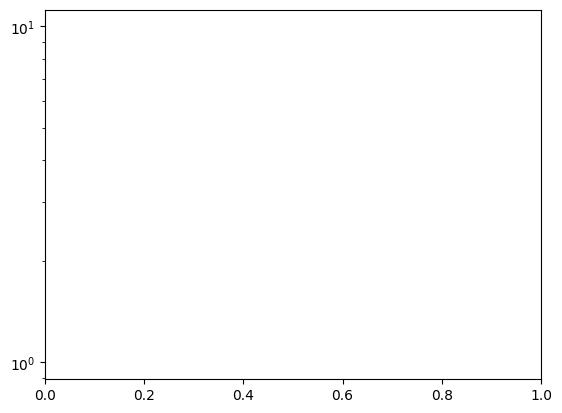

In [288]:
#cfield.properties.isel(nreff=0, nphamat=0, nlam=0).plot.scatter(x="theta", y="phase")

plt.yscale("log")

In [203]:
kdict["phase_mueller"][s:e].shape

(325,)

In [198]:
cosvl.shape

(325,)

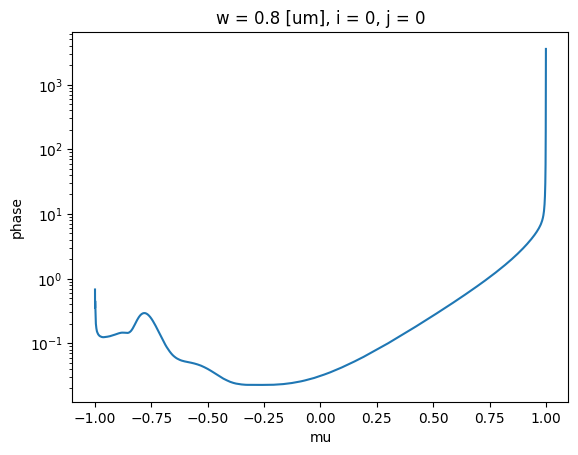

In [191]:
c2_particle_layer.dataset.phase.isel(i=0, j=0, w=1).plot()
plt.yscale("log")

In [166]:
# what r_eff index is particlephase actually using?
print("phase_data coords:")
print("  r_eff values:", phase_data.r_eff.values)
print("  v_eff values:", phase_data.v_eff.values)
print("  w values:", phase_data.w.values)

# raw phase values at first and last node for each r_eff entry
for ri in range(len(phase_data.r_eff)):
    s = int(phase_data.start.values[0, ri, 0])
    n = int(phase_data.n_pts.values[0, ri, 0])
    e = s + n
    m11_back = phase_data.phase_native.values[s, 0]      # first node = backscatter
    m11_fwd  = phase_data.phase_native.values[e - 1, 0]  # last node = forward scatter
    print(f"  r_eff[{ri}]={phase_data.r_eff.values[ri]:.2f}: M11_back={m11_back:.4f}, M11_fwd={m11_fwd:.4f}")

# and what tabphase sees
print("\ntabphase reference:")
print("  r_eff:", float(reff.values))
print("  M11 at first node (backscatter):", float(phase_ref.isel(nphamat=0).values[0]))
print("  M11 at last node (forward):", float(phase_ref.isel(nphamat=0).values[-1]))

phase_data coords:
  r_eff values: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25.]
  v_eff values: [0.11111111]
  w values: [0.67]
  r_eff[0]=1.00: M11_back=60.6660, M11_fwd=0.2430
  r_eff[1]=2.00: M11_back=225.2764, M11_fwd=0.7660
  r_eff[2]=3.00: M11_back=483.2848, M11_fwd=0.6658
  r_eff[3]=4.00: M11_back=840.6892, M11_fwd=0.6416
  r_eff[4]=5.00: M11_back=1296.3834, M11_fwd=0.6530
  r_eff[5]=6.00: M11_back=1850.0979, M11_fwd=0.6621
  r_eff[6]=7.00: M11_back=2501.6785, M11_fwd=0.6668
  r_eff[7]=8.00: M11_back=3251.0042, M11_fwd=0.6693
  r_eff[8]=9.00: M11_back=4097.9800, M11_fwd=0.6710
  r_eff[9]=10.00: M11_back=5042.5386, M11_fwd=0.6727
  r_eff[10]=11.00: M11_back=6084.6343, M11_fwd=0.6748
  r_eff[11]=12.00: M11_back=7224.2319, M11_fwd=0.6774
  r_eff[12]=13.00: M11_back=8461.3027, M11_fwd=0.6806
  r_eff[13]=14.00: M11_back=9795.8164, M11_fwd=0.6846
  r_eff[14]=15.00: M11_back=11227.7451, M11_fwd=0.6893
  r_eff[15]=16.00: M11_back

In [148]:
ds_aer800 = load_aerosol_data("test_3d_clouds/watercloud.mie.cdf", "spherical", 800*ureg.nm)
aer800 = ParticleLayer(
    dataset=ds_aer800,
    w_ref=800*ureg.nm
)


TabulatedPhaseFunction(
    id='phase_atmosphere',
    data=<xarray.DataArray | name='phase', dims=['w', 'mu', 'i', 'j']>,
    force_polarized_phase=False,
    particle_shape='spherical'
)

In [160]:
value_p


[[[4.81779],
  [0],
  [0],
  [0]],
 [[0],
  [0],
  [0],
  [0]],
 [[0],
  [0],
  [0],
  [0]],
 [[0],
  [0],
  [0],
  [4.81779]]]

In [175]:
np.dot(mei.wi, wo)

np.float64(-1.0)

In [176]:
np.cos(np.deg2rad(180))

np.float64(-1.0)

In [167]:
vals[0].to_numpy().squeeze()


array([[ 4.81778988e+00, -2.99645462e-08, -7.33919712e-24,
         0.00000000e+00],
       [-2.99645462e-08,  4.81778988e+00,  1.18001819e-15,
         0.00000000e+00],
       [ 0.00000000e+00, -1.18001827e-15,  4.81779019e+00,
        -2.34094532e-07],
       [ 0.00000000e+00, -5.73366239e-23,  2.34094532e-07,
         4.81779019e+00]])

In [329]:
zmax

<xarray.DataArray 'z_levels' ()> Size: 8B
array(1.44)
Coordinates:
    z        int64 8B 16
Attributes:
    units:    km

### 4. Defining the heterogeneous atmosphere components

The actual IPRT C3 features two atmospheric compositions, one with a molecular atmosphere (case 1), and another with a molecular atmosphere and aerosols (case 2).

Let's start with the aerosol dataset, using the conversion function provided by emdec.

In [ ]:
from test_3d_clouds.utils import load_aerosol_data

aerosol_ds = load_aerosol_data("test_3d_clouds/waso_670.mie.cdf", "spherical", w.item())

The following cells load the IPRT profiles into eradiate objects. This is a bit tedious

In [ ]:
from eradiate.radprops import ArrayRadProfile
from eradiate.scenes.atmosphere import (
    ArrayParticleDistribution,
    MolecularAtmosphere,
    ParticleLayer,
)

grid = cfield.geometry.grid

In [ ]:
df = pd.read_csv(
    "test_3d_clouds/atmos_ext_cu.dat",
    escapechar="!",
    sep="\s+",
    skiprows=6,
).iloc[:, :-1]
df.columns = [
    "height",
    "temp",
    "molabs1",
    "molabs2",
    "molabs3",
    "rayleigh",
    "aerext1",
    "aerext2",
]
df_ext = df.sort_values("height").reset_index(drop=True)

In [ ]:
df = pd.read_csv(
    "test_3d_clouds/atmos_tau_cu.dat",
    escapechar="!",
    sep="\s+",
    skiprows=6,
).iloc[:, :-1]
df.columns = [
    "bottom",
    "top",
    "temp",
    "absot1",
    "absot2",
    "absot3",
    "scaot",
    "aot1",
    "aot2",
]
df_tau = df.sort_values("bottom", ascending=True).reset_index(drop=True)

In [135]:
df_tau["top_e"] = np.nextafter(df_tau.top, -np.inf)
z = df_tau[["bottom", "top_e"]].values.ravel()
z[-1] = 30.0
h = (df_tau.top - df_tau.bottom)
h = np.tile(h.values, (2, 1)).T.ravel()
st = np.tile(df_tau.scaot.values, (2, 1)).T.ravel() / h
at = np.tile(df_tau.absot1.values, (2, 1)).T.ravel() / h

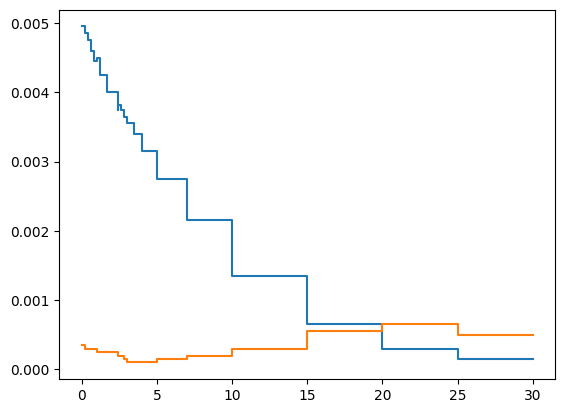

In [136]:
plt.plot(z, st)
plt.plot(z, at)

In [137]:
df_ext_sorted = df_ext.sort_values("height").reset_index(drop=True)
z_levels = df_ext_sorted.height.values
ws = np.asarray([0.665, 0.675])
mol_coords = dict(
    w=(["w"], ws, dict(units="micron")), z=(["z"], z, dict(units="km"))
)

sigma_s = xr.Dataset(
    coords=mol_coords,
    data_vars=dict(
        sigma_s=(
            ["w", "z"],
            np.repeat(np.atleast_2d(st), 2, axis=0),
            dict(units="1/km"),
        )
    ),
).sigma_s

sigma_a = xr.Dataset(
    coords=mol_coords,
    data_vars=dict(
        sigma_a=(
            ["w", "z"],
            np.repeat(np.atleast_2d(at), 2, axis=0),
            dict(units="1/km"),
        )
    ),
).sigma_a


In [138]:

radprops = ArrayRadProfile(
    sigma_a=sigma_a,
    sigma_s=sigma_s,
    rayleigh_depolarization=np.asarray([0.0]),
    interpolation_method="linear",
)
ma = MolecularAtmosphere(
    geometry=cfield.geometry,
    thermoprops=None,
    radprops_profile=radprops,
)

df_tau_sorted = df_tau.sort_values("bottom").reset_index(drop=True)
layer_center_km = 0.5 * (df_tau_sorted.bottom.values + df_tau_sorted.top.values)
coords_normalized = layer_center_km / 30.0
tau_aer_per_layer = df_tau_sorted.aot1.values

distribution = ArrayParticleDistribution(
    values=tau_aer_per_layer,
    coords=coords_normalized,
    method="linear",
    extrapolate="nearest",
)

particles = ParticleLayer(
    geometry=cfield.geometry,
    bottom=0.0 * ureg.km,
    top=30.0 * ureg.km,
    distribution=distribution,
    w_ref=0.67 * ureg.micron,
    tau_ref=float(tau_aer_per_layer.sum()),
    dataset=aerosol_ds,
)

/home/miskn/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


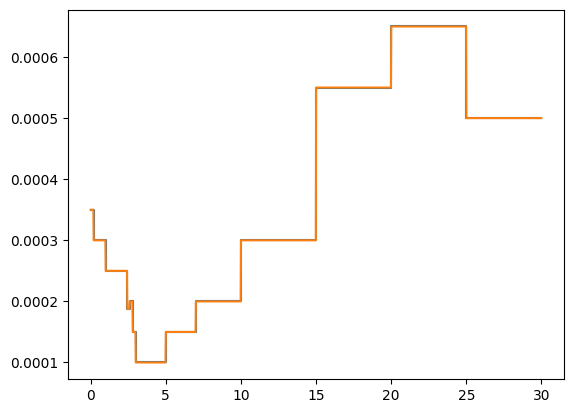

In [139]:
at = np.tile(df_tau.absot1.values, (2, 1)).T.ravel() / h


plt.plot(z, at)
plt.plot(ma.geometry.grid.layers, ma.eval_sigma_a(MonoSpectralIndex(w=670*ureg.nm)))

/home/miskn/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


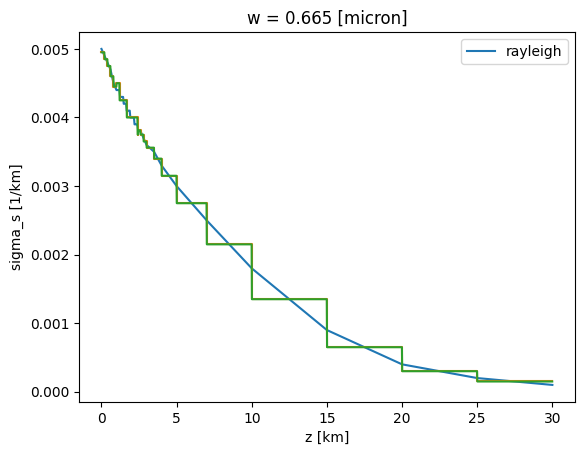

In [140]:
df_ext.plot(x="height", y="rayleigh")
sigma_s.isel(w=0).plot()
plt.plot(ma.geometry.grid.layers, ma.eval_sigma_s(MonoSpectralIndex(670 * ureg.nm)))

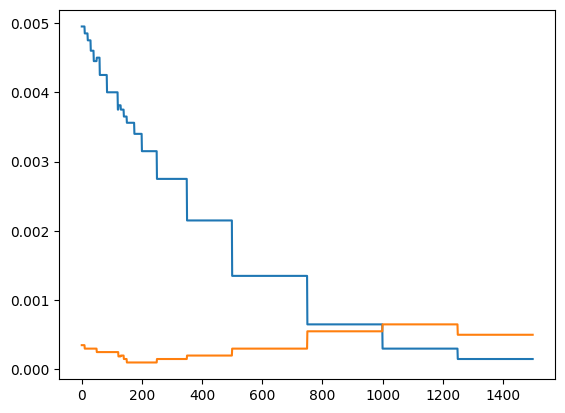

In [141]:
plt.plot(ma.eval_sigma_s(MonoSpectralIndex(670 * ureg.nm)))
plt.plot(ma.eval_sigma_a(MonoSpectralIndex(670 * ureg.nm)))

/home/miskn/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1355: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asarray(x, float)


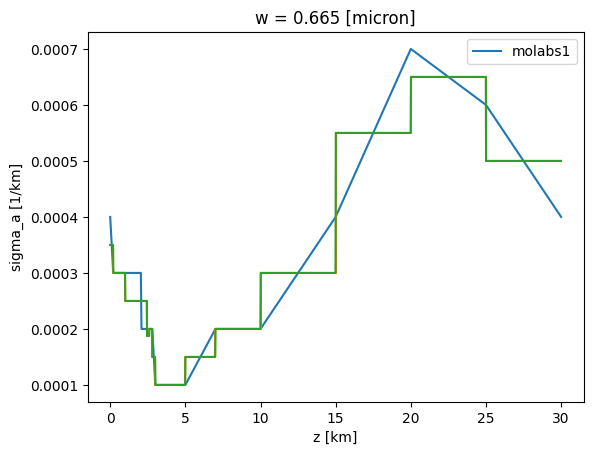

In [142]:
df_ext.plot(x="height", y="molabs1")
sigma_a.isel(w=0).plot()
plt.plot(ma.geometry.grid.layers, ma.eval_sigma_a(MonoSpectralIndex(670 * ureg.nm)))

In [143]:
experiment_noaer = AtmosphereExperiment(
    atmosphere=HeterogeneousAtmosphere(
        clouds=None,
        molecular_atmosphere=ma,
        particle_layers=[],
        geometry=cfield.geometry,
    ),
    **scene_config,
)

In [144]:
experiment_nocloud = AtmosphereExperiment(
    atmosphere=HeterogeneousAtmosphere(
        clouds=None,
        molecular_atmosphere=ma,
        particle_layers=[particles],
        geometry=cfield.geometry,
    ),
    **scene_config,
)

We actually run an experiments with only the atmosphere and no clouds to ensure the properties are correct and can somewhat be mapped to Mystic outputs on cloud free, shadow free pixels

In [145]:
%%time
# ~ 8 sec for spp = 1000
dr.set_thread_count(23)
res_noaer = eradiate.run(experiment_noaer, spp=100)
dr.set_thread_count(23)

CPU times: user 9.97 s, sys: 988 ms, total: 11 s
Wall time: 4.3 s


In [146]:
%%time
# ~ 15 sec for spp = 1000
dr.set_thread_count(23)
res_nocloud = eradiate.run(experiment_nocloud, spp=100)
dr.set_thread_count(23)

CPU times: user 21.1 s, sys: 1.63 s, total: 22.8 s
Wall time: 7.45 s


For this we need the actual reference values

In [307]:
mdf = pd.read_csv("test_3d_clouds/iprt_case_c3_mystic.dat", sep="\s+", header=2)
cols = mdf.columns[1:]
mdf = mdf.iloc[:, :-1].copy()
mdf.columns = cols

In [308]:
m_nrad = (
    mdf[(mdf.case == 1) & (mdf.theta_0 == 40) & (mdf.theta == 180)]
    .I.values.reshape(100, 100)
    .T
)
m_nrad2 = (
    mdf[(mdf.case == 2) & (mdf.theta_0 == 40) & (mdf.theta == 180)]
    .I.values.reshape(100, 100)
    .T
)

In [149]:
m_nrad[20:40, 60:80].mean(), m_nrad[20:40, 60:80].std() * 3

(np.float64(0.0533665825), np.float64(0.0009012487868473115))

In [150]:
irr = res_noaer.irradiance.item()
test_nrad1 = res_noaer.radiance.sel(stokes="I").values / irr
test_nrad2 = res_nocloud.radiance.sel(stokes="I").values / irr

In [151]:
test_nrad1.mean(), test_nrad1.std() * 3

(np.float64(0.06480334205031396), np.float64(0.00665562896704747))

In [152]:
test_nrad2.mean(), test_nrad2.std() * 3

(np.float64(0.07118224325068297), np.float64(0.013874000005368665))

In [153]:
ref1 = xr.load_dataset("test_3d_clouds_regression/onedim_c3_atmosphere_noaer_ref.nc")
ref1 = (ref1.radiance / ref1.irradiance).sel(stokes="I").values.ravel()
ref2 = xr.load_dataset("test_3d_clouds_regression/onedim_c3_atmosphere_aer_ref.nc")
ref2 = (ref2.radiance / ref2.irradiance).sel(stokes="I").values.ravel()

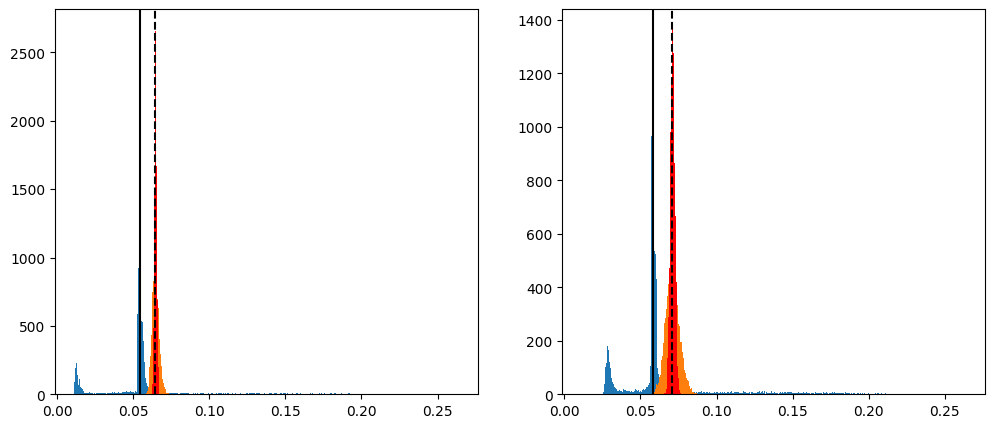

In [154]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

counts, bins, c = ax1.hist(m_nrad.ravel(), bins=500)
ax1.hist(test_nrad1.ravel(), bins=bins)
ax1.hist(ref1, bins=bins, color="red")
med1, m_med1 = np.median(test_nrad1), np.median(m_nrad)
ax1.axvline(m_med1, color="black")
ax1.axvline(med1, color="black", linestyle="--")

ax2.hist(m_nrad2.ravel(), bins=bins)
ax2.hist(test_nrad2.ravel(), bins=bins)
ax2.hist(ref2, bins=bins, color="red")
med2, m_med2 = np.median(test_nrad2), np.median(m_nrad2)
ax2.axvline(m_med2, color="black")
ax2.axvline(med2, color="black", linestyle="--")
plt.show()
plt.close()

In [155]:
(med1 - m_med1) / m_med1 * 100, (med2 - m_med2) / m_med2 * 100

(np.float64(18.610984316121282), np.float64(22.327342644796623))

The shift between the non cloud pixels and the clear sky simulation is a bug. The bias between the non cloud, non shadow pixels is about 20%, way too high.

### 5. C3 3D clouds with an atmosphere

In [156]:
experiment_cloud1 = AtmosphereExperiment(
    atmosphere=HeterogeneousAtmosphere(
        clouds=cfield,
        molecular_atmosphere=ma,
        particle_layers=[],
        geometry=cfield.geometry,
    ),
    **scene_config,
)

experiment_cloud2 = AtmosphereExperiment(
    atmosphere=HeterogeneousAtmosphere(
        clouds=cfield,
        molecular_atmosphere=ma,
        particle_layers=[particles],
        geometry=cfield.geometry,
    ),
    **scene_config,
)

experiment_cloud3 = AtmosphereExperiment(
    atmosphere=HeterogeneousAtmosphere(
        clouds=cfield_ext,
        molecular_atmosphere=ma,
        particle_layers=[particles],
        geometry=cfield.geometry,
    ),
    **scene_config,
)

In [157]:
import datetime

In [158]:
%%time

# ~ 8 min for spp=24
res1 = eradiate.run(experiment_cloud1, spp=24)
ts = datetime.datetime.isoformat(datetime.datetime.now())
res1.to_netcdf(f"results/complete_c3_1_5_{ts}.nc")

/home/miskn/git/erd_multi/src/eradiate/scenes/phase/_cloudphase.py:196: RuntimeWarning: invalid value encountered in divide
  (wavelengths - w_axis[il_w]) / (w_axis[iu_w] - w_axis[il_w]),


CPU times: user 1h 5min 53s, sys: 5.79 s, total: 1h 5min 59s
Wall time: 4min 51s


In [159]:
%%time

# ~ 8 min for spp=24

res2 = eradiate.run(experiment_cloud2, spp=24)
ts = datetime.datetime.isoformat(datetime.datetime.now())
res2.to_netcdf(f"results/complete_c3_2_5_{ts}.nc")

/home/miskn/git/erd_multi/src/eradiate/scenes/phase/_cloudphase.py:196: RuntimeWarning: invalid value encountered in divide
  (wavelengths - w_axis[il_w]) / (w_axis[iu_w] - w_axis[il_w]),


CPU times: user 1h 15min 40s, sys: 6.92 s, total: 1h 15min 47s
Wall time: 5min 9s


In [160]:
%%time

# ~ 8 min for spp=24

res3 = eradiate.run(experiment_cloud3, spp=24)
ts = datetime.datetime.isoformat(datetime.datetime.now())

/home/miskn/git/erd_multi/src/eradiate/scenes/phase/_cloudphase.py:196: RuntimeWarning: invalid value encountered in divide
  (wavelengths - w_axis[il_w]) / (w_axis[iu_w] - w_axis[il_w]),


CPU times: user 1h 16min 8s, sys: 5.51 s, total: 1h 16min 13s
Wall time: 5min 4s


In [161]:
nres1 = res1.radiance.sel(stokes="I").values.squeeze()
nres2 = res2.radiance.sel(stokes="I").values.squeeze()

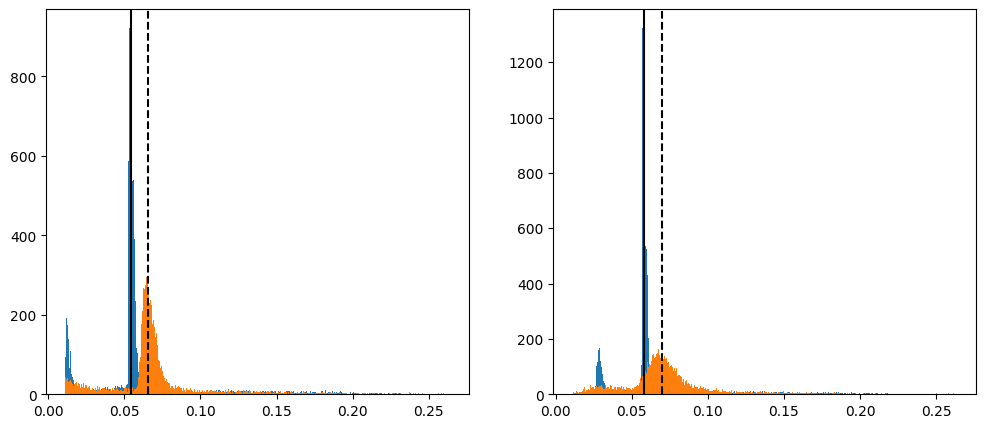

In [162]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

counts, bins, c = ax1.hist(m_nrad.ravel(), bins=500)
ax1.hist(nres1.ravel(), bins=bins)
med1, m_med1 = np.median(nres1), np.median(m_nrad)
ax1.axvline(m_med1, color="black")
ax1.axvline(med1, color="black", linestyle="--")

ax2.hist(m_nrad2.ravel(), bins=bins)
ax2.hist(nres2.ravel(), bins=bins)
med2, m_med2 = np.median(nres2), np.median(m_nrad2)
ax2.axvline(m_med2, color="black")
ax2.axvline(med2, color="black", linestyle="--")
plt.show()
plt.close()

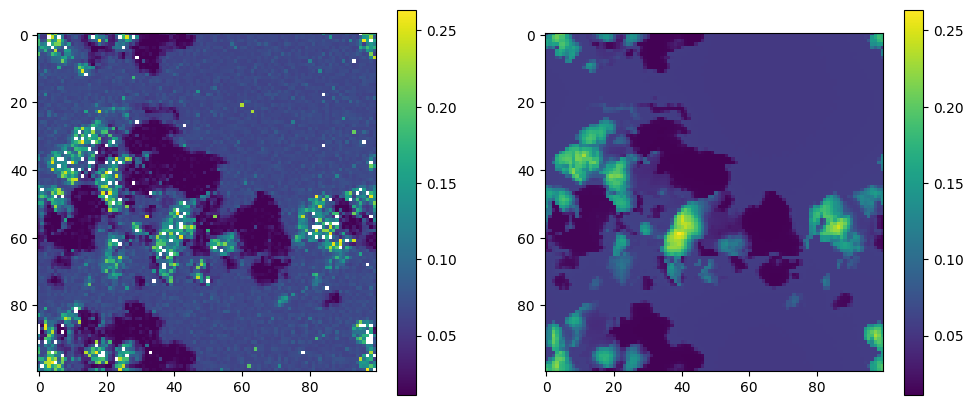

In [163]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

inrange = np.where(nres1 < m_nrad.max(), nres1, np.nan)
plt.colorbar(ax1.imshow(inrange, vmin=m_nrad.min(), vmax=m_nrad.max()))
plt.colorbar(ax2.imshow(m_nrad, vmin=m_nrad.min(), vmax=m_nrad.max()))

In [164]:
inrange


array([[0.16846339, 0.0639838 , 0.06762112, ..., 0.20214966, 0.17960767,
        0.15495953],
       [0.12416999, 0.04983352, 0.04971576, ..., 0.15400176, 0.22753678,
        0.08514059],
       [0.18866752, 0.06800973, 0.08086522, ..., 0.16049856,        nan,
        0.16162634],
       ...,
       [0.05852769, 0.11966737, 0.22879599, ..., 0.13743974, 0.08753182,
        0.12115757],
       [0.10446512,        nan, 0.15507525, ..., 0.13962181, 0.19485025,
        0.14436309],
       [0.13437006, 0.0948775 , 0.14328797, ..., 0.26199454, 0.10659479,
               nan]], shape=(100, 100))

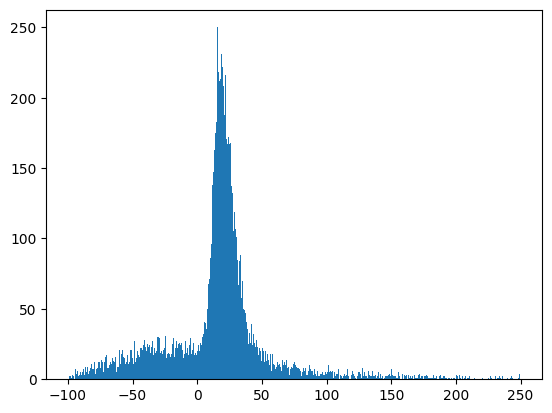

In [165]:
b = (nres1 - m_nrad) / m_nrad * 100
b = np.where(b < 250, b, np.nan)
_ = plt.hist(b.ravel(), bins=500)

The large bias is still present

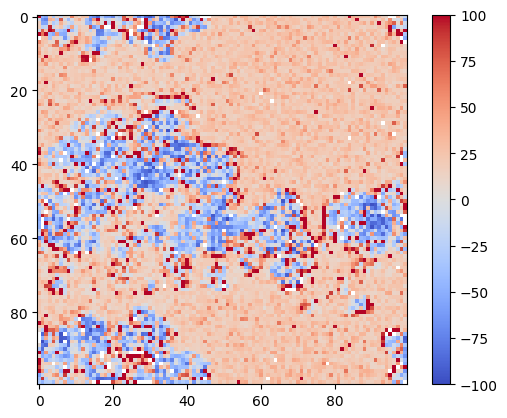

In [166]:
m = np.clip(np.nanmax(b),0, 100)
plt.colorbar(plt.imshow(b, vmin=-m, vmax=m, cmap="coolwarm"))

In [167]:
from eradiate.rng import SeedState
dss = [
    eradiate.run(experiment_cloud1, spp=64, seed_state=SeedState(i))
    for i in tqdm(range(24))
]

  0%|          | 0/24 [00:00<?, ?it/s]

/home/miskn/git/erd_multi/src/eradiate/scenes/phase/_cloudphase.py:196: RuntimeWarning: invalid value encountered in divide
  (wavelengths - w_axis[il_w]) / (w_axis[iu_w] - w_axis[il_w]),
/home/miskn/git/erd_multi/src/eradiate/scenes/phase/_cloudphase.py:196: RuntimeWarning: invalid value encountered in divide
  (wavelengths - w_axis[il_w]) / (w_axis[iu_w] - w_axis[il_w]),
/home/miskn/git/erd_multi/src/eradiate/scenes/phase/_cloudphase.py:196: RuntimeWarning: invalid value encountered in divide
  (wavelengths - w_axis[il_w]) / (w_axis[iu_w] - w_axis[il_w]),
/home/miskn/git/erd_multi/src/eradiate/scenes/phase/_cloudphase.py:196: RuntimeWarning: invalid value encountered in divide
  (wavelengths - w_axis[il_w]) / (w_axis[iu_w] - w_axis[il_w]),
/home/miskn/git/erd_multi/src/eradiate/scenes/phase/_cloudphase.py:196: RuntimeWarning: invalid value encountered in divide
  (wavelengths - w_axis[il_w]) / (w_axis[iu_w] - w_axis[il_w]),
/home/miskn/git/erd_multi/src/eradiate/scenes/phase/_cloudph

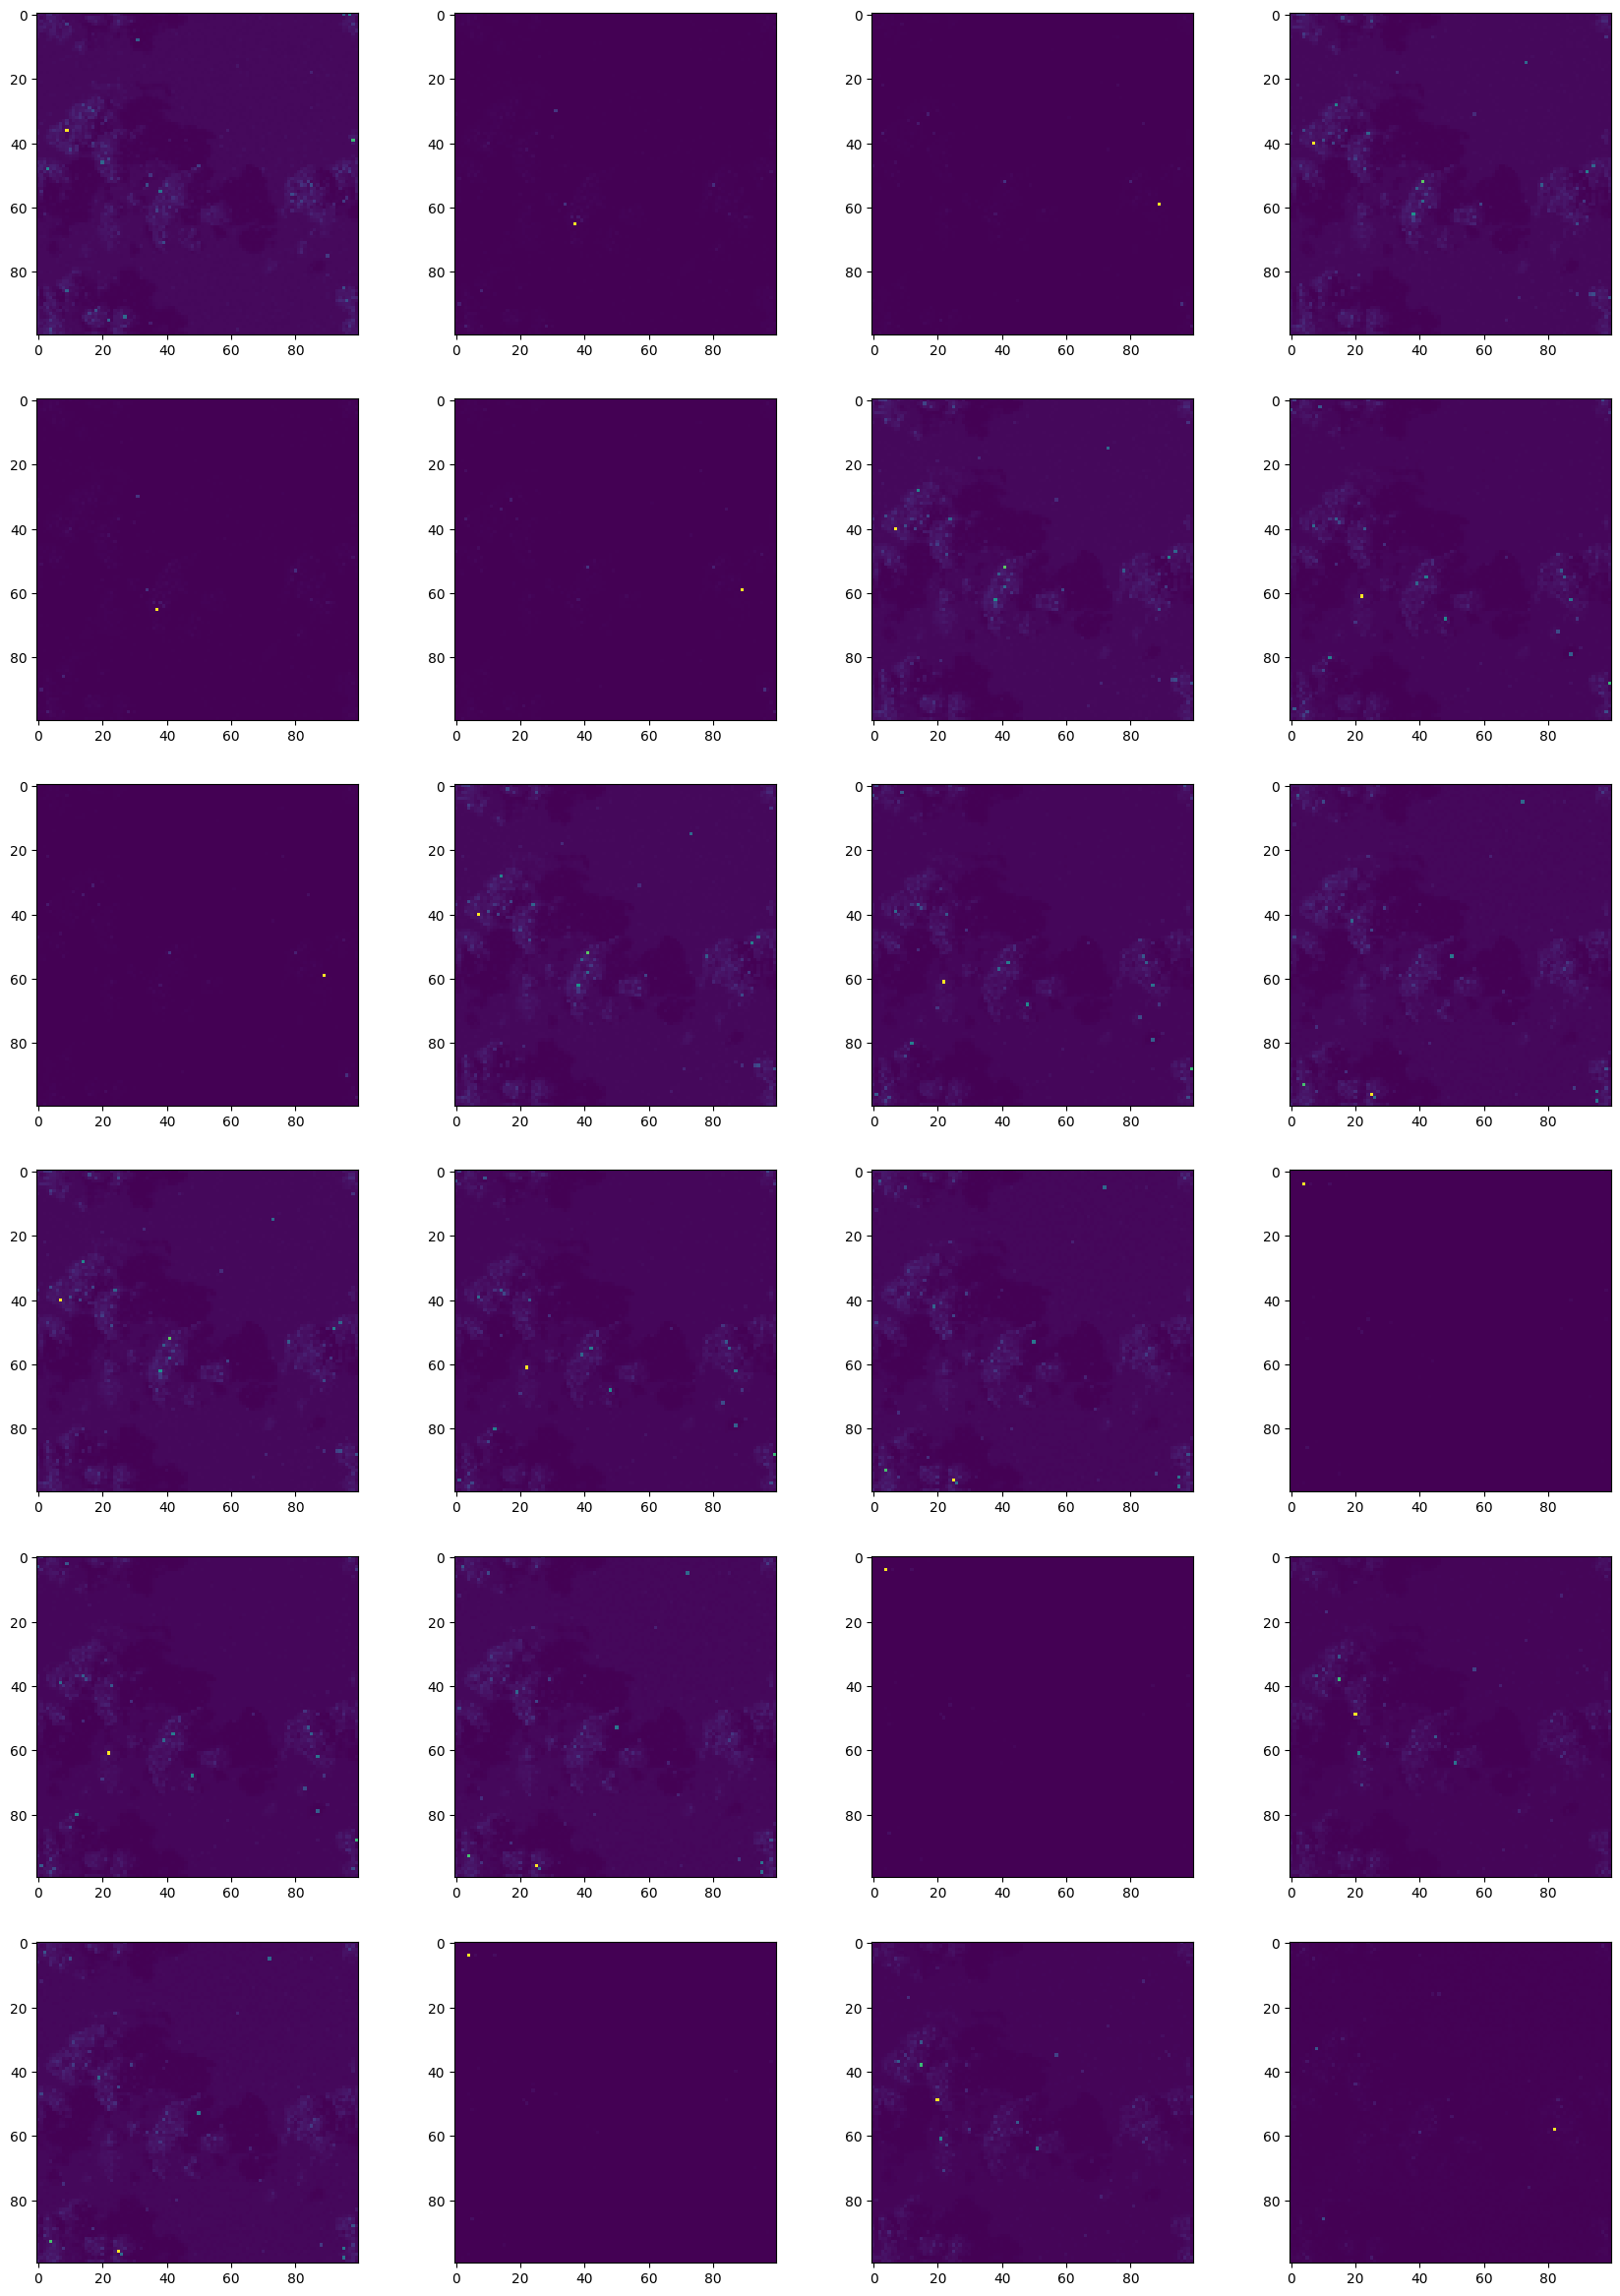

In [168]:
fig, axs = plt.subplots(6, 4, figsize=(21, 29.7))
for i in range(6):
    for j in range(4):
        axs[i][j].imshow(dss[i + 6 + j].radiance.sel(stokes="I").squeeze())

In [169]:
N = 100000

inputs = np.stack([ds.radiance.sel(stokes="I").clip(0, 0.27).values.squeeze() for ds in dss])
selected = np.zeros((N, 100, 100))
selection = np.random.randint(0, inputs.shape[0], selected.shape)

In [170]:
h = np.arange(100)
result = inputs[selection, h[:, None], h[None, :]]

In [177]:
del inputs, selected, selection, result

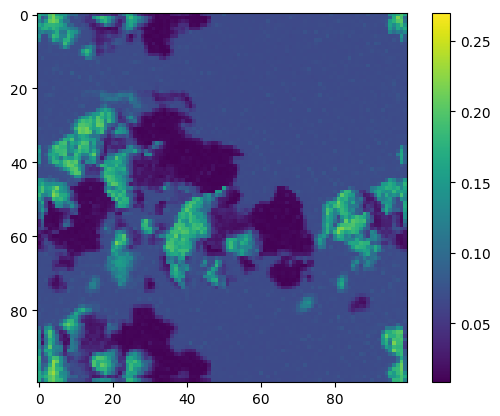

In [171]:
plt.colorbar(plt.imshow(np.mean(result, axis=0), vmax=0.27)) 

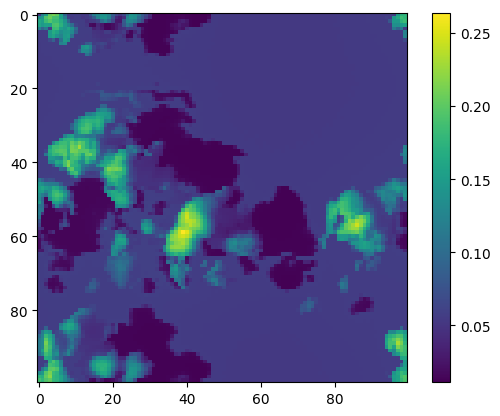

In [172]:
plt.colorbar(plt.imshow(m_nrad, vmin=m_nrad.min(), vmax=m_nrad.max()))

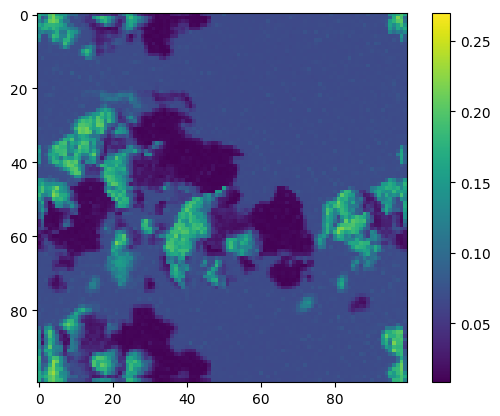

In [173]:
plt.colorbar(plt.imshow(np.mean(inputs, axis=0), vmax=0.27))

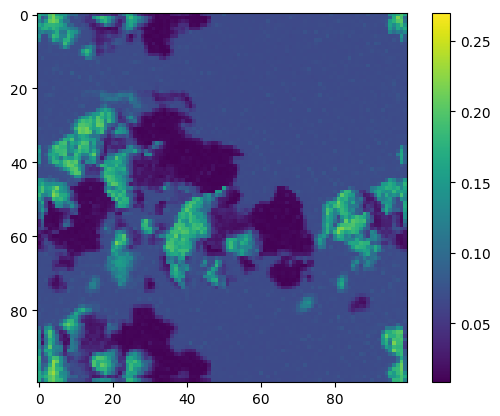

In [174]:
plt.colorbar(plt.imshow(np.mean(result, axis=0), vmax=0.27))

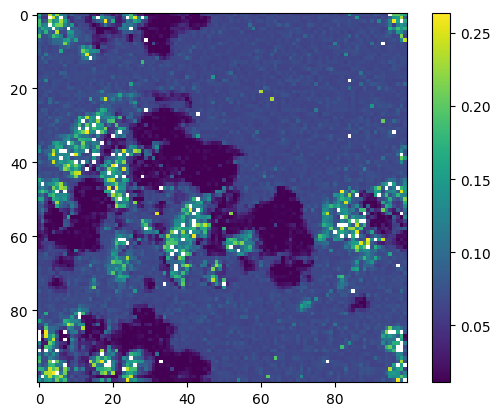

In [175]:
plt.colorbar(plt.imshow(inrange, vmin=m_nrad.min(), vmax=m_nrad.max()))

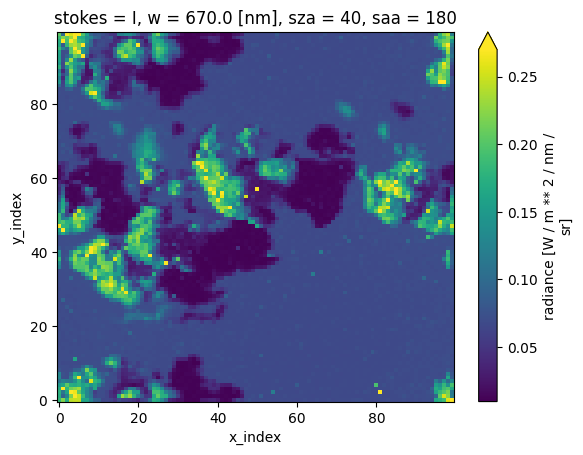

In [99]:
xr.load_dataset("results/complete_c3_1_5_2026-05-02T04:38:33.668356.nc").radiance.sel(stokes="I").squeeze().plot(vmax=0.27)